# 1. УСТАНОВКА И ИМПОРТЫ

   1.1. Установка библиотек
   
   1.2. Импорты

In [1]:
# ============================================================
# 1. УСТАНОВКА И ИМПОРТЫ БИБЛИОТЕК
# ============================================================
!pip install pymoo sentence-transformers scikit-learn -q

import pandas as pd
import numpy as np
import json
import re
import time
import warnings
import matplotlib.pyplot as plt
from typing import Dict, List, Tuple, Optional, Any

from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import cosine_similarity
from scipy.spatial.distance import pdist, euclidean
from sentence_transformers import SentenceTransformer

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)
pd.set_option('display.max_rows', 100)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.7/72.7 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 51.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 328.3/328.3 kB 13.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 866.9/866.9 kB 22.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.4/78.4 kB 3.7 MB/s eta 0:00:00


# 2. ЗАГРУЗКА И ПРЕДОБРАБОТКА ДАННЫХ

   2.1. Загрузка Парето-фронта

   2.2. Загрузка исторических данных

   2.3. Загрузка ограничений

   2.4. Разметка D_good / D_bad

   2.5. Нормализация признаков
   
   2.6. Генерация текстовых описаний рецептур

## 2.1. Загрузка Парето-фронта

In [2]:
# ============================================================
# 2. ЗАГРУЗКА И ПРЕДОБРАБОТКА ДАННЫХ
# ============================================================

# ----------------------------------------------------------
# 2.1. Загрузка Парето-фронта
# ----------------------------------------------------------
pareto_df = pd.read_excel('pareto_front_nsga2.xlsx')
print(f"\nПарето-фронт загружен: {pareto_df.shape[0]} точек, {pareto_df.shape[1]} колонок")
print(f"   Целевые колонки: strength, elongation")
print(f"   Пример первых 3 строк strength, elongation:")
print(pareto_df[['strength', 'elongation']].head(3))


Парето-фронт загружен: 100 точек, 27 колонок
   Целевые колонки: strength, elongation
   Пример первых 3 строк strength, elongation:
     strength  elongation
0  174.926735    5.942923
1   78.395831   10.003867
2  174.926735    5.942923


## 2.2. Загрузка исторических данных

In [3]:
# ----------------------------------------------------------
# 2.2. Загрузка исторических данных
# ----------------------------------------------------------
hist_df = pd.read_excel('mlcc_dataset2_all_columns.xlsx')
print(f"\nИсторические данные загружены: {hist_df.shape[0]} строк, {hist_df.shape[1]} колонок")
print(f"   Колонка 'Брак': {'присутствует' if 'Брак' in hist_df.columns else 'ОТСУТСТВУЕТ'}")
print(f"   Успешных (Брак=0): {(hist_df['Брак'] == 0).sum()}")
print(f"   Бракованных (Брак=1): {(hist_df['Брак'] == 1).sum()}")


Исторические данные загружены: 1052 строк, 27 колонок
   Колонка 'Брак': присутствует
   Успешных (Брак=0): 1044
   Бракованных (Брак=1): 8


## 2.3. Загрузка ограничений

In [4]:
# ----------------------------------------------------------
# 2.3. Загрузка ограничений
# ----------------------------------------------------------
with open('param_constraints_2.json', 'r', encoding='utf-8') as f:
    constraints = json.load(f)

print(f"\nОграничения загружены: {len(constraints)} параметров")

# Сводка по типам параметров
type_counts = {'float': 0, 'int': 0, 'categorical': 0}
for name, cfg in constraints.items():
    t = cfg.get('type', 'float')
    type_counts[t] = type_counts.get(t, 0) + 1

print(f"\nСводка по типам:")
print(f"   float (с min/max):       {type_counts.get('float', 0)} параметров")
print(f"   int (с min/max):         {type_counts.get('int', 0)} параметров")
print(f"   categorical (с values):  {type_counts.get('categorical', 0)} параметров")


Ограничения загружены: 26 параметров

Сводка по типам:
   float (с min/max):       10 параметров
   int (с min/max):         6 параметров
   categorical (с values):  10 параметров


## Дополнение: экспертная оценка технолога

Наблюдения по историческим данным:


* ХОРОШИЕ РЕЦЕПТЫ (прочность 80-120 МПа, удлинение >5%):

  - ПВБ2 стадия: 190-220 г (умеренное количество связующего)

  - Толщина: 25-32 мкм (оптимальная)

  - Температура: 20-22°C

  - Влажность: 45-55%

  - Вязкость: 30-45 Па·с

  - Сотрудники: чаще 1, 2, 5, 6



* ПЛОХИЕ РЕЦЕПТЫ (прочность <50 МПа ИЛИ удлинение <4%):

  - ПВБ2 стадия: или очень мало (<200 г) или очень много (>3000 г)

  - Толщина: <15 мкм (слишком тонкая) или >32 мкм

  - Часто: экстремальные значения других параметров

  - Брак (Брак=1): почти все 8 случаев здесь

Анализ данных экспертом-технологом:

In [5]:
# ============================================================
# ЭКСПЕРТНЫЙ АНАЛИЗ ИСТОРИЧЕСКИХ ДАННЫХ
# ============================================================
print("\n" + "="*70)
print("ЭКСПЕРТНЫЙ АНАЛИЗ ИСТОРИЧЕСКИХ ДАННЫХ")
print("="*70)

# ----------------------------------------------------------
# Шаг 1: Многокритериальная оценка качества
# ----------------------------------------------------------
# Нормализация в [0, 1] (0 = худший, 1 = лучший)
hist_df['strength_norm'] = (hist_df['Прочность'] - hist_df['Прочность'].min()) / \
                            (hist_df['Прочность'].max() - hist_df['Прочность'].min())
hist_df['elong_norm'] = (hist_df['Удлинение'] - hist_df['Удлинение'].min()) / \
                          (hist_df['Удлинение'].max() - hist_df['Удлинение'].min())

# Комбинированный показатель (равные веса)
hist_df['quality_score'] = (hist_df['strength_norm'] + hist_df['elong_norm']) / 2

# ----------------------------------------------------------
# Шаг 2: Выделение ТОП-30 и ХУДШИХ-30
# ----------------------------------------------------------
TOP_N = 30
WORST_N = 30

# Топ-30 по качеству
top_30_idx = hist_df['quality_score'].nlargest(TOP_N).index
top_30 = hist_df.loc[top_30_idx].copy()

# Худшие-30 по качеству
worst_30_idx = hist_df['quality_score'].nsmallest(WORST_N).index
worst_30 = hist_df.loc[worst_30_idx].copy()

print(f"\n📊 ТОП-{TOP_N} ЛУЧШИХ РЕЦЕПТУР (экспертная оценка):")
print(f"   Прочность: {top_30['Прочность'].mean():.1f} ± {top_30['Прочность'].std():.1f} МПа")
print(f"   Удлинение: {top_30['Удлинение'].mean():.2f} ± {top_30['Удлинение'].std():.2f}%")
print(f"   Quality:   {top_30['quality_score'].mean():.3f} ± {top_30['quality_score'].std():.3f}")
print(f"   Брак:      {top_30['Брак'].sum()} из {len(top_30)}")

print(f"\n📊 ТОП-{WORST_N} ХУДШИХ РЕЦЕПТУР:")
print(f"   Прочность: {worst_30['Прочность'].mean():.1f} ± {worst_30['Прочность'].std():.1f} МПа")
print(f"   Удлинение: {worst_30['Удлинение'].mean():.2f} ± {worst_30['Удлинение'].std():.2f}%")
print(f"   Quality:   {worst_30['quality_score'].mean():.3f} ± {worst_30['quality_score'].std():.3f}")
print(f"   Брак:      {worst_30['Брак'].sum()} из {len(worst_30)}")


ЭКСПЕРТНЫЙ АНАЛИЗ ИСТОРИЧЕСКИХ ДАННЫХ

📊 ТОП-30 ЛУЧШИХ РЕЦЕПТУР (экспертная оценка):
   Прочность: 105.9 ± 34.4 МПа
   Удлинение: 6.79 ± 1.36%
   Quality:   0.682 ± 0.027
   Брак:      0 из 30

📊 ТОП-30 ХУДШИХ РЕЦЕПТУР:
   Прочность: 40.8 ± 25.7 МПа
   Удлинение: 2.93 ± 1.15%
   Quality:   0.241 ± 0.141
   Брак:      7 из 30


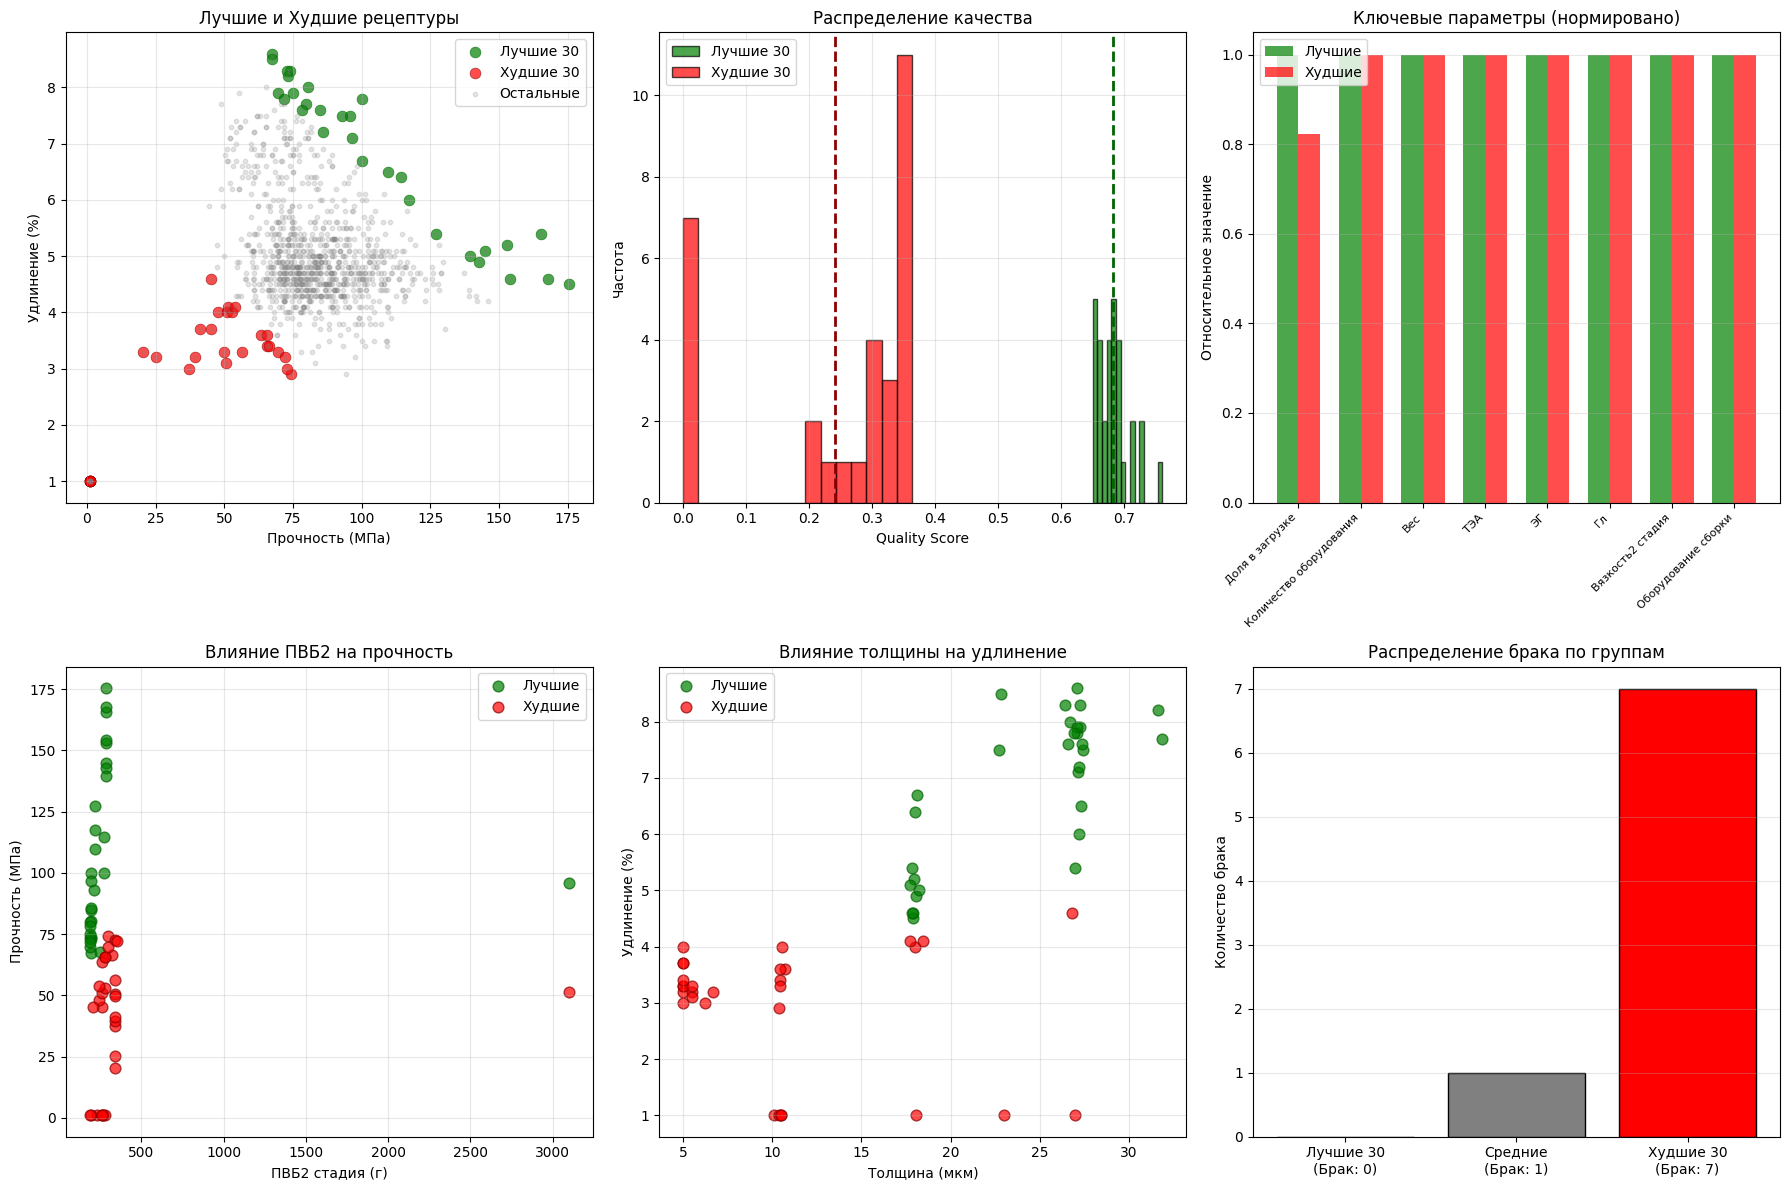

In [ ]:
# ----------------------------------------------------------
# Шаг 4: Визуализация ТОП-30 и ХУДШИХ-30
# ----------------------------------------------------------
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# График 1: Прочность и Удлинение
ax = axes[0, 0]
ax.scatter(top_30['Прочность'], top_30['Удлинение'],
           c='green', s=60, alpha=0.7, edgecolors='darkgreen', linewidth=0.5, label=f'Лучшие {TOP_N}')
ax.scatter(worst_30['Прочность'], worst_30['Удлинение'],
           c='red', s=60, alpha=0.7, edgecolors='darkred', linewidth=0.5, label=f'Худшие {WORST_N}')
ax.scatter(hist_df['Прочность'], hist_df['Удлинение'],
           c='gray', s=10, alpha=0.2, label='Остальные')
ax.set_xlabel('Прочность (МПа)')
ax.set_ylabel('Удлинение (%)')
ax.set_title('Лучшие и Худшие рецептуры')
ax.legend()
ax.grid(True, alpha=0.3)

# График 2: Распределение quality_score
ax = axes[0, 1]
ax.hist(top_30['quality_score'], bins=15, alpha=0.7, color='green', edgecolor='black', label=f'Лучшие {TOP_N}')
ax.hist(worst_30['quality_score'], bins=15, alpha=0.7, color='red', edgecolor='black', label=f'Худшие {WORST_N}')
ax.axvline(top_30['quality_score'].mean(), color='darkgreen', linestyle='--', linewidth=2)
ax.axvline(worst_30['quality_score'].mean(), color='darkred', linestyle='--', linewidth=2)
ax.set_xlabel('Quality Score')
ax.set_ylabel('Частота')
ax.set_title('Распределение качества')
ax.legend()
ax.grid(True, alpha=0.3)

# График 3: Ключевые технологические параметры
ax = axes[0, 2]
if significant_params:
    params_to_plot = [p[0] for p in significant_params[:8]]
    x = np.arange(len(params_to_plot))
    width = 0.35

    best_means = [top_30[p].mean() / max(top_30[p].mean(), 1) for p in params_to_plot]
    worst_means = [worst_30[p].mean() / max(worst_30[p].mean(), 1) for p in params_to_plot]

    ax.bar(x - width/2, best_means, width, color='green', alpha=0.7, label='Лучшие')
    ax.bar(x + width/2, worst_means, width, color='red', alpha=0.7, label='Худшие')
    ax.set_xticks(x)
    ax.set_xticklabels(params_to_plot, rotation=45, ha='right', fontsize=8)
    ax.set_ylabel('Относительное значение')
    ax.set_title('Ключевые параметры (нормировано)')
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')

# График 4: ПВБ2 стадия и Прочность
ax = axes[1, 0]
ax.scatter(top_30['ПВБ2 стадия'], top_30['Прочность'],
           c='green', s=60, alpha=0.7, edgecolors='darkgreen', label=f'Лучшие')
ax.scatter(worst_30['ПВБ2 стадия'], worst_30['Прочность'],
           c='red', s=60, alpha=0.7, edgecolors='darkred', label=f'Худшие')
ax.set_xlabel('ПВБ2 стадия (г)')
ax.set_ylabel('Прочность (МПа)')
ax.set_title('Влияние ПВБ2 на прочность')
ax.legend()
ax.grid(True, alpha=0.3)

# График 5: Толщина и Удлинение
ax = axes[1, 1]
ax.scatter(top_30['Толщина факт'], top_30['Удлинение'],
           c='green', s=60, alpha=0.7, edgecolors='darkgreen', label=f'Лучшие')
ax.scatter(worst_30['Толщина факт'], worst_30['Удлинение'],
           c='red', s=60, alpha=0.7, edgecolors='darkred', label=f'Худшие')
ax.set_xlabel('Толщина (мкм)')
ax.set_ylabel('Удлинение (%)')
ax.set_title('Влияние толщины на удлинение')
ax.legend()
ax.grid(True, alpha=0.3)

# График 6: Брак в группах
ax = axes[1, 2]
brak_counts = [
    top_30['Брак'].sum(),
    hist_df[(~hist_df.index.isin(top_30_idx)) & (~hist_df.index.isin(worst_30_idx))]['Брак'].sum(),
    worst_30['Брак'].sum()
]
brak_labels = [f'Лучшие {TOP_N}\n(Брак: {brak_counts[0]})',
               f'Средние\n(Брак: {brak_counts[1]})',
               f'Худшие {WORST_N}\n(Брак: {brak_counts[2]})']
colors = ['green', 'gray', 'red']
ax.bar(brak_labels, brak_counts, color=colors, edgecolor='black')
ax.set_ylabel('Количество брака')
ax.set_title('Распределение брака по группам')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('expert_analysis_top30_worst30.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ----------------------------------------------------------
# Шаг 6: КЛЮЧЕВЫЕ ВЫВОДЫ ЭКСПЕРТА-ТЕХНОЛОГА
# ----------------------------------------------------------
print("\n" + "="*70)
print("КЛЮЧЕВЫЕ ВЫВОДЫ ЭКСПЕРТА-ТЕХНОЛОГА")
print("="*70)

# Анализ брака
total_brak = hist_df['Брак'].sum()
brak_in_worst = worst_30['Брак'].sum()
brak_in_top = top_30['Брак'].sum()

print(f"""
1. РАСПРЕДЕЛЕНИЕ БРАКА:
   • Всего брака в данных: {total_brak} из {len(hist_df)} ({total_brak/len(hist_df)*100:.1f}%)
   • Брак в худших 30: {brak_in_worst} ({brak_in_worst/30*100:.0f}%)
   • Брак в лучших 30: {brak_in_top} ({brak_in_top/30*100:.0f}%)
   • Вывод: Брак сконцентрирован в худших рецептах, но не все худшие — брак
""")


КЛЮЧЕВЫЕ ВЫВОДЫ ЭКСПЕРТА-ТЕХНОЛОГА

1. РАСПРЕДЕЛЕНИЕ БРАКА:
   • Всего брака в данных: 8 из 1052 (0.8%)
   • Брак в худших 30: 7 (23%)
   • Брак в лучших 30: 0 (0%)
   • Вывод: Брак сконцентрирован в худших рецептах, но не все худшие — брак



Анализ результатов экспертной оценки

Ключевые наблюдения:

1. Брак сепарирован: 7 из 8 бракованных в худших 30, 0 в лучших 30

2. Самые значимые параметры (*):**

- ТЭА, ЭГ, Гл (пластификаторы) — В лучших рецептах в разы больше

- Вес — В лучших рецептах обычно больше

- Количество оборудования — В лучших рецептах обычно больше

- Толщина факт — В лучших рецептах обычно больше


Технологическая интерпретация:

Отличные рецепты (ТОП-10):

* Два кластера:

  - Высокопрочные (153-175 МПа): ПВБ2=285 г, толщина 18 мкм, удлинение 4.5-5.4%

  - Сбалансированные (67-100 МПа): ПВБ2=195-212 г, толщина 22-27 мкм, удлинение 7.5-8.6%

* Общее: много пластификаторов (ТЭА, ЭГ, Гл = 15-23 г)

Провальные рецепты (ТОП-10 худших):

  - Толщина — экстремально тонкая плёнка (5 мкм) с ПВБ2=340 г

## Функции нормализации для 2.4 и 2.5

In [6]:
# ----------------------------------------------------------
# Для 2.5. НОРМАЛИЗАЦИЯ ТЕХНОЛОГИЧЕСКИХ ПРИЗНАКОВ
# ----------------------------------------------------------

# ----------------------------------------------------------
# Шаг 1: Определяем исключения и строим конфиг
# ----------------------------------------------------------

# Исключаем только целевые переменные и мета-данные
EXCLUDE_FROM_NORM = [
    'Брак', 'Прочность', 'Удлинение', 'strength', 'elongation',
    'Дата сдачи', 'quality_score', 'strength_norm', 'elong_norm', 'distance_to_ideal'
]

def build_normalizer(constraints, exclude_params):
    """Строит словарь правил нормализации на основе constraints."""
    norm_config = {}
    for name, cfg in constraints.items():
        if name in exclude_params:
            continue

        t = cfg.get('type', 'float')

        if t == 'categorical':
            vals = cfg.get('values', [])
            norm_config[name] = {
                'type': 'categorical',
                'values': vals,
                'min': 0,
                'max': len(vals) - 1 if len(vals) > 1 else 1
            }
        elif t in ('float', 'int'):
            norm_config[name] = {
                'type': t,
                'min': float(cfg.get('min', 0)),
                'max': float(cfg.get('max', 1))
            }
        else:
            norm_config[name] = {'type': 'passthrough', 'min': 0.0, 'max': 1.0}
    return norm_config

norm_config = build_normalizer(constraints, EXCLUDE_FROM_NORM)

# ----------------------------------------------------------
# Шаг 2: Функция нормализации одного значения
# ----------------------------------------------------------
def normalize_single_value(name, val, norm_config):
    """Нормализует одно значение параметра в [0, 1]."""
    cfg = norm_config.get(name)
    if cfg is None:
        return 0.5

    try:
        if cfg['type'] == 'categorical':
            vals = cfg['values']
            if len(vals) > 1:
                if val in vals:
                    idx = vals.index(val)
                else:
                    numeric_vals = [float(v) for v in vals]
                    idx = np.argmin(np.abs(np.array(numeric_vals) - float(val)))
                return idx / (len(vals) - 1)
            else:
                return 0.5
        elif cfg['type'] in ('float', 'int'):
            mn, mx = cfg['min'], cfg['max']
            if mx > mn:
                result = (float(val) - mn) / (mx - mn)
                return max(0.0, min(1.0, result))
            else:
                return 0.5
        else:
            return float(val)
    except:
        return 0.5


def normalize_dict(params_dict, norm_config):
    """Нормализует словарь параметров."""
    return {name: normalize_single_value(name, val, norm_config)
            for name, val in params_dict.items()
            if name in norm_config}

## 2.4. Разметка D_good / D_bad


2.4. СРАВНЕНИЕ РАЗМЕТОК D_good / D_bad

--------------------------------------------------
РАЗМЕТКА 1: ПЕРЦЕНТИЛЬ 10% + БРАК
--------------------------------------------------
D_good: 106 | D_bad: 106 | D_neutral: 840
Брак в D_good: 0, в D_bad: 8
Контраст quality: 0.6369 vs 0.3582

--------------------------------------------------
РАЗМЕТКА 2: ГИБРИДНАЯ (ПРАВИЛА)
--------------------------------------------------
По правилам: good=105, bad=439
D_good: 106 | D_bad: 106 | D_neutral: 840
Брак в D_good: 0, в D_bad: 3
Контраст quality: 0.5885 vs 0.5078

--------------------------------------------------
РАЗМЕТКА 3: БРАК + ЗОНА РИСКА
--------------------------------------------------
Параметров для нормализации: 23
Брак + зона риска: 45 рецептов
D_good: 106 | D_bad: 106 | D_neutral: 840
Брак в D_good: 0, в D_bad: 8
Контраст quality: 0.6334 vs 0.3940

СВОДНАЯ ТАБЛИЦА РАЗМЕТОК

1. Перцентиль + брак:
   Размер: D_good=106, D_bad=106
   Прочность: D_good=96 МПа, D_bad=60 МПа
   Удлинение: D_goo

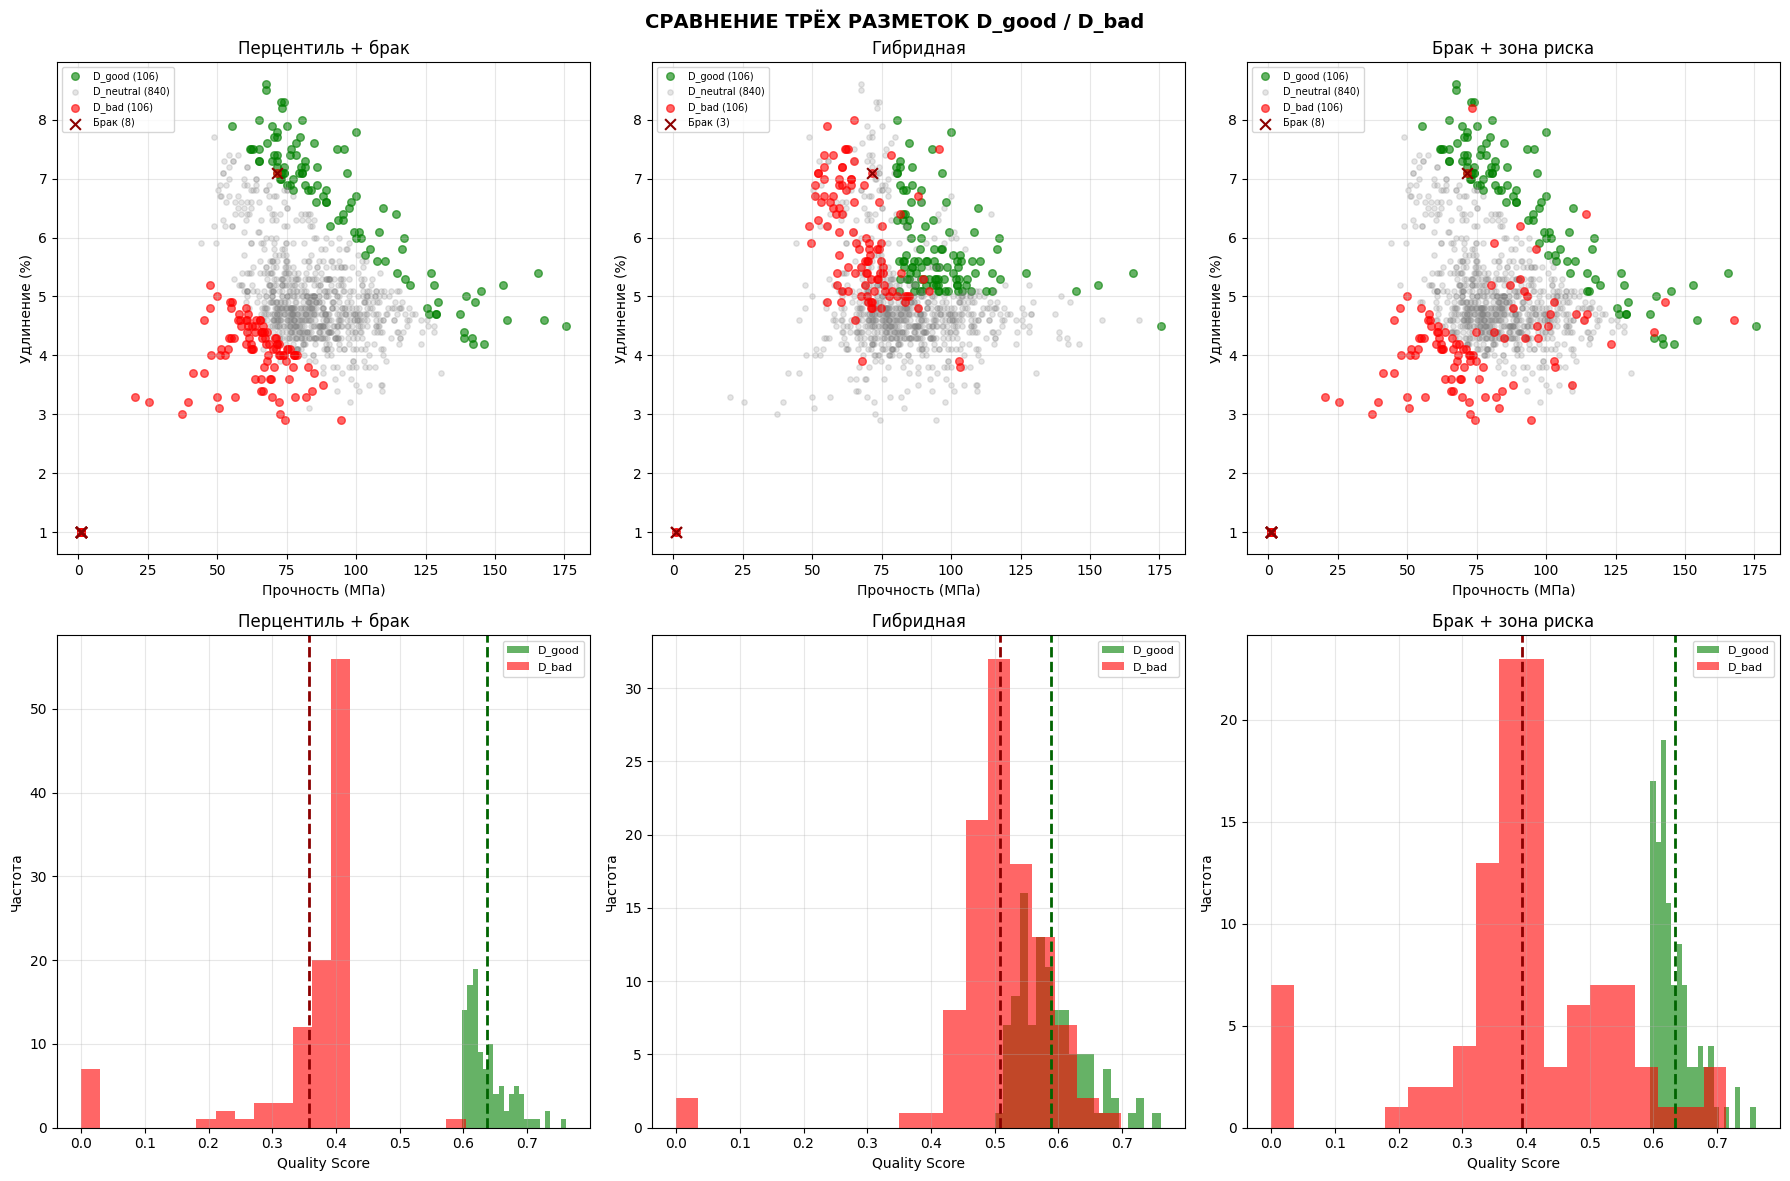

In [7]:
# ============================================================
# 2.4. СРАВНЕНИЕ ТРЁХ РАЗМЕТОК ДЛЯ h(x)
# ============================================================
print("\n" + "="*70)
print("2.4. СРАВНЕНИЕ РАЗМЕТОК D_good / D_bad")
print("="*70)

# ----------------------------------------------------------
# Подготовка quality_score (общая для всех)
# ----------------------------------------------------------
hist_df['strength_norm'] = (hist_df['Прочность'] - hist_df['Прочность'].min()) / \
                            (hist_df['Прочность'].max() - hist_df['Прочность'].min())
hist_df['elong_norm'] = (hist_df['Удлинение'] - hist_df['Удлинение'].min()) / \
                          (hist_df['Удлинение'].max() - hist_df['Удлинение'].min())
hist_df['quality_score'] = (hist_df['strength_norm'] + hist_df['elong_norm']) / 2

TARGET_SIZE = 106  # ~10% от данных

# ============================================================
# РАЗМЕТКА 1: ПЕРЦЕНТИЛЬ 10% + БРАК В D_bad
# ============================================================
print("\n" + "-"*50)
print("РАЗМЕТКА 1: ПЕРЦЕНТИЛЬ 10% + БРАК")
print("-"*50)

# Брак принудительно в D_bad
D_bad_1 = hist_df[hist_df['Брак'] == 1].copy()
remaining_1 = hist_df[hist_df['Брак'] == 0].copy()

# Перцентили
good_threshold_1 = remaining_1['quality_score'].quantile(0.90)
bad_threshold_1 = remaining_1['quality_score'].quantile(0.10)

D_good_1 = remaining_1[remaining_1['quality_score'] >= good_threshold_1].copy()
D_bad_1 = pd.concat([D_bad_1, remaining_1[remaining_1['quality_score'] <= bad_threshold_1]])

# Уравниваем
min_size_1 = min(len(D_good_1), len(D_bad_1))
D_good_1 = D_good_1.head(min_size_1)
D_bad_1 = D_bad_1.head(min_size_1)
D_neutral_1 = hist_df[~hist_df.index.isin(D_good_1.index) & ~hist_df.index.isin(D_bad_1.index)]

print(f"D_good: {len(D_good_1)} | D_bad: {len(D_bad_1)} | D_neutral: {len(D_neutral_1)}")
print(f"Брак в D_good: {D_good_1['Брак'].sum()}, в D_bad: {D_bad_1['Брак'].sum()}")
print(f"Контраст quality: {D_good_1['quality_score'].mean():.4f} vs {D_bad_1['quality_score'].mean():.4f}")

# ============================================================
# РАЗМЕТКА 2: ГИБРИДНАЯ (ТЕХНОЛОГИЧЕСКИЕ ПРАВИЛА)
# ============================================================
print("\n" + "-"*50)
print("РАЗМЕТКА 2: ГИБРИДНАЯ (ПРАВИЛА)")
print("-"*50)

def is_good_by_rules(row):
    return (
        row['Прочность'] > 80 and
        row['Удлинение'] > 5.0 and
        15 <= row['Толщина факт'] <= 32 and
        ((190 <= row['ПВБ2 стадия'] <= 220) or (280 <= row['ПВБ2 стадия'] <= 290)) and
        row['Брак'] == 0
    )

def is_bad_by_rules(row):
    return (
        row['Брак'] == 1 or
        row['Прочность'] < 50 or
        row['Удлинение'] < 4.0 or
        row['Толщина факт'] < 10 or
        row['ПВБ2 стадия'] > 3000
    )

hist_df['good_by_rules'] = hist_df.apply(is_good_by_rules, axis=1)
hist_df['bad_by_rules'] = hist_df.apply(is_bad_by_rules, axis=1)

n_good_rules = hist_df['good_by_rules'].sum()
n_bad_rules = hist_df['bad_by_rules'].sum()
print(f"По правилам: good={n_good_rules}, bad={n_bad_rules}")

# D_bad: правила + добираем по перцентилю
D_bad_2 = hist_df[hist_df['bad_by_rules']].copy()
n_need_2 = max(0, TARGET_SIZE - len(D_bad_2))
if n_need_2 > 0:
    remaining = hist_df[~hist_df.index.isin(D_bad_2.index)]
    D_bad_2 = pd.concat([D_bad_2, remaining.nsmallest(n_need_2, 'quality_score')])

# D_good: правила + добираем
D_good_2 = hist_df[(hist_df['good_by_rules']) & (~hist_df.index.isin(D_bad_2.index))].copy()
n_need_2 = max(0, TARGET_SIZE - len(D_good_2))
if n_need_2 > 0:
    remaining = hist_df[~hist_df.index.isin(D_bad_2.index) & ~hist_df.index.isin(D_good_2.index)]
    D_good_2 = pd.concat([D_good_2, remaining.nlargest(n_need_2, 'quality_score')])

# Уравниваем
min_size_2 = min(len(D_good_2), len(D_bad_2))
D_good_2 = D_good_2.head(min_size_2)
D_bad_2 = D_bad_2.head(min_size_2)
D_neutral_2 = hist_df[~hist_df.index.isin(D_good_2.index) & ~hist_df.index.isin(D_bad_2.index)]

print(f"D_good: {len(D_good_2)} | D_bad: {len(D_bad_2)} | D_neutral: {len(D_neutral_2)}")
print(f"Брак в D_good: {D_good_2['Брак'].sum()}, в D_bad: {D_bad_2['Брак'].sum()}")
print(f"Контраст quality: {D_good_2['quality_score'].mean():.4f} vs {D_bad_2['quality_score'].mean():.4f}")

# ============================================================
# РАЗМЕТКА 3: БРАК + ЗОНА РИСКА
# ============================================================
print("\n" + "-"*50)
print("РАЗМЕТКА 3: БРАК + ЗОНА РИСКА")
print("-"*50)

norm_config = build_normalizer(constraints, EXCLUDE_FROM_NORM)
all_param_names = sorted(list(norm_config.keys()))
print(f"Параметров для нормализации: {len(all_param_names)}")

# Нормализуем все исторические данные
all_norm_temp = [normalize_dict(row.to_dict(), norm_config) for _, row in hist_df.iterrows()]
all_vectors_temp = np.array([[d.get(p, 0.5) for p in all_param_names] for d in all_norm_temp])

# Находим соседей для каждого брака
brak_indices = hist_df[hist_df['Брак'] == 1].index.tolist()
risk_indices = set(brak_indices)
k_neighbors = 5

for brak_idx in brak_indices:
    pos = hist_df.index.get_loc(brak_idx)
    brak_vec = all_vectors_temp[pos]
    distances = np.sum(np.abs(all_vectors_temp - brak_vec), axis=1)
    nearest = np.argsort(distances)[:k_neighbors+1]
    risk_indices.update(nearest)

risk_indices = list(risk_indices)
print(f"Брак + зона риска: {len(risk_indices)} рецептов")

# D_bad: зона риска + добираем по перцентилю
D_bad_3 = hist_df.iloc[risk_indices].copy()
n_need_3 = max(0, TARGET_SIZE - len(D_bad_3))
if n_need_3 > 0:
    remaining = hist_df[~hist_df.index.isin(D_bad_3.index)]
    D_bad_3 = pd.concat([D_bad_3, remaining.nsmallest(n_need_3, 'quality_score')])

# D_good: лучшие из оставшихся
remaining = hist_df[~hist_df.index.isin(D_bad_3.index)]
D_good_3 = remaining.nlargest(TARGET_SIZE, 'quality_score')

# Уравниваем размеры
min_size_3 = min(len(D_good_3), len(D_bad_3))
D_good_3 = D_good_3.head(min_size_3)
D_bad_3 = D_bad_3.head(min_size_3)
D_neutral_3 = hist_df[~hist_df.index.isin(D_good_3.index) & ~hist_df.index.isin(D_bad_3.index)]

print(f"D_good: {len(D_good_3)} | D_bad: {len(D_bad_3)} | D_neutral: {len(D_neutral_3)}")
print(f"Брак в D_good: {D_good_3['Брак'].sum()}, в D_bad: {D_bad_3['Брак'].sum()}")
print(f"Контраст quality: {D_good_3['quality_score'].mean():.4f} vs {D_bad_3['quality_score'].mean():.4f}")

# ============================================================
# СВОДНАЯ ТАБЛИЦА РАЗМЕТОК
# ============================================================
print("\n" + "="*70)
print("СВОДНАЯ ТАБЛИЦА РАЗМЕТОК")
print("="*70)

for i, (name, Dg, Db) in enumerate([
    ('1. Перцентиль + брак', D_good_1, D_bad_1),
    ('2. Гибридная', D_good_2, D_bad_2),
    ('3. Брак + зона риска', D_good_3, D_bad_3)
], 1):
    print(f"\n{name}:")
    print(f"   Размер: D_good={len(Dg)}, D_bad={len(Db)}")
    print(f"   Прочность: D_good={Dg['Прочность'].mean():.0f} МПа, D_bad={Db['Прочность'].mean():.0f} МПа")
    print(f"   Удлинение: D_good={Dg['Удлинение'].mean():.1f}%, D_bad={Db['Удлинение'].mean():.1f}%")
    print(f"   Контраст: {Dg['quality_score'].mean():.4f} vs {Db['quality_score'].mean():.4f}")
    print(f"   Брак в D_good: {Dg['Брак'].sum()}, в D_bad: {Db['Брак'].sum()}")

# ============================================================
# ВИЗУАЛИЗАЦИЯ ВСЕХ ТРЁХ РАЗМЕТОК
# ============================================================
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

for col, (name, Dg, Db, Dn) in enumerate([
    ('Перцентиль + брак', D_good_1, D_bad_1, D_neutral_1),
    ('Гибридная', D_good_2, D_bad_2, D_neutral_2),
    ('Брак + зона риска', D_good_3, D_bad_3, D_neutral_3)
]):
    # Верхний ряд: Scatter
    ax = axes[0, col]
    ax.scatter(Dg['Прочность'], Dg['Удлинение'], c='green', alpha=0.6, s=30, label=f'D_good ({len(Dg)})')
    ax.scatter(Dn['Прочность'], Dn['Удлинение'], c='gray', alpha=0.2, s=15, label=f'D_neutral ({len(Dn)})')
    ax.scatter(Db['Прочность'], Db['Удлинение'], c='red', alpha=0.6, s=30, label=f'D_bad ({len(Db)})')
    # Брак выделяем
    brak = Db[Db['Брак'] == 1]
    if len(brak) > 0:
        ax.scatter(brak['Прочность'], brak['Удлинение'], c='darkred', s=60, marker='x',
                   label=f'Брак ({len(brak)})', zorder=10)
    ax.set_xlabel('Прочность (МПа)')
    ax.set_ylabel('Удлинение (%)')
    ax.set_title(f'{name}')
    ax.legend(fontsize=7, loc='upper left')
    ax.grid(True, alpha=0.3)

    # Нижний ряд: Гистограмма quality_score
    ax = axes[1, col]
    ax.hist(Dg['quality_score'], bins=20, alpha=0.6, color='green', label=f'D_good')
    ax.hist(Db['quality_score'], bins=20, alpha=0.6, color='red', label=f'D_bad')
    ax.axvline(Dg['quality_score'].mean(), color='darkgreen', linestyle='--', linewidth=2)
    ax.axvline(Db['quality_score'].mean(), color='darkred', linestyle='--', linewidth=2)
    ax.set_xlabel('Quality Score')
    ax.set_ylabel('Частота')
    ax.set_title(f'{name}')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle('СРАВНЕНИЕ ТРЁХ РАЗМЕТОК D_good / D_bad', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('three_labelings_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

In [8]:
# ============================================================
# ВЫБОР ФИНАЛЬНОЙ РАЗМЕТКИ ДЛЯ h(x)
# ============================================================
print("\n" + "="*70)
print("ВЫБОР РАЗМЕТКИ: БРАК + ЗОНА РИСКА")
print("="*70)

# Берём разметку 3 (Брак + зона риска)
D_good = D_good_3.copy()
D_bad = D_bad_3.copy()


ВЫБОР РАЗМЕТКИ: БРАК + ЗОНА РИСКА


## 2.5. Нормализация признаков

In [9]:
# ----------------------------------------------------------
# 2.5. НОРМАЛИЗАЦИЯ ТЕХНОЛОГИЧЕСКИХ ПРИЗНАКОВ
# ----------------------------------------------------------

# ----------------------------------------------------------
# ЕДИНАЯ нормализация всех трёх выборок
# ----------------------------------------------------------
print(f"Параметров в конфиге нормализации: {len(norm_config)}")

# Определяем общие технологические параметры
tech_params = sorted([
    p for p in norm_config
    if p in pareto_df.columns and p in hist_df.columns
])
print(f"Общих технологических параметров: {len(tech_params)}")

# Нормализуем все три выборки одним и тем же конфигом
print("\nЕдиная нормализация Парето-фронта, D_good и D_bad...")

pareto_norm = [normalize_dict(row.to_dict(), norm_config) for _, row in pareto_df.iterrows()]
D_good_norm = [normalize_dict(row.to_dict(), norm_config) for _, row in D_good.iterrows()]
D_bad_norm  = [normalize_dict(row.to_dict(), norm_config) for _, row in D_bad.iterrows()]

# ----------------------------------------------------------
# Проверка корректности
# ----------------------------------------------------------
print(f"\nНормализовано:")
print(f"   Парето-фронт: {len(pareto_norm)} точек")
print(f"   D_good:       {len(D_good_norm)} записей")
print(f"   D_bad:        {len(D_bad_norm)} записей")

# Проверка: одинаковые ли значения для одинаковых исходных параметров
# Берём температуру: сравним одно значение из Парето и одно из истории
test_param = 'Вязкость2 стадия'
if test_param in pareto_df.columns and test_param in hist_df.columns:
    # Находим одинаковое значение температуры
    p_vals = pareto_df[test_param].values
    h_vals = hist_df[test_param].values

    # Берём значение, которое есть в обоих датасетах
    common_vals = set(p_vals) & set(h_vals)
    if common_vals:
        test_val = list(common_vals)[0]
        p_norm = normalize_single_value(test_param, test_val, norm_config)
        h_norm = normalize_single_value(test_param, test_val, norm_config)
        print(f"\n🔍 Проверка единообразия нормализации:")
        print(f"   {test_param} = {test_val} → Парето: {p_norm:.4f}, История: {h_norm:.4f}")
        if abs(p_norm - h_norm) < 1e-9:
            print(f"   ✅ Значения совпадают — нормализация единая")
        else:
            print(f"   ⚠️ Значения различаются — что-то не так")

Параметров в конфиге нормализации: 23
Общих технологических параметров: 23

Единая нормализация Парето-фронта, D_good и D_bad...

Нормализовано:
   Парето-фронт: 100 точек
   D_good:       106 записей
   D_bad:        106 записей

🔍 Проверка единообразия нормализации:
   Вязкость2 стадия = 68 → Парето: 0.8286, История: 0.8286
   ✅ Значения совпадают — нормализация единая


## 2.6. Генерация текстовых описаний рецептур

In [10]:
# ----------------------------------------------------------
# 2.6. ПОДГОТОВКА ТЕКСТОВЫХ ОПИСАНИЙ
# ----------------------------------------------------------

# ----------------------------------------------------------
# Функция декодирования партии
# ----------------------------------------------------------
def decode_party(value):
    """
    Декодирует номер партии в читаемый вид.
    Обратная операция к encode_party():
    - целое число → "Партия N"
    - .5 и < 100 → "Партия NA" (A = специальная малая)
    - .5 и > 100 → "Партия NP" (P = специальная большая)
    """
    try:
        v = float(value)
        frac = v - int(v)
        if abs(frac - 0.5) < 0.01:
            if v < 100:
                return f"Партия {int(v)}A"
            else:
                return f"Партия {int(v)}P"
        else:
            return f"Партия {int(v)}"
    except:
        return str(value)


# ----------------------------------------------------------
# Функция форматирования значения в читаемый текст
# ----------------------------------------------------------
def format_raw_value_readable(param_name, raw_value, constraints):
    """
    Форматирует исходное значение параметра в читаемый текст.
    Вся логика декодирования — из constraints.
    """
    cfg = constraints.get(param_name, {})
    param_type = cfg.get('type', 'float')
    unit = cfg.get('unit', '')
    labels = cfg.get('labels', {})
    encoding = cfg.get('encoding', None)

    # 1. Особый случай: партия материала
    if encoding == 'party':
        return decode_party(raw_value)

    # 2. Категориальные с labels
    if labels:
        key = str(raw_value)
        # Пробуем точное совпадение
        if key in labels:
            return labels[key]
        # Пробуем после нормализации (int/float)
        try:
            if param_type == 'int' or (param_type == 'categorical' and float(raw_value) == int(float(raw_value))):
                key_int = str(int(float(raw_value)))
                if key_int in labels:
                    return labels[key_int]
        except:
            pass
        # Не нашли — возвращаем как есть
        return str(raw_value)

    # 3. Числовые с единицами
    if param_type == 'int':
        val = int(float(raw_value))
        return f"{val}{' ' + unit if unit else ''}"
    elif param_type == 'float':
        val = float(raw_value)
        if unit:
            return f"{val:.1f} {unit}"
        else:
            return f"{val:.2f}"
    else:
        return str(raw_value)


# ----------------------------------------------------------
# Функция 1: Embedding-текст (нормализованные)
# ----------------------------------------------------------
def build_embedding_text(norm_params_dict):
    """Компактная строка для эмбеддинг-модели."""
    parts = [f"{name}: {val:.4f}" for name, val in sorted(norm_params_dict.items())]
    return " | ".join(parts)


# ----------------------------------------------------------
# Функция 2: LLM-текст (исходные значения, читаемые)
# ----------------------------------------------------------
def build_llm_text(raw_params_dict, constraints, strength=None, elongation=None):
    """
    Компактная строка для LLM и пользователя.
    Все категории декодируются через constraints.
    """
    parts = []

    for param_name, raw_value in sorted(raw_params_dict.items()):
        if param_name in EXCLUDE_FROM_NORM:
            continue
        formatted = format_raw_value_readable(param_name, raw_value, constraints)
        parts.append(f"  {param_name}: {formatted}")

    result = "\n".join(parts)

    if strength is not None and elongation is not None:
        result += f"\n\nПрогнозируемые показатели:\n  Прочность: {strength:.1f} МПа\n  Удлинение: {elongation:.2f}%"

    return result


# ----------------------------------------------------------
# Генерация
# ----------------------------------------------------------
print("Генерация embedding-текстов (нормализованные)...")
pareto_emb_texts = [build_embedding_text(d) for d in pareto_norm]
D_good_emb_texts = [build_embedding_text(d) for d in D_good_norm]
D_bad_emb_texts  = [build_embedding_text(d) for d in D_bad_norm]

print("Генерация LLM-текстов (читаемые)...")
pareto_llm_texts = []
for i, (_, row) in enumerate(pareto_df.iterrows()):
    raw_params = {p: row[p] for p in pareto_norm[i].keys() if p in row.index}
    pareto_llm_texts.append(build_llm_text(raw_params, constraints,
                                            row.get('strength'), row.get('elongation')))

D_good_llm_texts = []
for i, (_, row) in enumerate(D_good.iterrows()):
    raw_params = {p: row[p] for p in D_good_norm[i].keys() if p in row.index}
    D_good_llm_texts.append(build_llm_text(raw_params, constraints,
                                            row.get('Прочность'), row.get('Удлинение')))

D_bad_llm_texts = []
for i, (_, row) in enumerate(D_bad.iterrows()):
    raw_params = {p: row[p] for p in D_bad_norm[i].keys() if p in row.index}
    D_bad_llm_texts.append(build_llm_text(raw_params, constraints,
                                           row.get('Прочность'), row.get('Удлинение')))

# ----------------------------------------------------------
# Числовые векторы
# ----------------------------------------------------------
all_param_names = sorted(list(pareto_norm[0].keys()))
print(f"\nПараметров в векторе: {len(all_param_names)}")

pareto_vectors = np.array([[d.get(p, 0.5) for p in all_param_names] for d in pareto_norm])
D_good_vectors = np.array([[d.get(p, 0.5) for p in all_param_names] for d in D_good_norm])
D_bad_vectors  = np.array([[d.get(p, 0.5) for p in all_param_names] for d in D_bad_norm])

# ----------------------------------------------------------
# Проверка
# ----------------------------------------------------------
print(f"\nПодготовлено:")
print(f"   Embedding-тексты: {len(pareto_emb_texts)} + {len(D_good_emb_texts)} + {len(D_bad_emb_texts)}")
print(f"   LLM-тексты:       {len(pareto_llm_texts)} + {len(D_good_llm_texts)} + {len(D_bad_llm_texts)}")
print(f"   Числовые векторы: {pareto_vectors.shape}, {D_good_vectors.shape}, {D_bad_vectors.shape}")

Генерация embedding-текстов (нормализованные)...
Генерация LLM-текстов (читаемые)...

Параметров в векторе: 23

Подготовлено:
   Embedding-тексты: 100 + 106 + 106
   LLM-тексты:       100 + 106 + 106
   Числовые векторы: (100, 23), (106, 23), (106, 23)


# 3. Подключение ЛЛМ и загрузка промтов

In [ ]:
ALL_PROMPTS = [
    "У нас сейчас жесткая экономия бюджета. Нужно найти рецептуру, которая будет давать приемлемое качество, но при этом использовать минимальное количество дорогих компонентов. Особенно важно сэкономить на пластификаторах — они сейчас очень дорогие. Прочность пусть будет хотя бы 140 МПа, удлинение — не ниже 6%.",
    "У нас новая смена операторов, они ещё неопытные. Мне нужно, чтобы процесс был максимально стабильным и прощал ошибки. Лучше чуть ниже характеристики, но чтобы рецепт был 'толерантным' к колебаниям температуры и влажности. Параметры не должны быть на грани допустимых значений.",
    "Мы переходим на «зеленое» производство. Нужно максимально снизить содержание органических растворителей в рецептуре. Даже если немного упадет качество — готовы на компромисс. Но прочность не должна быть ниже 130 МПа.",
    "Хочу найти 'золотую середину' — рецептуру, которая будет работать и на старом оборудовании, и на новом. Нужно, чтобы параметры не были привязаны к конкретному типу оборудования. Вязкость должна быть средней, не требующей точной настройки.",
    "У нас жалобы персонала на запах растворителей. Нужно найти рецептуру с минимальным использованием летучих компонентов (Смесь растворителей, Сантисайзер). При этом прочность должна быть высокой (>150 МПа), а удлинение — не критично, но хотя бы 5.5%. Температура в цехе сейчас около 25°C.",
    "Нужна рецептура с прочностью > 140 МПа и удлинением > 7%. Температура не выше 24°C, влажность около 50%, вязкость низкая.",
    "У нас проблема: на ночной смене оборудование работает при пониженной температуре (около 21°C), а дневная смена работает при 24°C. Нужна рецептура, которая даст стабильные результаты в ОБОИХ режимах. Мы не можем менять рецептуру каждый раз — это снижает производительность. Пожалуйста, найди 'терпимую' рецептуру, чтобы и там, и там было нормально."
]

In [ ]:
SCENARIO_NAMES = [
    'Экономия бюджета',           # 1
    'Стабильность для новичков',  # 2
    'Зелёное производство',       # 3
    'Золотая середина',           # 4
    'Запах растворителей',        # 5
    'Конкретные требования',      # 6
    'Две смены'                   # 7
]

In [ ]:
# ----------------------------------------------------------
# ВЫБОР АКТИВНЫХ СЦЕНАРИЕВ
# ----------------------------------------------------------
# Выберите один или несколько:
# active_scenario_ids = [1, 2, 3, 4, 5, 6, 7]  # все
# active_scenario_ids = [1, 5, 6]                # выборочно
active_scenario_ids = [5]                        # только один

In [ ]:
# Формируем список активных промптов
ACTIVE_PROMPTS = [ALL_PROMPTS[i-1] for i in active_scenario_ids]

print(f"\n📋 Всего сценариев: {len(ALL_PROMPTS)}")
print(f"✅ Активных: {len(active_scenario_ids)}")
for sid in active_scenario_ids:
    print(f"   {sid}. {SCENARIO_NAMES[sid-1]}")
    print(f"      {ALL_PROMPTS[sid-1][:100]}...")


📋 Всего сценариев: 7
✅ Активных: 1
   5. Запах растворителей
      У нас жалобы персонала на запах растворителей. Нужно найти рецептуру с минимальным использованием ле...


In [ ]:
# ----------------------------------------------------------
# Динамическое формирование промпта
# ----------------------------------------------------------

TARGET_PARAMS = ['Прочность', 'Удлинение', 'Брак']
TECH_PARAMS = [name for name in constraints.keys() if name not in TARGET_PARAMS]

def build_preference_extraction_prompt(tech_params=None):
    if tech_params is None:
        tech_params = TECH_PARAMS

    params_list = ", ".join(tech_params)

    prompt = f"""Проанализируй текст технолога и верни СТРОГО JSON.

ШАГ 1. Определи веса (w1 + w2 = 1):
Прочитай текст и ответь на вопрос: ЧТО ВАЖНЕЕ для технолога — прочность или удлинение?
- Если из запроса понимаешь что прочность важнее, то ставь для w1 значение больше, чем w2
- Если из запроса понимаешь что удлинение важнее, то ставь для w2 значение больше, чем w1
- т.е. распредели степень важности для прочности и удлинения исходя из запроса
- Если одинаково важны → w1 = 0.5, w2 = 0.5
- "хотя бы" означает минимальный порог, а не высокую важность
- "главное" перед параметром означает, что этот параметр ВАЖНЕЕ

ШАГ 2. Найди предпочтения по параметрам.
Ищи в тексте ТОЛЬКО явные указания. Доступные параметры:
{params_list}

Правила:
- "сэкономить", "меньше", "дешёвый", "минимум", "снизить", "не выше", "пониженная" → "direction": "minimize"
- "высокая", "больше", "максимум", "не ниже" → "direction": "maximize"
- "пластификаторы" → добавь ТЭА, ЭГ, Гл (все три с одинаковым direction)
- "растворители" → добавь Смесь растворителей, Сантисайзер
- "стабильность", "средняя", "умеренная" → НЕ добавляй
- Прочность и Удлинение НЕ добавляй в preferences

ШАГ 3. Проверь себя:
- w1 + w2 = 1?
- Все param из списка доступных?
- Не добавил ли ты Прочность или Удлинение в preferences?

Примеры:
Текст: "Нужна высокая прочность, удлинение не важно"
Ответ: {{"w1": 0.9, "w2": 0.1, "preferences": []}}

Текст: "Прочность хотя бы 100 МПа, главное удлинение > 8%, температура не выше 22°C"
Ответ: {{"w1": 0.3, "w2": 0.7, "preferences": [{{"param": "Температура", "direction": "minimize"}}]}}

Текст: "Экономим пластификаторы, прочность и удлинение одинаково важны"
Ответ: {{"w1": 0.5, "w2": 0.5, "preferences": [{{"param": "ТЭА", "direction": "minimize"}}, {{"param": "ЭГ", "direction": "minimize"}}, {{"param": "Гл", "direction": "minimize"}}]}}

Верни ТОЛЬКО JSON:"""

    return prompt


PREFERENCE_EXTRACTION_PROMPT = build_preference_extraction_prompt()

print(f"\n📋 Технологических параметров: {len(TECH_PARAMS)}")
print(f"   Промпт для LLM: {len(PREFERENCE_EXTRACTION_PROMPT)} символов")


📋 Технологических параметров: 23
   Промпт для LLM: 2172 символов


In [ ]:
# ============================================================
# ПОДКЛЮЧЕНИЕ ЛОКАЛЬНОЙ LLM ЧЕРЕЗ OLLAMA
# ============================================================
import requests

# Модель
OLLAMA_MODEL = "qwen2.5:7b"
OLLAMA_API_URL = "http://localhost:11434/api/chat"

print(f"🔧 Модель: {OLLAMA_MODEL}")
print(f"🌐 API: {OLLAMA_API_URL}")

# ЕДИНАЯ функция вызова
def get_llm_response(prompt, max_tokens=1024, system_role="default"):
    """
    Вызов Ollama через REST API.

    Параметры:
        prompt: текст запроса
        max_tokens: максимальное количество токенов в ответе
        system_role:
            - "preferences" — для извлечения JSON
            - "technologist" — для ответов технолога
            - "default" — универсальный
    """
    # Системный промпт
    if system_role == "preferences":
        system_msg = "Ты — система извлечения технологических предпочтений для производства MLCC-конденсаторов. Отвечай ТОЛЬКО JSON."
    elif system_role == "technologist":
        system_msg = "Ты — опытный технолог производства MLCC-конденсаторов. Отвечай по-русски."
    else:
        system_msg = "Ты — эксперт-технолог производства MLCC-конденсаторов. Отвечай по-русски."

    try:
        response = requests.post(
            OLLAMA_API_URL,
            json={
                "model": OLLAMA_MODEL,
                "messages": [
                    {"role": "system", "content": system_msg},
                    {"role": "user", "content": prompt}
                ],
                "stream": False,
                "options": {
                    "temperature": 0.0,
                    "num_predict": max_tokens
                }
            },
            timeout=180
        )

        if response.status_code == 200:
            result = response.json()
            return result['message']['content'].strip()
        else:
            print(f"⚠️ Ошибка API: {response.status_code}")
            return '{"w1": 0.5, "w2": 0.5, "preferences": []}'

    except requests.exceptions.ConnectionError:
        print("⚠️ Ollama API недоступен. Запустите: ollama serve")
        return '{"w1": 0.5, "w2": 0.5, "preferences": []}'
    except requests.exceptions.Timeout:
        print("⚠️ Таймаут Ollama (3 минуты)")
        return '{"w1": 0.5, "w2": 0.5, "preferences": []}'
    except Exception as e:
        print(f"⚠️ Ошибка: {e}")
        return '{"w1": 0.5, "w2": 0.5, "preferences": []}'

🔧 Модель: qwen2.5:7b
🌐 API: http://localhost:11434/api/chat


In [ ]:
# Быстрая проверка
print("\n📝 Проверка 1 (default — свободный ответ):")
response1 = get_llm_response("Что такое MLCC? Ответь кратко.", max_tokens=250)
print(f"   Ответ: {response1}")


📝 Проверка 1 (default — свободный ответ):
   Ответ: MLCC — это многослойные керамические конденсаторы. Это тип электрических компонентов, используемых в различных электронных устройствах для хранения и разряда заряда.


In [ ]:
print("\n📝 Проверка 2 (technologist — ответ технолога):")
response2 = get_llm_response(
    "Что лучше для производства: температура 20°C или 25°C? Объясни кратко почему.",
    system_role="technologist"
)
print(f"   Ответ: {response2}")


📝 Проверка 2 (technologist — ответ технолога):
   Ответ: Для производства MLCC-конденсаторов предпочтительнее использовать температуру 25°C по сравнению с 20°C. При более высокой температуре увеличивается скорость химических реакций и процессов высыхания, что может ускорить циклы производства. Однако важно учитывать, что слишком высокая температура может повлиять на качество материалов или equipment. Температура 25°C обеспечивает баланс между скоростью процесса и качеством продукции.


In [ ]:
print("\n📝 Проверка 3 (preferences — извлечение JSON из реального промпта):")

test_text = "У нас сейчас жесткая экономия бюджета. Особенно важно сэкономить на пластификаторах — они сейчас очень дорогие. Прочность пусть будет хотя бы 90 МПа, главное удлинение — не ниже 9%."

print(f"   Текст технолога: {test_text}")

# Формируем промпт динамически (без хардкода параметров)
full_prompt = PREFERENCE_EXTRACTION_PROMPT + f"\n\nТекст технолога:\n{test_text}"

try:
    r3 = get_llm_response(full_prompt, max_tokens=1024, system_role="preferences")
    print(f"   Сырой ответ: {r3[:300]}")

    # Парсим JSON
    json_match = re.search(r'\{.*\}', r3, re.DOTALL)
    if json_match:
        parsed = json.loads(json_match.group())
        print(f"\n   ✅ Парсинг успешен:")
        print(f"      w1 (прочность) = {parsed.get('w1')}")
        print(f"      w2 (удлинение) = {parsed.get('w2')}")
        print(f"      w1 + w2 = {parsed.get('w1', 0) + parsed.get('w2', 0):.2f}")

        prefs = parsed.get('preferences', [])
        if prefs:
            print(f"      Предпочтения ({len(prefs)}):")
            for p in prefs:
                param = p.get('param', '?')
                direction = p.get('direction', '?')
                valid = '✅' if param in TECH_PARAMS else '❌ (нет в списке)'
                print(f"        • {param} → {direction} {valid}")
        else:
            print(f"      Предпочтения: не найдены")
    else:
        print(f"\n   ❌ JSON не найден в ответе")
        print(f"   Полный ответ: {r3}")

except Exception as e:
    print(f"   ❌ Ошибка: {e}")

print("\n✅ Тест всех ролей завершён.")
print(f"   Промпт сформирован динамически из {len(TECH_PARAMS)} параметров constraints")


📝 Проверка 3 (preferences — извлечение JSON из реального промпта):
   Текст технолога: У нас сейчас жесткая экономия бюджета. Особенно важно сэкономить на пластификаторах — они сейчас очень дорогие. Прочность пусть будет хотя бы 90 МПа, главное удлинение — не ниже 9%.
   Сырой ответ: {"w1": 0.3, "w2": 0.7, "preferences": [{"param": "ТЭА", "direction": "minimize"}, {"param": "ЭГ", "direction": "minimize"}, {"param": "Гл", "direction": "minimize"}]}

   ✅ Парсинг успешен:
      w1 (прочность) = 0.3
      w2 (удлинение) = 0.7
      w1 + w2 = 1.00
      Предпочтения (3):
        • ТЭА → minimize ✅
        • ЭГ → minimize ✅
        • Гл → minimize ✅

✅ Тест всех ролей завершён.
   Промпт сформирован динамически из 23 параметров constraints


In [ ]:
print("\n📝 Проверка 3 (preferences — извлечение JSON из реального промпта):")

test_text = "У нас сейчас жесткая экономия бюджета. Особенно важно сэкономить на пластификаторах — они сейчас очень дорогие. Пусть удлинение будет хотя бы 7%, главное прочность — не ниже 100."

print(f"   Текст технолога: {test_text}")

# Формируем промпт динамически (без хардкода параметров)
full_prompt = PREFERENCE_EXTRACTION_PROMPT + f"\n\nТекст технолога:\n{test_text}"

try:
    r3 = get_llm_response(full_prompt, max_tokens=1024, system_role="preferences")
    print(f"   Сырой ответ: {r3[:300]}")

    # Парсим JSON
    json_match = re.search(r'\{.*\}', r3, re.DOTALL)
    if json_match:
        parsed = json.loads(json_match.group())
        print(f"\n   ✅ Парсинг успешен:")
        print(f"      w1 (прочность) = {parsed.get('w1')}")
        print(f"      w2 (удлинение) = {parsed.get('w2')}")
        print(f"      w1 + w2 = {parsed.get('w1', 0) + parsed.get('w2', 0):.2f}")

        prefs = parsed.get('preferences', [])
        if prefs:
            print(f"      Предпочтения ({len(prefs)}):")
            for p in prefs:
                param = p.get('param', '?')
                direction = p.get('direction', '?')
                valid = '✅' if param in TECH_PARAMS else '❌ (нет в списке)'
                print(f"        • {param} → {direction} {valid}")
        else:
            print(f"      Предпочтения: не найдены")
    else:
        print(f"\n   ❌ JSON не найден в ответе")
        print(f"   Полный ответ: {r3}")

except Exception as e:
    print(f"   ❌ Ошибка: {e}")

print("\n✅ Тест всех ролей завершён.")
print(f"   Промпт сформирован динамически из {len(TECH_PARAMS)} параметров constraints")


📝 Проверка 3 (preferences — извлечение JSON из реального промпта):
   Текст технолога: У нас сейчас жесткая экономия бюджета. Особенно важно сэкономить на пластификаторах — они сейчас очень дорогие. Пусть удлинение будет хотя бы 7%, главное прочность — не ниже 100.
   Сырой ответ: {"w1": 0.9, "w2": 0.1, "preferences": [{"param": "ТЭА", "direction": "minimize"}, {"param": "ЭГ", "direction": "minimize"}, {"param": "Гл", "direction": "minimize"}]}

   ✅ Парсинг успешен:
      w1 (прочность) = 0.9
      w2 (удлинение) = 0.1
      w1 + w2 = 1.00
      Предпочтения (3):
        • ТЭА → minimize ✅
        • ЭГ → minimize ✅
        • Гл → minimize ✅

✅ Тест всех ролей завершён.
   Промпт сформирован динамически из 23 параметров constraints


# 4. БАЗОВЫЕ КОМПОНЕНТЫ

   4.1. Функция гиперобъёма
   
   4.2. Функция эвристики h(x)

   4.3. Функция мягких штрафов P(x)

   4.4. Нормализация компонент

## 4.1. Функция гиперобъёма

In [ ]:
# ============================================================
# 4. БАЗОВЫЕ КОМПОНЕНТЫ
# ============================================================

# ----------------------------------------------------------
# 4.1. Функция гиперобъёма
# ----------------------------------------------------------
print("\n" + "=" * 70)
print("4.1. Функция гиперобъёма")
print("=" * 70)

def compute_hypervolume(strength, elongation, ref_strength, ref_elongation):
    """
    Вычисляет гиперобъём для одной точки Парето-фронта (для задачи максимизации).

    Геометрический смысл:
        Прямоугольник от референсной точки (слева-снизу) до точки на фронте (справа-сверху).
        Чем больше площадь — тем лучше точка сбалансирована по обоим критериям.

    Параметры:
        strength, elongation: значения целевых функций (МПа, %)
        ref_strength, ref_elongation: референсная точка (хуже всех)

    Возвращает:
        Значение гиперобъёма (чем больше, тем лучше)
    """
    # return (ref_strength - strength) * (ref_elongation - elongation)
    # return (strength - ref_strength) * (elongation - ref_elongation)
    delta_s = strength - ref_strength
    delta_e = elongation - ref_elongation
    return max(0, delta_s * delta_e)

def compute_all_hypervolumes(pareto_df, margin_percent=5.0):
    """
    Вычисляет гиперобъём для всех точек Парето-фронта.

    Параметры:
        pareto_df: датафрейм с колонками 'strength' и 'elongation'
        margin_percent: отступ референсной точки от максимумов (в процентах от размаха)

    Возвращает:
        hv_values: массив значений гиперобъёма
        ref_point: кортеж (ref_strength, ref_elongation)
    """
    f1 = pareto_df['strength'].values
    f2 = pareto_df['elongation'].values

    # Диапазоны
    f1_min, f2_min = f1.min(), f2.min()
    f1_max, f2_max = f1.max(), f2.max()

    # Отступы: 5% от размаха вниз от минимума
    margin1 = (f1_max - f1_min) * (margin_percent / 100)
    margin2 = (f2_max - f2_min) * (margin_percent / 100)

    # Референсная точка — немного хуже наихудших значений
    ref_strength = f1_min - margin1
    ref_elongation = f2_min - margin2

    # Гиперобъём для каждой точки
    hv_values = np.array([
        compute_hypervolume(s, e, ref_strength, ref_elongation)
        for s, e in zip(f1, f2)
    ])

    print(f"   Диапазон прочности:        {f1_min:.1f} – {f1_max:.1f} МПа")
    print(f"   Диапазон удлинения:         {f2_min:.2f} – {f2_max:.2f}%")
    print(f"   Отступ реф. точки:          {margin_percent:.1f}% от размаха")
    print(f"   Референсная точка:          ({ref_strength:.1f} МПа, {ref_elongation:.2f}%)")
    print(f"   Гиперобъём:                 min={hv_values.min():.2f}, max={hv_values.max():.2f}, mean={hv_values.mean():.2f}")
    print(f"   Стандартное отклонение:      {hv_values.std():.2f}")

    return hv_values, (ref_strength, ref_elongation)

# Вычисление
hv_values, ref_point = compute_all_hypervolumes(pareto_df)
pareto_df['HV'] = hv_values


4.1. Функция гиперобъёма
   Диапазон прочности:        78.4 – 174.9 МПа
   Диапазон удлинения:         5.94 – 10.00%
   Отступ реф. точки:          5.0% от размаха
   Референсная точка:          (73.6 МПа, 5.74%)
   Гиперобъём:                 min=20.58, max=156.50, mean=100.10
   Стандартное отклонение:      40.85


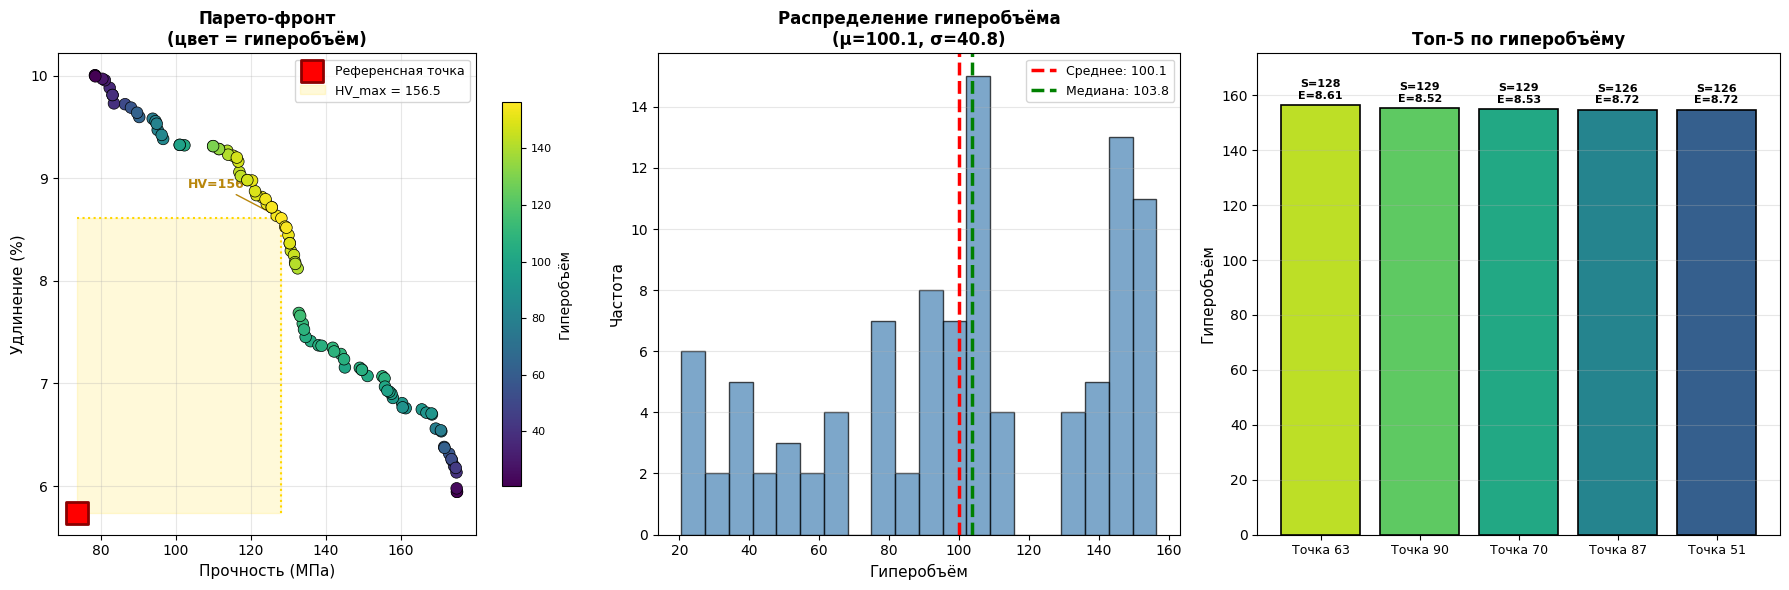

In [ ]:
# ================================================================
# ВИЗУАЛИЗАЦИЯ
# ================================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# ----------------------------------------------------------------
# График 1: Парето-фронт с референсной точкой
# ----------------------------------------------------------------
ax = axes[0]
sc = ax.scatter(pareto_df['strength'], pareto_df['elongation'],
                c=hv_values, cmap='viridis', s=70, edgecolors='black', linewidth=0.5,
                zorder=5)
ax.scatter(ref_point[0], ref_point[1], c='red', s=250, marker='s',
           edgecolors='darkred', linewidth=2, label='Референсная точка', zorder=10)

# Показываем прямоугольник для лучшей точки
best_idx = np.argmax(hv_values)
best_s = pareto_df.iloc[best_idx]['strength']
best_e = pareto_df.iloc[best_idx]['elongation']
rect = plt.Rectangle((ref_point[0], ref_point[1]),
                      best_s - ref_point[0], best_e - ref_point[1],
                      fill=True, alpha=0.15, color='gold', zorder=1,
                      label=f'HV_max = {hv_values[best_idx]:.1f}')
ax.add_patch(rect)
ax.plot([ref_point[0], best_s], [best_e, best_e], 'gold', linestyle=':', linewidth=1.5, zorder=2)
ax.plot([best_s, best_s], [ref_point[1], best_e], 'gold', linestyle=':', linewidth=1.5, zorder=2)
ax.annotate(f'HV={hv_values[best_idx]:.0f}',
            xy=(best_s, best_e), xytext=(best_s-25, best_e+0.3),
            fontsize=9, fontweight='bold', color='darkgoldenrod',
            arrowprops=dict(arrowstyle='->', color='darkgoldenrod'))

ax.set_xlabel('Прочность (МПа)', fontsize=11)
ax.set_ylabel('Удлинение (%)', fontsize=11)
ax.set_title('Парето-фронт\n(цвет = гиперобъём)', fontsize=12, fontweight='bold')
ax.legend(fontsize=9, loc='upper right')
ax.grid(True, alpha=0.3)
cbar = plt.colorbar(sc, ax=ax, label='Гиперобъём', shrink=0.8)
cbar.ax.tick_params(labelsize=8)

# ----------------------------------------------------------------
# График 2: Распределение гиперобъёма
# ----------------------------------------------------------------
ax = axes[1]
n_bins = int(np.sqrt(len(hv_values))) * 2  # правило квадратного корня для числа бинов
ax.hist(hv_values, bins=n_bins, color='steelblue', edgecolor='black', alpha=0.7)
ax.axvline(hv_values.mean(), color='red', linestyle='--', linewidth=2.5,
           label=f'Среднее: {hv_values.mean():.1f}')
ax.axvline(np.median(hv_values), color='green', linestyle='--', linewidth=2.5,
           label=f'Медиана: {np.median(hv_values):.1f}')
ax.set_xlabel('Гиперобъём', fontsize=11)
ax.set_ylabel('Частота', fontsize=11)
ax.set_title(f'Распределение гиперобъёма\n(μ={hv_values.mean():.1f}, σ={hv_values.std():.1f})',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, axis='y')

# ----------------------------------------------------------------
# График 3: Топ-5 по гиперобъёму (с запасом по шкале)
# ----------------------------------------------------------------
ax = axes[2]
top5_idx = np.argsort(hv_values)[-5:][::-1]
top5_hv = hv_values[top5_idx]

# Цвета: градиент от тёмно-синего к золотому
colors_top5 = plt.cm.viridis(np.linspace(0.3, 0.9, 5))[::-1]
bars = ax.bar(range(5), top5_hv, color=colors_top5, edgecolor='black', linewidth=1.2)

# Аннотации
for i, (idx, hv) in enumerate(zip(top5_idx, top5_hv)):
    s = pareto_df.iloc[idx]['strength']
    e = pareto_df.iloc[idx]['elongation']
    ax.text(i, hv + top5_hv.max() * 0.015,
            f'S={s:.0f}\nE={e:.2f}',
            ha='center', fontsize=8, fontweight='bold')

ax.set_xticks(range(5))
ax.set_xticklabels([f'Точка {idx}' for idx in top5_idx], fontsize=9)
ax.set_ylabel('Гиперобъём', fontsize=11)
ax.set_title('Топ-5 по гиперобъёму', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

# РАСШИРЯЕМ ШКАЛУ Y — добавляем 10% сверху
y_max = top5_hv.max() * 1.12
ax.set_ylim(0, y_max)

plt.tight_layout()
plt.savefig('hypervolume_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ================================================================
# ТАБЛИЦА 1: ТОП-3 ЛУЧШИХ И ТОП-3 ХУДШИХ ПО ГИПЕРОБЪЁМУ
# ================================================================
print("\n" + "=" * 70)
print("ТАБЛИЦА: ТОП-3 ЛУЧШИХ И ТОП-3 ХУДШИХ РЕЦЕПТУР ПО ГИПЕРОБЪЁМУ")
print("=" * 70)

# Индексы
top3_best_idx = np.argsort(hv_values)[-3:][::-1]   # лучшие
top3_worst_idx = np.argsort(hv_values)[:3]           # худшие

# Все 6 индексов по порядку
all_6_idx = list(top3_best_idx) + list(top3_worst_idx)
col_labels = [f'🏆 ЛУЧШИЙ {i+1}\nТочка {idx}\nS={pareto_df.iloc[idx]["strength"]:.0f} МПа, E={pareto_df.iloc[idx]["elongation"]:.2f}%, HV={hv_values[idx]:.1f}'
              for i, idx in enumerate(top3_best_idx)]
col_labels += [f'⚠️ ХУДШИЙ {i+1}\nТочка {idx}\nS={pareto_df.iloc[idx]["strength"]:.0f} МПа, E={pareto_df.iloc[idx]["elongation"]:.2f}%, HV={hv_values[idx]:.1f}'
               for i, idx in enumerate(top3_worst_idx)]

# Технологические параметры для отображения
TARGET_PARAMS = ['Прочность', 'Удлинение', 'Брак']
TECH_PARAMS = [name for name in constraints.keys() if name not in TARGET_PARAMS]

# Единицы измерения
UNITS = {}
for name, cfg in constraints.items():
    unit = cfg.get('unit', '')
    if unit:
        UNITS[name] = unit

# Строим данные для таблицы
table_data = []
for param in TECH_PARAMS:
    row = [param]
    for idx in all_6_idx:
        val = pareto_df.iloc[idx][param]
        # Используем функцию из раздела 2.6
        formatted = format_raw_value_readable(param, val, constraints)
        row.append(formatted)
    table_data.append(row)

# Создаём DataFrame для таблицы
col_headers = ['Параметр'] + col_labels
table_df = pd.DataFrame(table_data, columns=col_headers)

# Вывод таблицы с цветовым оформлением
def color_best_worst(val, col_idx, n_cols):
    """Подсветка: зелёный для лучших, красный для худших."""
    if col_idx == 0:
        return ''
    elif col_idx <= 3:
        return 'background-color: #e6ffe6'  # светло-зелёный для лучших
    else:
        return 'background-color: #ffe6e6'  # светло-красный для худших

# Применяем стили
styled = table_df.style.set_caption(
    'Сравнение ТОП-3 лучших и ТОП-3 худших рецептур по гиперобъёму'
).set_table_styles([
    {'selector': 'caption', 'props': [('font-weight', 'bold'), ('font-size', '14px'), ('text-align', 'center')]},
    {'selector': 'th', 'props': [('text-align', 'center'), ('font-size', '11px'), ('vertical-align', 'top')]},
    {'selector': 'td', 'props': [('text-align', 'center'), ('font-size', '10px'), ('padding', '3px 6px')]}
]).apply(lambda row: [color_best_worst(row.name, i, len(row)) for i in range(len(row))], axis=1)

display(styled)


ТАБЛИЦА: ТОП-3 ЛУЧШИХ И ТОП-3 ХУДШИХ РЕЦЕПТУР ПО ГИПЕРОБЪЁМУ


,Параметр,"🏆 ЛУЧШИЙ 1 Точка 63 S=128 МПа, E=8.61%, HV=156.5","🏆 ЛУЧШИЙ 2 Точка 90 S=129 МПа, E=8.52%, HV=155.2","🏆 ЛУЧШИЙ 3 Точка 70 S=129 МПа, E=8.53%, HV=154.9","⚠️ ХУДШИЙ 1 Точка 0 S=175 МПа, E=5.94%, HV=20.6","⚠️ ХУДШИЙ 2 Точка 2 S=175 МПа, E=5.94%, HV=20.6","⚠️ ХУДШИЙ 3 Точка 1 S=78 МПа, E=10.00%, HV=20.6"
0,Доля в загрузке,60%,60%,60%,80%,80%,40%
1,Опыт,Да,Да,Да,Да,Да,Да
2,Вид оборудования,Барабан,Барабан,Барабан,Барабан,Барабан,Барабан
3,Количество оборудования,10 шт.,9 шт.,10 шт.,11 шт.,11 шт.,10 шт.
4,Партия керамического материала,Партия 51A,Партия 51A,Партия 51A,Партия 177P,Партия 177P,Партия 51A
5,Вес,809 г,809 г,772 г,3082 г,3033 г,525 г
6,Вес загрузки,800 кг,800 кг,800 кг,800 кг,800 кг,800 кг
7,ПВБ1 стадия,735 г,735 г,735 г,60 г,60 г,585 г
8,ПВБ2 стадия,3805.2 г,3796.2 г,3774.6 г,3719.1 г,3719.1 г,192.4 г
9,ПВБ2 стадия процент,15%,15%,15%,15%,15%,15%


In [ ]:
# ================================================================
# ТАБЛИЦА 2: СТАТИСТИКА ПО ГРУППАМ
# ================================================================
print("\n" + "=" * 70)
print("СТАТИСТИКА: ЛУЧШИЕ И ХУДШИЕ ПО ГИПЕРОБЪЁМУ")
print("=" * 70)

best_group = pareto_df.iloc[top3_best_idx]
worst_group = pareto_df.iloc[top3_worst_idx]

stats_data = {
    'Показатель': ['Прочность (МПа)', 'Удлинение (%)', 'Гиперобъём'],
    'Лучшие (среднее)': [f'{best_group["strength"].mean():.1f}',
                         f'{best_group["elongation"].mean():.2f}',
                         f'{hv_values[top3_best_idx].mean():.1f}'],
    'Худшие (среднее)': [f'{worst_group["strength"].mean():.1f}',
                          f'{worst_group["elongation"].mean():.2f}',
                          f'{hv_values[top3_worst_idx].mean():.1f}'],
    'Разница': [f'{best_group["strength"].mean() - worst_group["strength"].mean():.1f}',
                f'{best_group["elongation"].mean() - worst_group["elongation"].mean():.2f}',
                f'{hv_values[top3_best_idx].mean() - hv_values[top3_worst_idx].mean():.1f}']
}
stats_df = pd.DataFrame(stats_data)
display(stats_df.style.set_caption('Сравнение средних показателей'))


СТАТИСТИКА: ЛУЧШИЕ И ХУДШИЕ ПО ГИПЕРОБЪЁМУ


,Показатель,Лучшие (среднее),Худшие (среднее),Разница
0,Прочность (МПа),128.9,142.7,-13.9
1,Удлинение (%),8.55,7.30,1.26
2,Гиперобъём,155.5,20.6,135.0


In [ ]:
# ================================================================
# ВЫВОДЫ
# ================================================================
print("\n" + "=" * 70)
print("ВЫВОДЫ ПО ГИПЕРОБЪЁМУ")
print("=" * 70)

print(f"""
1. Геометрический смысл:
   • Гиперобъём = площадь прямоугольника между точкой и референсной точкой
   • Референсная точка ({ref_point[0]:.1f}, {ref_point[1]:.2f}) — наихудшие достижимые значения

2. Какие точки имеют максимальный HV:
   • Точки с БАЛАНСОМ прочности и удлинения
   • Не экстремальные (где один показатель на минимуме)
   • Лучшая точка: S={best_s:.0f} МПа, E={best_e:.2f}%, HV={hv_values.max():.1f}

3. Практический смысл для ранжирования:
   • HV измеряет "оптимизационное качество" — насколько точка хороша с точки зрения Парето-оптимальности
   • HV НЕ учитывает технологические предпочтения и исторический опыт
   • Поэтому в гибридных методах HV комбинируется с h(x) и P(x)

""")


ВЫВОДЫ ПО ГИПЕРОБЪЁМУ

1. Геометрический смысл:
   • Гиперобъём = площадь прямоугольника между точкой и референсной точкой
   • Референсная точка (73.6, 5.74) — наихудшие достижимые значения

2. Какие точки имеют максимальный HV:
   • Точки с БАЛАНСОМ прочности и удлинения
   • Не экстремальные (где один показатель на минимуме)
   • Лучшая точка: S=128 МПа, E=8.61%, HV=156.5

3. Практический смысл для ранжирования:
   • HV измеряет "оптимизационное качество" — насколько точка хороша с точки зрения Парето-оптимальности
   • HV НЕ учитывает технологические предпочтения и исторический опыт
   • Поэтому в гибридных методах HV комбинируется с h(x) и P(x)




Ключевой вывод: гиперобъём вознаграждает баланс, а не экстремальные значения.

1. HV-оптимальные точки — это компромиссные решения, которые на практике могут быть предпочтительнее экстремальных

2. Ограничение HV-only подхода: он не учитывает, что на практике может требоваться, например, прочность >150 МПа (тогда точки 63, 90, 70 не подойдут)

3. Роль весовых коэффициентов: в следующих блоках через веса сценариев можно сместить предпочтение в сторону прочности или удлинения

4. Эвристика h(x) добавит учёт исторического опыта

## 4.2. Функция эвристики h(x)


4.2. ПОЛНОЕ СРАВНЕНИЕ h(x)

Обработка: Перцентиль + брак
  Косинус             : [-0.0121, 0.0750] μ=0.0306 | h<0: 15% | h>0.5: 0%
  Евклид (среднее)    : [-0.0399, 0.1395] μ=0.0479 | h<0: 30% | h>0.5: 0%
  Манхэттен (среднее) : [-0.0329, 0.6981] μ=0.3700 | h<0: 3% | h>0.5: 37%
  Манхэттен (k-NN)    : [-0.2757, 0.5011] μ=0.1612 | h<0: 40% | h>0.5: 2%

Обработка: Гибридная
  Косинус             : [-0.0937, 0.1257] μ=0.0052 | h<0: 41% | h>0.5: 0%
  Евклид (среднее)    : [0.2592, 0.7483] μ=0.5351 | h<0: 0% | h>0.5: 64%
  Манхэттен (среднее) : [0.9428, 0.9999] μ=0.9928 | h<0: 0% | h>0.5: 100%
  Манхэттен (k-NN)    : [0.6983, 0.9639] μ=0.8525 | h<0: 0% | h>0.5: 100%

Обработка: Брак + зона риска
  Косинус             : [-0.0112, 0.0643] μ=0.0290 | h<0: 10% | h>0.5: 0%
  Евклид (среднее)    : [-0.1012, 0.0020] μ=-0.0483 | h<0: 97% | h>0.5: 0%
  Манхэттен (среднее) : [-0.4543, 0.1832] μ=-0.1337 | h<0: 64% | h>0.5: 0%
  Манхэттен (k-NN)    : [-0.4449, 0.1265] μ=-0.1345 | h<0: 66% | h>0.5: 0%


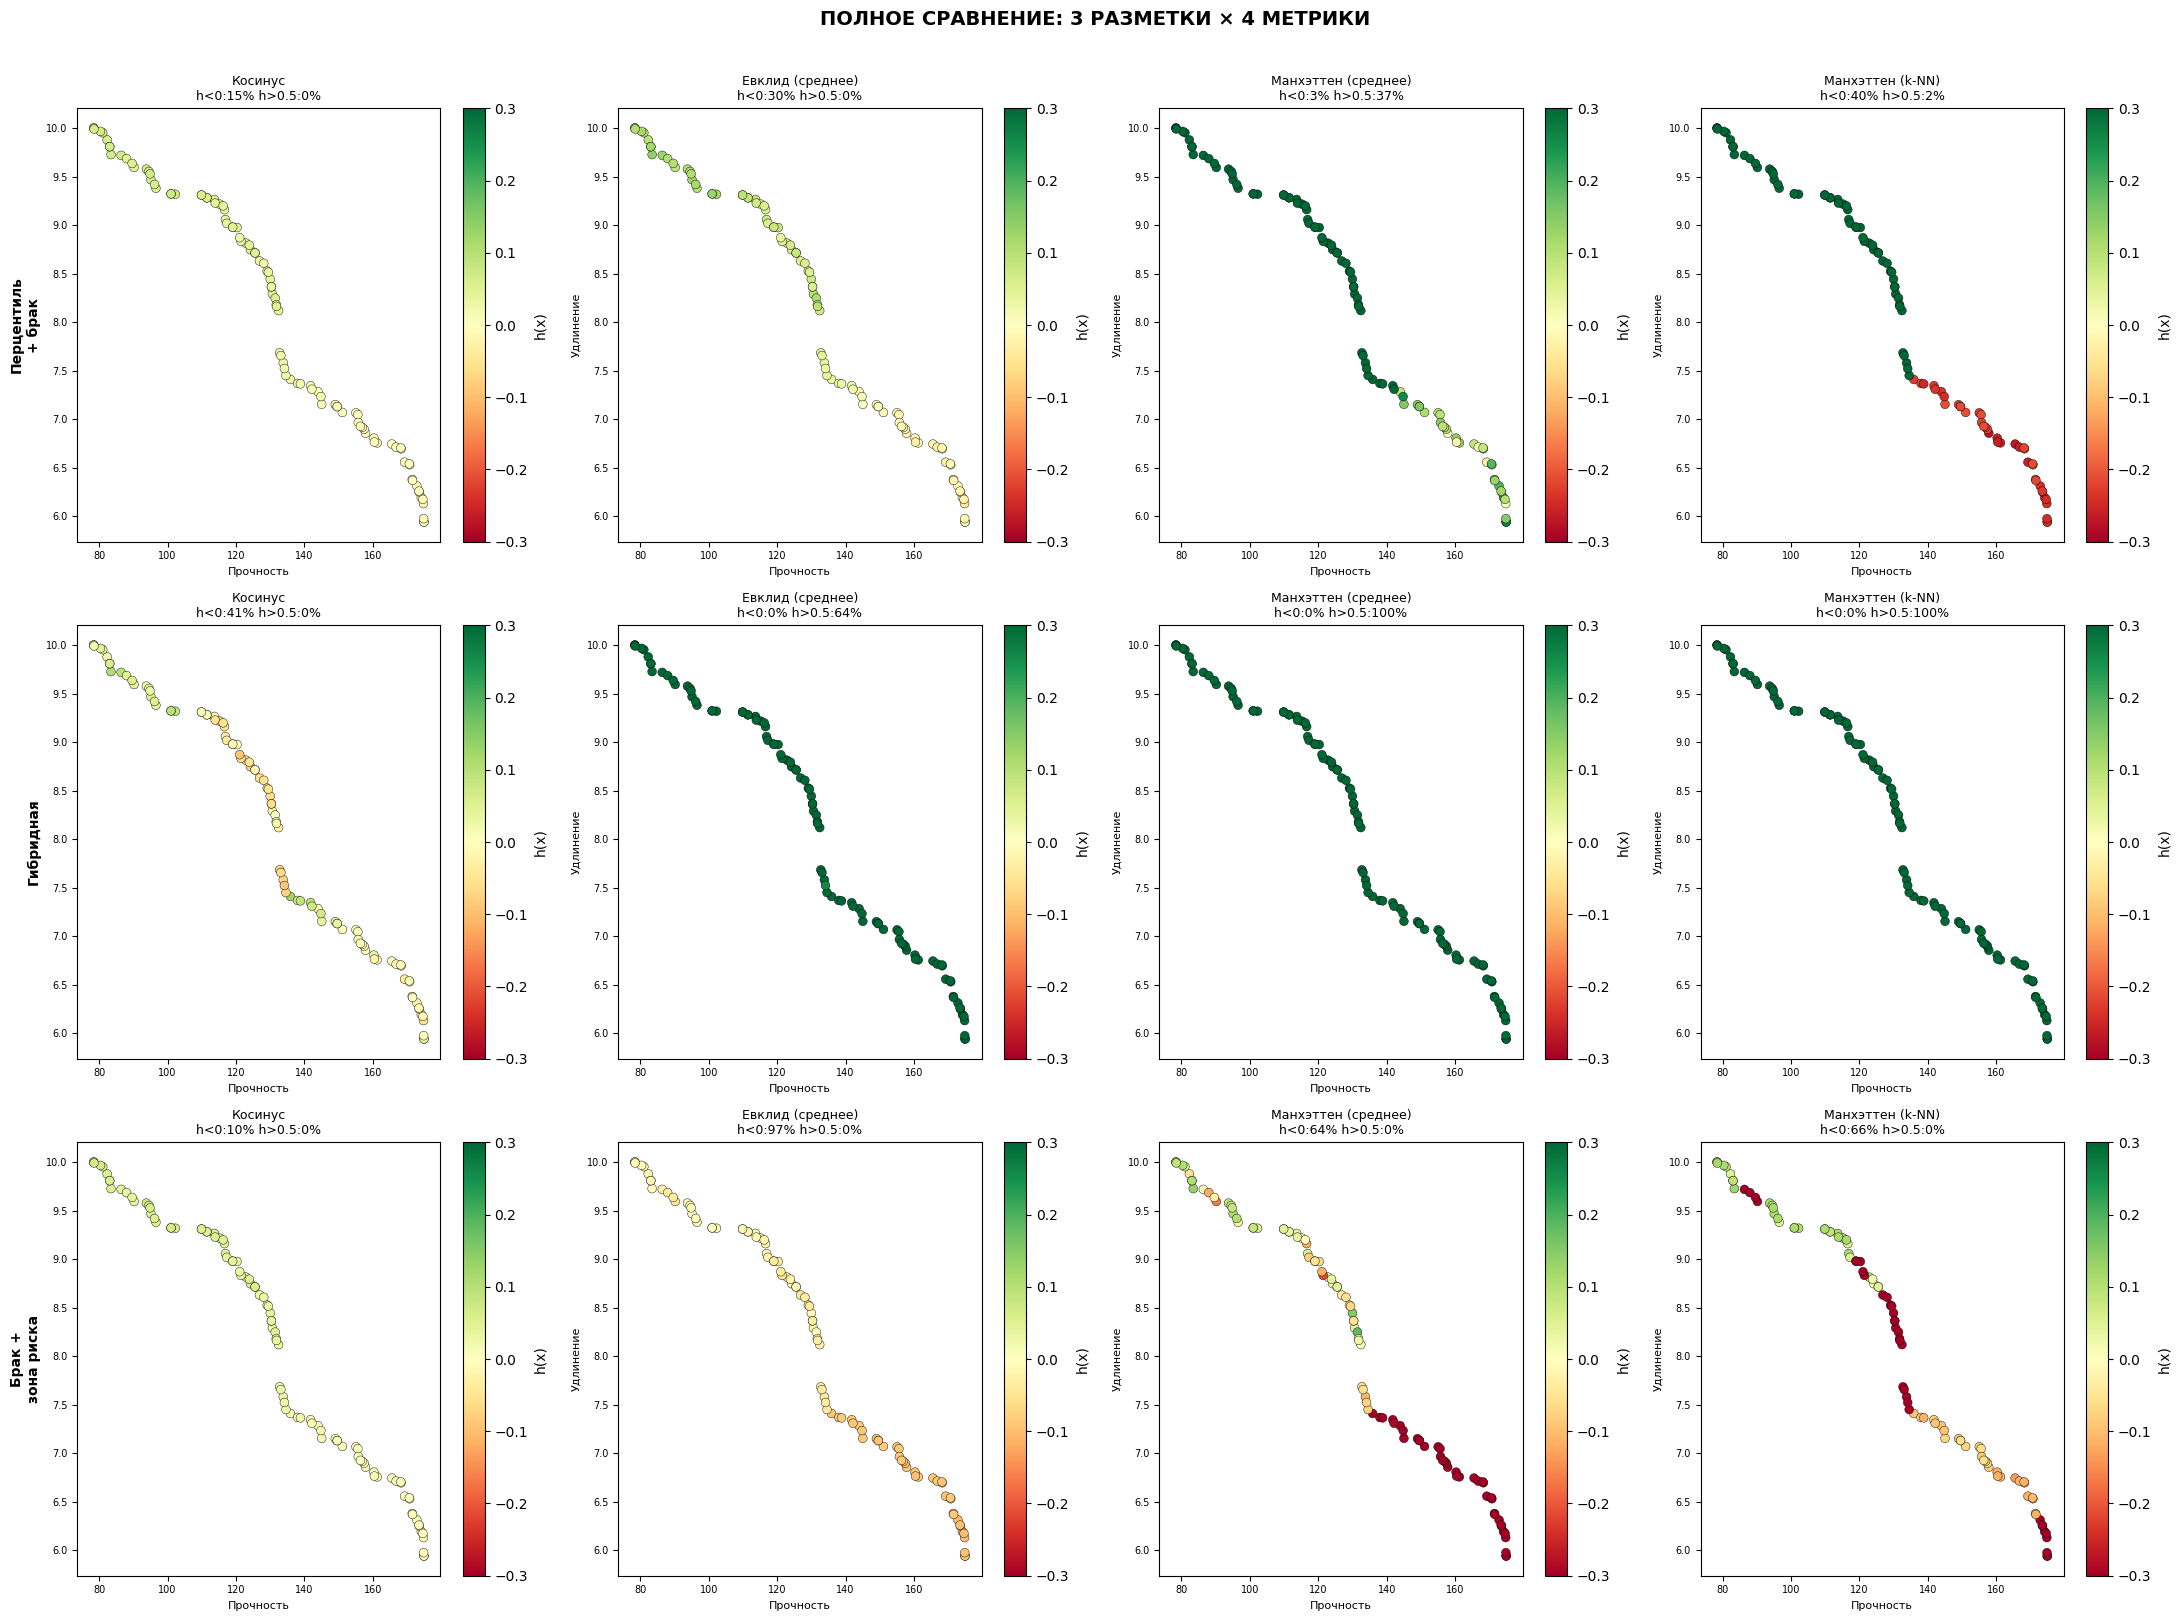

In [ ]:
# ============================================================
# 4.2. ПОЛНОЕ СРАВНЕНИЕ: 3 РАЗМЕТКИ × 4 МЕТРИКИ
# ============================================================
print("\n" + "="*70)
print("4.2. ПОЛНОЕ СРАВНЕНИЕ h(x)")
print("="*70)

from sklearn.metrics.pairwise import manhattan_distances, euclidean_distances

# Все конфигурации
all_configs = [
    ('Перцентиль + брак', D_good_1, D_bad_1),
    ('Гибридная', D_good_2, D_bad_2),
    ('Брак + зона риска', D_good_3, D_bad_3),
]

# Методы
methods = ['h_cosine', 'h_euclidean_mean', 'h_manhattan_mean', 'h_manhattan_knn']
method_names = ['Косинус', 'Евклид (среднее)', 'Манхэттен (среднее)', 'Манхэттен (k-NN)']

# Словарь для хранения всех результатов
all_results = {}

# ----------------------------------------------------------
# Вычисление для всех конфигураций
# ----------------------------------------------------------
for config_name, Dg, Db in all_configs:
    print(f"\n{'='*50}")
    print(f"Обработка: {config_name}")
    print(f"{'='*50}")

    # Нормализация
    Dg_norm = [normalize_dict(row.to_dict(), norm_config) for _, row in Dg.iterrows()]
    Db_norm = [normalize_dict(row.to_dict(), norm_config) for _, row in Db.iterrows()]

    Dg_vec = np.array([[d.get(p, 0.5) for p in all_param_names] for d in Dg_norm])
    Db_vec = np.array([[d.get(p, 0.5) for p in all_param_names] for d in Db_norm])

    # Вычисляем h(x) всеми методами
    N = len(pareto_vectors)
    results = {
        'h_cosine': np.zeros(N),
        'h_euclidean_mean': np.zeros(N),
        'h_manhattan_mean': np.zeros(N),
        'h_manhattan_knn': np.zeros(N),
    }

    k = 5
    for i in range(N):
        x = pareto_vectors[i]

        # Косинус
        sim_good = cosine_similarity(x.reshape(1, -1), Dg_vec).mean()
        sim_bad = cosine_similarity(x.reshape(1, -1), Db_vec).mean()
        results['h_cosine'][i] = np.tanh(sim_good - sim_bad)

        # Манхэттенские расстояния
        dist_good = np.sum(np.abs(Dg_vec - x), axis=1)
        dist_bad = np.sum(np.abs(Db_vec - x), axis=1)

        # Евклид (среднее)
        eucl_good = np.sqrt(np.sum((Dg_vec - x)**2, axis=1)).mean()
        eucl_bad = np.sqrt(np.sum((Db_vec - x)**2, axis=1)).mean()
        results['h_euclidean_mean'][i] = np.tanh(eucl_bad - eucl_good)

        # Манхэттен (среднее)
        results['h_manhattan_mean'][i] = np.tanh(dist_bad.mean() - dist_good.mean())

        # Манхэттен (k-NN)
        results['h_manhattan_knn'][i] = np.tanh(
            np.mean(np.sort(dist_bad)[:k]) - np.mean(np.sort(dist_good)[:k])
        )

    all_results[config_name] = results

    # Вывод по метрикам
    for method, name in zip(methods, method_names):
        h_vals = results[method]
        print(f"  {name:<20}: [{h_vals.min():.4f}, {h_vals.max():.4f}] μ={h_vals.mean():.4f} | h<0: {(h_vals<0).mean():.0%} | h>0.5: {(h_vals>0.5).mean():.0%}")

# ----------------------------------------------------------
# БОЛЬШАЯ СВОДНАЯ ТАБЛИЦА
# ----------------------------------------------------------
print("\n" + "="*100)
print("БОЛЬШАЯ СВОДНАЯ ТАБЛИЦА: 3 РАЗМЕТКИ × 4 МЕТРИКИ")
print("="*100)

print(f"\n{'Метод':<22} {'Разметка':<22} {'Диапазон':<28} {'Среднее':<10} {'h<0':<8} {'h>0.5':<8}")
print(f"{'-'*100}")

for method, mname in zip(methods, method_names):
    for config_name, _, _ in all_configs:
        h_vals = all_results[config_name][method]
        print(f"{mname:<22} {config_name:<22} [{h_vals.min():.4f}, {h_vals.max():.4f}]   {h_vals.mean():.4f}    {(h_vals<0).mean():.0%}       {(h_vals>0.5).mean():.0%}")
    print(f"{'-'*100}")

# ----------------------------------------------------------
# ВИЗУАЛИЗАЦИЯ: 3 разметки × 4 метрики = 12 графиков
# ----------------------------------------------------------
fig, axes = plt.subplots(3, 4, figsize=(22, 16))

for row, (config_name, _, _) in enumerate(all_configs):
    for col, (method, mname) in enumerate(zip(methods, method_names)):
        ax = axes[row, col]
        h_vals = all_results[config_name][method]

        sc = ax.scatter(pareto_df['strength'], pareto_df['elongation'],
                        c=h_vals, cmap='RdYlGn', s=40, edgecolors='black', linewidth=0.3,
                        vmin=-0.3, vmax=0.3)
        ax.set_xlabel('Прочность', fontsize=8)
        ax.set_ylabel('Удлинение', fontsize=8)
        ax.set_title(f'{mname}\nh<0:{(h_vals<0).mean():.0%} h>0.5:{(h_vals>0.5).mean():.0%}', fontsize=9)
        ax.tick_params(labelsize=7)
        plt.colorbar(sc, ax=ax, label='h(x)')

# Подписи строк
axes[0, 0].set_ylabel('Перцентиль\n+ брак', fontsize=10, fontweight='bold')
axes[1, 0].set_ylabel('Гибридная', fontsize=10, fontweight='bold')
axes[2, 0].set_ylabel('Брак +\nзона риска', fontsize=10, fontweight='bold')

plt.suptitle('ПОЛНОЕ СРАВНЕНИЕ: 3 РАЗМЕТКИ × 4 МЕТРИКИ', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('full_comparison_3x4.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ============================================================
# ФИНАЛЬНЫЙ ВЫБОР h(x)
# ============================================================
print("\n" + "="*70)
print("ФИНАЛЬНЫЙ ВЫБОР h(x)")
print("="*70)

# Выбираем вручную
final_config = 'Брак + зона риска'
final_method = 'h_manhattan_knn'
h_final = all_results[final_config][final_method]

print(f"""
ФИНАЛЬНАЯ КОНФИГУРАЦИЯ h(x):
   Разметка: {final_config}
   Метрика:  Манхэттенское расстояние, k-NN (k=5)

   Характеристики:
   • Диапазон: [{h_final.min():.4f}, {h_final.max():.4f}]
   • Среднее: {h_final.mean():.4f}
   • h < -0.1 (риск): {(h_final < -0.1).mean():.0%}
   • |h| < 0.1 (нейтр.): {((h_final > -0.1) & (h_final < 0.1)).mean():.0%}
   • h > 0.1 (надёжно): {(h_final > 0.1).mean():.0%}

   Для высокопрочных (S > 150 МПа):
   • Не красные (h > -0.1): {((h_final > -0.1) & (pareto_df['strength'].values > 150)).mean():.0%}

   Обоснование:
   1. Метод с разнообразием оценок
   2. Не удаляет все точки с высокой прочностью
   3. Основан на реальных данных о браке
   4. Интерпретируем для технолога
""")

# Сохраняем как основную h(x)
pareto_df['h'] = h_final
h_values = h_final

print("h(x) сохранён в pareto_df['h'].")


ФИНАЛЬНЫЙ ВЫБОР h(x)

ФИНАЛЬНАЯ КОНФИГУРАЦИЯ h(x):
   Разметка: Брак + зона риска
   Метрика:  Манхэттенское расстояние, k-NN (k=5)

   Характеристики:
   • Диапазон: [-0.4449, 0.1265]
   • Среднее: -0.1345
   • h < -0.1 (риск): 48%
   • |h| < 0.1 (нейтр.): 31%
   • h > 0.1 (надёжно): 21%

   Для высокопрочных (S > 150 МПа):
   • Не красные (h > -0.1): 8%

   Обоснование:
   1. Метод с разнообразием оценок
   2. Не удаляет все точки с высокой прочностью
   3. Основан на реальных данных о браке
   4. Интерпретируем для технолога

h(x) сохранён в pareto_df['h'].


## 4.3. Функция мягких штрафов P(x)

In [ ]:
# ============================================================
# 4.3. ФУНКЦИЯ МЯГКИХ ШТРАФОВ P(x)
# ============================================================
print("\n" + "=" * 70)
print("4.3. Функция мягких штрафов P(x)")
print("=" * 70)

# ----------------------------------------------------------
# Функция извлечения предпочтений через БЯМ
# ----------------------------------------------------------
def extract_preferences_from_text(technologist_text, verbose=True):
    """
    Отправляет текст технолога в LLM и получает структурированные предпочтения.
    """
    if verbose:
        print(f"\n📝 Текст: {technologist_text}")

    # PREFERENCE_EXTRACTION_PROMPT уже определён в блоке 3
    full_prompt = PREFERENCE_EXTRACTION_PROMPT + f"\n\nТекст технолога:\n{technologist_text}"
    llm_response = get_llm_response(full_prompt, max_tokens=1024, system_role="preferences")

    if verbose:
        print(f"🤖 Ответ: {llm_response[:300]}")

    try:
        json_match = re.search(r'\{.*\}', llm_response, re.DOTALL)
        parsed = json.loads(json_match.group() if json_match else llm_response)

        w1 = float(parsed.get('w1', 0.5))
        w2 = float(parsed.get('w2', 0.5))
        total = w1 + w2
        if total > 0:
            w1, w2 = w1 / total, w2 / total

        raw_prefs = parsed.get('preferences', [])
        preferences = []
        valid_params = set(TECH_PARAMS)  # из блока 3

        for pref in raw_prefs:
            param = pref.get('param', '')
            direction = pref.get('direction', '')
            if param in valid_params and direction in ('minimize', 'maximize'):
                preferences.append((param, direction))
            elif param not in valid_params and verbose:
                print(f"   ⚠️ Пропущен параметр '{param}' — нет в списке доступных")

        if verbose:
            print(f"   Веса: w1={w1:.2f} (прочность), w2={w2:.2f} (удлинение)")
            print(f"   Предпочтений: {len(preferences)}")
            for p, d in preferences:
                print(f"     • {p} → {d}")

        return w1, w2, preferences

    except json.JSONDecodeError as e:
        print(f"   ❌ Ошибка парсинга JSON: {e}")
        return 0.5, 0.5, []


# ----------------------------------------------------------
# Функция вычисления P(x)
# ----------------------------------------------------------
def compute_soft_penalties(pareto_norm, preferences, gamma=0.15):
    """
    Вычисляет мягкие штрафы P(x) на основе предпочтений.

    Параметры:
        pareto_norm: список словарей нормализованных параметров
        preferences: список кортежей (имя_параметра, направление)
        gamma: вес одного предпочтения (по умолчанию 0.15)

    Возвращает:
        penalties: массив размера N со значениями >= 0
        details: словарь с детализацией по каждому предпочтению
    """
    N = len(pareto_norm)
    penalties = np.zeros(N)
    details = {}

    for param_name, direction in preferences:
        if param_name not in all_param_names:
            continue

        values = np.array([d.get(param_name, 0.5) for d in pareto_norm])

        if direction == 'minimize':
            p = values  # штраф за высокие значения (value близко к 1)
        elif direction == 'maximize':
            p = 1 - values  # штраф за низкие значения (value близко к 0)
        else:
            continue

        penalties += gamma * p
        details[param_name] = {
            'direction': direction,
            'individual_penalty': p,
            'weight': gamma,
            'min': p.min(),
            'max': p.max(),
            'mean': p.mean()
        }

    return penalties, details


4.3. Функция мягких штрафов P(x)


In [ ]:
# ============================================================
# ИЗВЛЕЧЕНИЕ ПРЕДПОЧТЕНИЙ ДЛЯ АКТИВНЫХ СЦЕНАРИЕВ
# ============================================================
print("\n" + "=" * 70)
print("ИЗВЛЕЧЕНИЕ ПРЕДПОЧТЕНИЙ ЧЕРЕЗ БЯМ")
print("=" * 70)

all_scenarios = {}

for idx, sid in enumerate(active_scenario_ids):
    prompt_text = ALL_PROMPTS[sid-1]

    print(f"\n{'─'*50}")
    print(f"СЦЕНАРИЙ {sid}: {SCENARIO_NAMES[sid-1]}")
    print(f"{'─'*50}")

    w1, w2, prefs = extract_preferences_from_text(prompt_text, verbose=True)

    all_scenarios[sid] = {
        'name': SCENARIO_NAMES[sid-1],
        'prompt': prompt_text,
        'w1': w1,
        'w2': w2,
        'prefs': prefs,
    }

    # Небольшая пауза между запросами
    if idx < len(active_scenario_ids) - 1:
        time.sleep(0.5)

# ============================================================
# ВЫЧИСЛЕНИЕ P(x) ДЛЯ СЦЕНАРИЕВ
# ============================================================
print("\n" + "=" * 70)
print("ВЫЧИСЛЕНИЕ P(x) ДЛЯ СЦЕНАРИЕВ")
print("=" * 70)

for sid in active_scenario_ids:
    s = all_scenarios[sid]
    P_vals, P_details = compute_soft_penalties(pareto_norm, s['prefs'], gamma=0.15)
    pareto_df[f'P_scenario_{sid}'] = P_vals
    all_scenarios[sid]['P_values'] = P_vals
    all_scenarios[sid]['P_details'] = P_details

    print(f"\n   Сценарий {sid} ({s['name']}): {len(s['prefs'])} предпочтений")
    print(f"   P(x): [{P_vals.min():.4f}, {P_vals.max():.4f}] μ={P_vals.mean():.4f}")

# ============================================================
# СВОДНАЯ ТАБЛИЦА
# ============================================================
print("\n" + "=" * 70)
print("СВОДНАЯ ТАБЛИЦА СЦЕНАРИЕВ")
print("=" * 70)

print(f"\n{'#':<3} {'Название':<30} {'w1':<8} {'w2':<8} {'P min':<10} {'P max':<10} {'P mean':<10} {'Предпочтения'}")
print(f"{'-'*100}")
for i, s in all_scenarios.items():
    P = s['P_values']
    prefs_str = ', '.join([f"{p}↓" if d == 'minimize' else f"{p}↑" for p, d in s['prefs']]) if s['prefs'] else '—'
    print(f"{i:<3} {s['prompt'][:30]:<30} {s['w1']:<8.2f} {s['w2']:<8.2f} {P.min():<10.4f} {P.max():<10.4f} {P.mean():<10.4f} {prefs_str}")


ИЗВЛЕЧЕНИЕ ПРЕДПОЧТЕНИЙ ЧЕРЕЗ БЯМ

──────────────────────────────────────────────────
СЦЕНАРИЙ 5: Запах растворителей
──────────────────────────────────────────────────

📝 Текст: У нас жалобы персонала на запах растворителей. Нужно найти рецептуру с минимальным использованием летучих компонентов (Смесь растворителей, Сантисайзер). При этом прочность должна быть высокой (>150 МПа), а удлинение — не критично, но хотя бы 5.5%. Температура в цехе сейчас около 25°C.
🤖 Ответ: ```json
{"w1": 0.8, "w2": 0.2, "preferences": [{"param": "ТЭА", "direction": "minimize"}, {"param": "ЭГ", "direction": "minimize"}, {"param": "Гл", "direction": "minimize"}, {"param": "Смесь растворителей", "direction": "minimize"}, {"param": "Сантисайзер", "direction": "minimize"}]}
```
   Веса: w1=0.80 (прочность), w2=0.20 (удлинение)
   Предпочтений: 5
     • ТЭА → minimize
     • ЭГ → minimize
     • Гл → minimize
     • Смесь растворителей → minimize
     • Сантисайзер → minimize

ВЫЧИСЛЕНИЕ P(x) ДЛЯ СЦЕНАРИЕВ

  


ВИЗУАЛИЗАЦИЯ P(x) ДЛЯ СЦЕНАРИЕВ


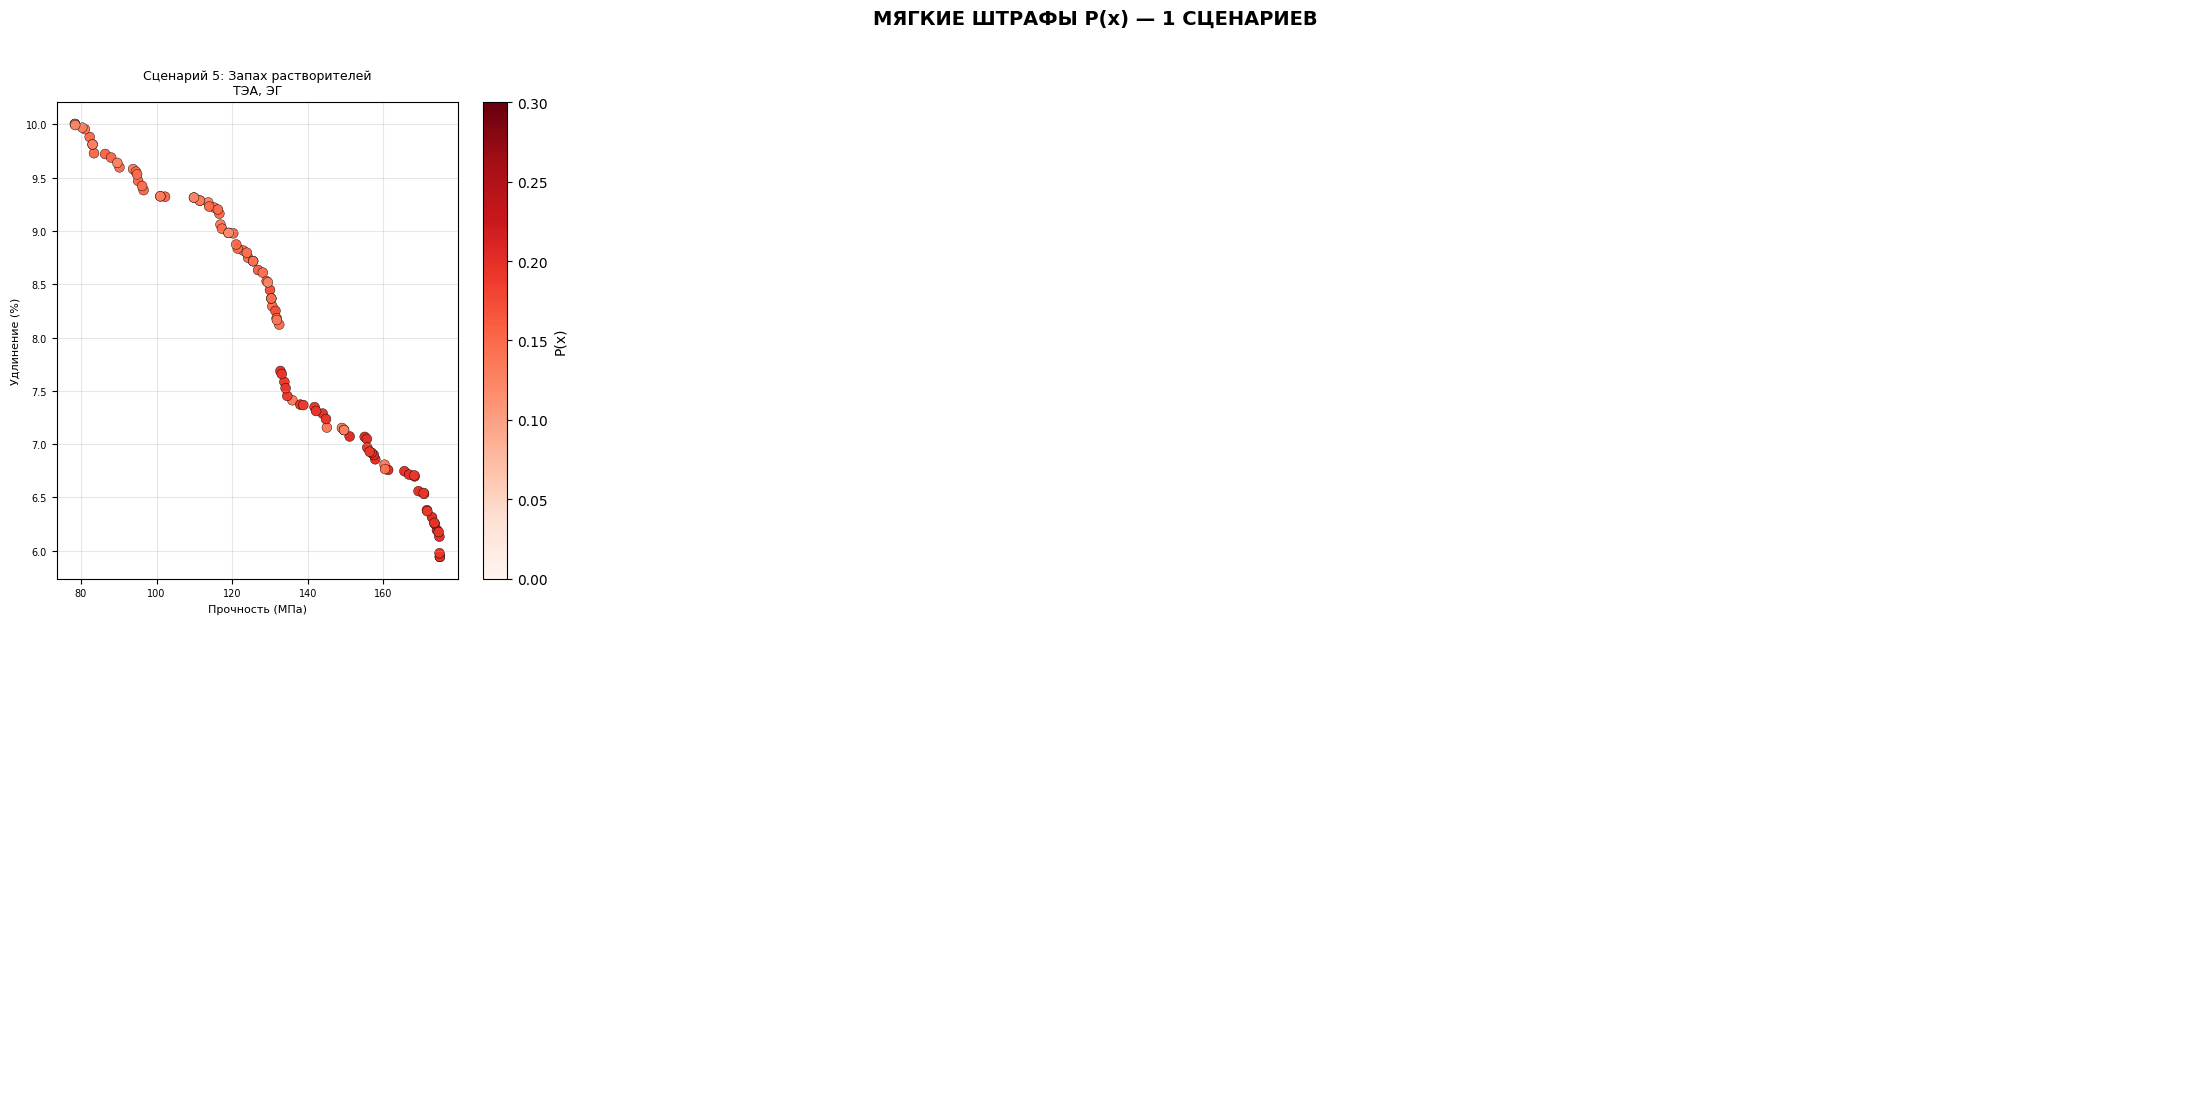


Результаты:
  • Извлечено сценариев: 1
  • P(x) вычислен для каждого сценария
  • P(x) сохранён в pareto_df['P_scenario_5']



In [ ]:
# ============================================================
# ВИЗУАЛИЗАЦИЯ
# ============================================================
print("\n" + "=" * 70)
print("ВИЗУАЛИЗАЦИЯ P(x) ДЛЯ СЦЕНАРИЕВ")
print("=" * 70)

fig, axes = plt.subplots(2, 4, figsize=(22, 11))
axes_flat = axes.flatten()

# Выводим только активные сценарии в первые ячейки
for idx, sid in enumerate(active_scenario_ids):
    ax = axes_flat[idx]

    s = all_scenarios[sid]
    P_vals = s['P_values']

    sc = ax.scatter(pareto_df['strength'], pareto_df['elongation'],
                    c=P_vals, cmap='Reds', s=50, edgecolors='black', linewidth=0.3,
                    vmin=0, vmax=max(0.3, P_vals.max()))
    ax.set_xlabel('Прочность (МПа)', fontsize=8)
    ax.set_ylabel('Удлинение (%)', fontsize=8)

    title = f'Сценарий {sid}: {s["name"]}'
    if s['prefs']:
        prefs_short = ', '.join([p for p, _ in s['prefs'][:2]])
        title += f'\n{prefs_short}'
    ax.set_title(title, fontsize=9)
    ax.tick_params(labelsize=7)
    ax.grid(True, alpha=0.3)
    plt.colorbar(sc, ax=ax, label='P(x)')

# Скрываем неиспользуемые subplots
for idx in range(len(active_scenario_ids), 8):
    axes_flat[idx].axis('off')

plt.suptitle(f'МЯГКИЕ ШТРАФЫ P(x) — {len(active_scenario_ids)} СЦЕНАРИЕВ',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('P_selected_scenarios.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================================
# ИТОГИ
# ============================================================

print(f"""
Результаты:
  • Извлечено сценариев: {len(all_scenarios)}
  • P(x) вычислен для каждого сценария
  • P(x) сохранён в pareto_df['P_scenario_{i}']
""")

## 4.4. Нормализация компонент


4.4. Нормализация компонент

ДЕМОНСТРАЦИЯ НОРМАЛИЗАЦИИ (СЦЕНАРИЙ 5)

   Сценарий: Запах растворителей
   Компонента           Исходный диапазон              После нормализации       
   ---------------------------------------------------------------------------
   Гиперобъём           [20.58, 156.50]                 μ=0, σ=1
   Эвристика h(x)       [-0.445, 0.126]                  μ=0, σ=1
   Штрафы P(x)          [0.120, 0.204]                  μ=0, σ=1


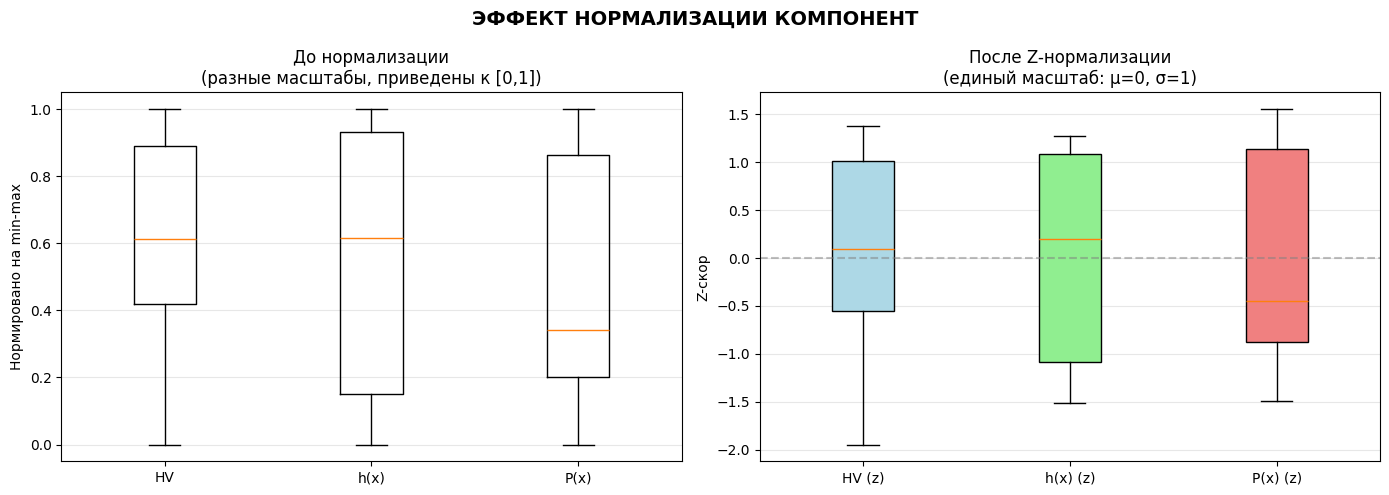


НОРМАЛИЗАЦИЯ ДЛЯ ВСЕХ АКТИВНЫХ СЦЕНАРИЕВ

   Сценарий: Запах растворителей
   Компонента           Исходный диапазон              После нормализации       
   ---------------------------------------------------------------------------
   Гиперобъём           [20.58, 156.50]                 μ=0, σ=1
   Эвристика h(x)       [-0.445, 0.126]                  μ=0, σ=1
   Штрафы P(x)          [0.120, 0.204]                  μ=0, σ=1

Сцен.  Название                  HV range                  h range                   P range                  
---------------------------------------------------------------------------------------------------------
5      Запах растворителей       [-1.95, 1.38]             [-1.51, 1.27]             [-1.49, 1.55]            

Результаты:
  • Z-нормализация применена ко всем активным сценариям
  • Все компоненты приведены к μ=0, σ=1
  • HV, h(x), P(x) теперь в едином масштабе



In [ ]:
# ============================================================
# 4.4. НОРМАЛИЗАЦИЯ КОМПОНЕНТ
# ============================================================
print("\n" + "=" * 70)
print("4.4. Нормализация компонент")
print("=" * 70)

def z_normalize(values):
    """Z-нормализация: (x - mean) / std."""
    mu = np.mean(values)
    sigma = np.std(values)
    if sigma < 1e-10:
        return np.zeros_like(values), mu, sigma
    return (values - mu) / sigma, mu, sigma


def normalize_components(hv_values, h_values, p_values, scenario_name=""):
    """
    Нормализует три компоненты к единой шкале (z-скор).

    Параметры:
        hv_values: массив гиперобъёмов
        h_values: массив эвристик
        p_values: массив штрафов (для конкретного сценария)
        scenario_name: название сценария (для вывода)

    Возвращает:
        hv_norm, h_norm, p_norm: нормализованные массивы
        stats: словарь со статистиками (mu, sigma)
    """
    hv_norm, mu_hv, sigma_hv = z_normalize(hv_values)
    h_norm, mu_h, sigma_h = z_normalize(h_values)
    p_norm, mu_p, sigma_p = z_normalize(p_values)

    stats = {
        'HV': {'mu': mu_hv, 'sigma': sigma_hv},
        'h':  {'mu': mu_h,  'sigma': sigma_h},
        'P':  {'mu': mu_p,  'sigma': sigma_p}
    }

    if scenario_name:
        print(f"\n   Сценарий: {scenario_name}")
    print(f"   {'Компонента':<20} {'Исходный диапазон':<30} {'После нормализации':<25}")
    print(f"   {'-'*75}")
    print(f"   {'Гиперобъём':<20} [{hv_values.min():.2f}, {hv_values.max():.2f}]{'':>16} μ=0, σ=1")
    print(f"   {'Эвристика h(x)':<20} [{h_values.min():.3f}, {h_values.max():.3f}]{'':>17} μ=0, σ=1")
    print(f"   {'Штрафы P(x)':<20} [{p_values.min():.3f}, {p_values.max():.3f}]{'':>17} μ=0, σ=1")

    return hv_norm, h_norm, p_norm, stats


# ============================================================
# ДЕМОНСТРАЦИЯ НА ПЕРВОМ АКТИВНОМ СЦЕНАРИИ
# ============================================================
print("\n" + "=" * 70)
print(f"ДЕМОНСТРАЦИЯ НОРМАЛИЗАЦИИ (СЦЕНАРИЙ {active_scenario_ids[0]})")
print("=" * 70)

# Берём P(x) для первого активного сценария
first_sid = active_scenario_ids[0]
P_demo = pareto_df[f'P_scenario_{first_sid}'].values

hv_norm, h_norm, p_norm, norm_stats = normalize_components(
    hv_values, h_values, P_demo,
    scenario_name=all_scenarios[first_sid]['name']
)

# ============================================================
# ВИЗУАЛИЗАЦИЯ ДО И ПОСЛЕ НОРМАЛИЗАЦИИ
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ДО нормализации (приводим к [0,1] для визуализации)
ax = axes[0]
hv_scaled = (hv_values - hv_values.min()) / (hv_values.max() - hv_values.min() + 1e-10)
h_scaled = (h_values - h_values.min()) / (h_values.max() - h_values.min() + 1e-10)
p_scaled = (P_demo - P_demo.min()) / (P_demo.max() - P_demo.min() + 1e-10)

ax.boxplot([hv_scaled, h_scaled, p_scaled],
           labels=['HV', 'h(x)', 'P(x)'])
ax.set_title('До нормализации\n(разные масштабы, приведены к [0,1])')
ax.set_ylabel('Нормировано на min-max')
ax.grid(True, alpha=0.3, axis='y')

# ПОСЛЕ нормализации
ax = axes[1]
bp = ax.boxplot([hv_norm, h_norm, p_norm],
                labels=['HV (z)', 'h(x) (z)', 'P(x) (z)'],
                patch_artist=True)
colors = ['lightblue', 'lightgreen', 'lightcoral']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)

ax.set_title('После Z-нормализации\n(единый масштаб: μ=0, σ=1)')
ax.set_ylabel('Z-скор')
ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('ЭФФЕКТ НОРМАЛИЗАЦИИ КОМПОНЕНТ', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('normalization_effect.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================================
# НОРМАЛИЗАЦИЯ ДЛЯ ВСЕХ АКТИВНЫХ СЦЕНАРИЕВ
# ============================================================
print("\n" + "=" * 70)
print("НОРМАЛИЗАЦИЯ ДЛЯ ВСЕХ АКТИВНЫХ СЦЕНАРИЕВ")
print("=" * 70)

all_normalized = {}

for sid in active_scenario_ids:
    P_i = pareto_df[f'P_scenario_{sid}'].values
    hv_n, h_n, p_n, stats = normalize_components(hv_values, h_values, P_i,
                                                  scenario_name=all_scenarios[sid]['name'])
    all_normalized[sid] = {
        'hv_norm': hv_n,
        'h_norm': h_n,
        'p_norm': p_n,
        'stats': stats
    }

# Сводная таблица
print(f"\n{'Сцен.':<6} {'Название':<25} {'HV range':<25} {'h range':<25} {'P range':<25}")
print(f"{'-'*105}")
for sid in active_scenario_ids:
    name = all_scenarios[sid]['name'][:24]
    hv_r = f"[{all_normalized[sid]['hv_norm'].min():.2f}, {all_normalized[sid]['hv_norm'].max():.2f}]"
    h_r = f"[{all_normalized[sid]['h_norm'].min():.2f}, {all_normalized[sid]['h_norm'].max():.2f}]"
    p_r = f"[{all_normalized[sid]['p_norm'].min():.2f}, {all_normalized[sid]['p_norm'].max():.2f}]"
    print(f"{sid:<6} {name:<25} {hv_r:<25} {h_r:<25} {p_r:<25}")

print(f"""
Результаты:
  • Z-нормализация применена ко всем активным сценариям
  • Все компоненты приведены к μ=0, σ=1
  • HV, h(x), P(x) теперь в едином масштабе
""")

# 5. ФИНАЛЬНЫЙ СЛОВАРЬ ТЕСТОВЫХ СЦЕНАРИЕВ

In [ ]:
# ============================================================
# 5. ФОРМИРОВАНИЕ SCENARIOS ДЛЯ ДАЛЬНЕЙШЕГО АНАЛИЗА
# ============================================================
print("\n" + "=" * 70)
print("5. Финальный словарь SCENARIOS")
print("=" * 70)

SCENARIOS = {}

for sid in active_scenario_ids:
    s = all_scenarios[sid]
    SCENARIOS[sid] = {
        'name': s['name'],
        'prompt': s['prompt'],
        'w1': s['w1'],
        'w2': s['w2'],
        'prefs': s['prefs'],
        'P_values': pareto_df[f'P_scenario_{sid}'].values,
        'norm': all_normalized[sid],
    }

# ИТОГОВАЯ ТАБЛИЦА
print(f"\n{'='*80}")
print(f"ИТОГО: АКТИВНЫХ СЦЕНАРИЕВ — {len(SCENARIOS)}")
print(f"{'='*80}")
print(f"\n{'#':<3} {'Сценарий':<30} {'w1':<8} {'w2':<8} {'P min':<10} {'P max':<10} {'P mean':<10} {'Предпочтения'}")
print(f"{'-'*105}")
for sid, s in SCENARIOS.items():
    P = s['P_values']
    prefs_str = ', '.join([f"{p}↓" if d == 'minimize' else f"{p}↑" for p, d in s['prefs']]) if s['prefs'] else '—'
    print(f"{sid:<3} {s['name']:<30} {s['w1']:<8.2f} {s['w2']:<8.2f} {P.min():<10.4f} {P.max():<10.4f} {P.mean():<10.4f} {prefs_str}")


5. Финальный словарь SCENARIOS

ИТОГО: АКТИВНЫХ СЦЕНАРИЕВ — 1

#   Сценарий                       w1       w2       P min      P max      P mean     Предпочтения
---------------------------------------------------------------------------------------------------------
5   Запах растворителей            0.80     0.20     0.1201     0.2044     0.1613     ТЭА↓, ЭГ↓, Гл↓, Смесь растворителей↓, Сантисайзер↓


# 6. РЕАЛИЗАЦИЯ МЕТОДОВ РАНЖИРОВАНИЯ

   6.1. HV-only
   
   6.2. h-only

   6.3. TOPSIS

   6.4. VIKOR

   6.5. PROMETHEE II

   6.6. Гибридный

   6.7. Гибридный + LISTEN

## 6.1. HV-only


6.1. HV-only
Топ-10 по HV:
  1. Точка 63: S=128 МПа, E=8.61%, HV=156.5
  2. Точка 90: S=129 МПа, E=8.52%, HV=155.2
  3. Точка 70: S=129 МПа, E=8.53%, HV=154.9
  4. Точка 87: S=126 МПа, E=8.72%, HV=154.7
  5. Точка 51: S=126 МПа, E=8.72%, HV=154.7
  6. Точка 19: S=127 МПа, E=8.63%, HV=154.2
  7. Точка 60: S=124 МПа, E=8.80%, HV=153.8
  8. Точка 30: S=130 МПа, E=8.45%, HV=152.7
  9. Точка 46: S=124 МПа, E=8.75%, HV=152.4
  10. Точка 50: S=123 МПа, E=8.82%, HV=151.8


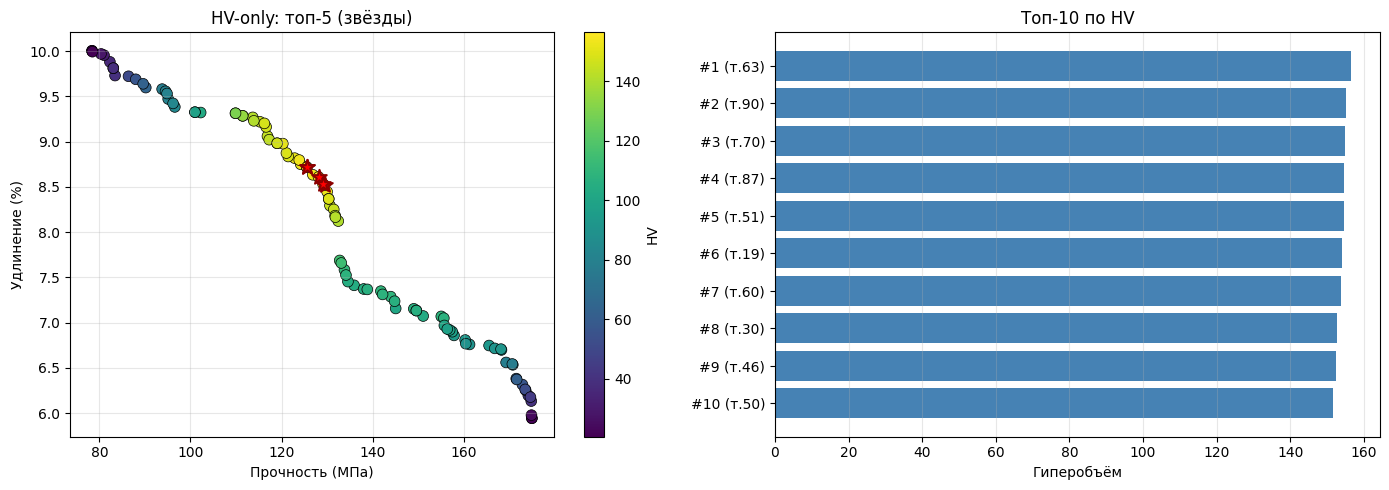

In [ ]:
# ============================================================
# 6.1. HV-only — ранжирование только по гиперобъёму
# ============================================================
print("\n" + "=" * 70)
print("6.1. HV-only")
print("=" * 70)

# Инициализация словаря для всех ранжирований
rankings = {}

# HV-only не зависит от сценария — одно ранжирование для всех
hv_ranking = np.argsort(hv_values)[::-1]  # от большего к меньшему

rankings['HV-only'] = {}
for scenario_id in active_scenario_ids:
    rankings['HV-only'][scenario_id] = hv_ranking.copy()

print(f"Топ-10 по HV:")
for i, idx in enumerate(hv_ranking[:10]):
    row = pareto_df.iloc[idx]
    print(f"  {i+1}. Точка {idx}: S={row['strength']:.0f} МПа, E={row['elongation']:.2f}%, HV={hv_values[idx]:.1f}")

# Визуализация
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
sc = ax.scatter(pareto_df['strength'], pareto_df['elongation'],
                c=hv_values, cmap='viridis', s=60, edgecolors='black', linewidth=0.5)
# Выделяем топ-5
top5 = hv_ranking[:5]
ax.scatter(pareto_df.iloc[top5]['strength'], pareto_df.iloc[top5]['elongation'],
           c='red', s=120, marker='*', edgecolors='darkred', linewidth=1.5, zorder=10)
ax.set_xlabel('Прочность (МПа)')
ax.set_ylabel('Удлинение (%)')
ax.set_title('HV-only: топ-5 (звёзды)')
plt.colorbar(sc, ax=ax, label='HV')
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.barh(range(10), hv_values[hv_ranking[:10]], color='steelblue')
ax.set_yticks(range(10))
ax.set_yticklabels([f'#{i+1} (т.{idx})' for i, idx in enumerate(hv_ranking[:10])])
ax.set_xlabel('Гиперобъём')
ax.set_title('Топ-10 по HV')
ax.invert_yaxis()
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('HV_only.png', dpi=150, bbox_inches='tight')
plt.show()

## 6.2. h-only


6.2. h-only
Топ-10 по h(x):
  1. Точка 16: S=83 МПа, E=9.73%, h=0.1265
  2. Точка 3: S=78 МПа, E=10.00%, h=0.1171
  3. Точка 65: S=114 МПа, E=9.23%, h=0.1170
  4. Точка 67: S=83 МПа, E=9.81%, h=0.1166
  5. Точка 97: S=95 МПа, E=9.53%, h=0.1165
  6. Точка 64: S=78 МПа, E=9.99%, h=0.1156
  7. Точка 74: S=96 МПа, E=9.42%, h=0.1153
  8. Точка 57: S=115 МПа, E=9.22%, h=0.1150
  9. Точка 35: S=117 МПа, E=9.06%, h=0.1149
  10. Точка 66: S=116 МПа, E=9.20%, h=0.1149

Худшие-10 по h(x):
  1. Точка 33: S=134 МПа, E=7.58%, h=-0.4449
  2. Точка 90: S=129 МПа, E=8.52%, h=-0.4433
  3. Точка 85: S=132 МПа, E=8.17%, h=-0.4411
  4. Точка 19: S=127 МПа, E=8.63%, h=-0.4407
  5. Точка 71: S=132 МПа, E=8.18%, h=-0.4372
  6. Точка 31: S=135 МПа, E=7.45%, h=-0.4349
  7. Точка 5: S=133 МПа, E=7.69%, h=-0.4338
  8. Точка 63: S=128 МПа, E=8.61%, h=-0.4338
  9. Точка 47: S=133 МПа, E=7.66%, h=-0.4335
  10. Точка 39: S=134 МПа, E=7.53%, h=-0.4335


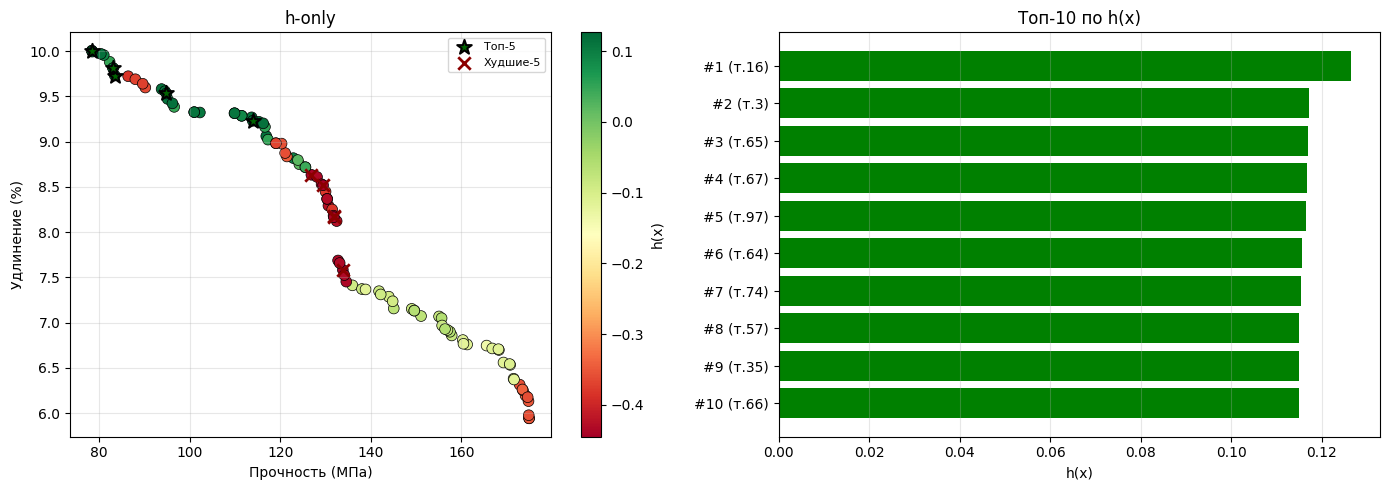

In [ ]:
# ============================================================
# 6.2. h-only — ранжирование только по эвристике
# ============================================================
print("\n" + "=" * 70)
print("6.2. h-only")
print("=" * 70)

# h-only не зависит от сценария
h_ranking = np.argsort(h_values)[::-1]  # от большего к меньшему

rankings['h-only'] = {}
for scenario_id in active_scenario_ids:
    rankings['h-only'][scenario_id] = h_ranking.copy()

print(f"Топ-10 по h(x):")
for i, idx in enumerate(h_ranking[:10]):
    row = pareto_df.iloc[idx]
    print(f"  {i+1}. Точка {idx}: S={row['strength']:.0f} МПа, E={row['elongation']:.2f}%, h={h_values[idx]:.4f}")

print(f"\nХудшие-10 по h(x):")
for i, idx in enumerate(h_ranking[-10:][::-1]):
    row = pareto_df.iloc[idx]
    print(f"  {i+1}. Точка {idx}: S={row['strength']:.0f} МПа, E={row['elongation']:.2f}%, h={h_values[idx]:.4f}")

# Визуализация
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
sc = ax.scatter(pareto_df['strength'], pareto_df['elongation'],
                c=h_values, cmap='RdYlGn', s=60, edgecolors='black', linewidth=0.5)
# Выделяем топ-5
top5 = h_ranking[:5]
worst5 = h_ranking[-5:]
ax.scatter(pareto_df.iloc[top5]['strength'], pareto_df.iloc[top5]['elongation'],
           c='darkgreen', s=120, marker='*', edgecolors='black', linewidth=1.5, zorder=10, label='Топ-5')
ax.scatter(pareto_df.iloc[worst5]['strength'], pareto_df.iloc[worst5]['elongation'],
           c='darkred', s=80, marker='x', linewidth=2, zorder=10, label='Худшие-5')
ax.set_xlabel('Прочность (МПа)')
ax.set_ylabel('Удлинение (%)')
ax.set_title('h-only')
ax.legend(fontsize=8)
plt.colorbar(sc, ax=ax, label='h(x)')
ax.grid(True, alpha=0.3)

ax = axes[1]
colors = ['green' if h_values[idx] > 0 else 'red' for idx in h_ranking[:10]]
ax.barh(range(10), h_values[h_ranking[:10]], color=colors)
ax.set_yticks(range(10))
ax.set_yticklabels([f'#{i+1} (т.{idx})' for i, idx in enumerate(h_ranking[:10])])
ax.set_xlabel('h(x)')
ax.set_title('Топ-10 по h(x)')
ax.axvline(0, color='black', linestyle='-', linewidth=0.5)
ax.invert_yaxis()
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('h_only.png', dpi=150, bbox_inches='tight')
plt.show()

## 6.3. TOPSIS


6.3. TOPSIS

Сценарий 5 (Запах растворителей):
  Веса: HV=0.67, h=0.17, P=0.17
  1. Точка 87: S=126, E=8.72, HV=154.7, h=0.044
  2. Точка 50: S=123, E=8.82, HV=151.8, h=0.093
  3. Точка 51: S=126, E=8.72, HV=154.7, h=0.044


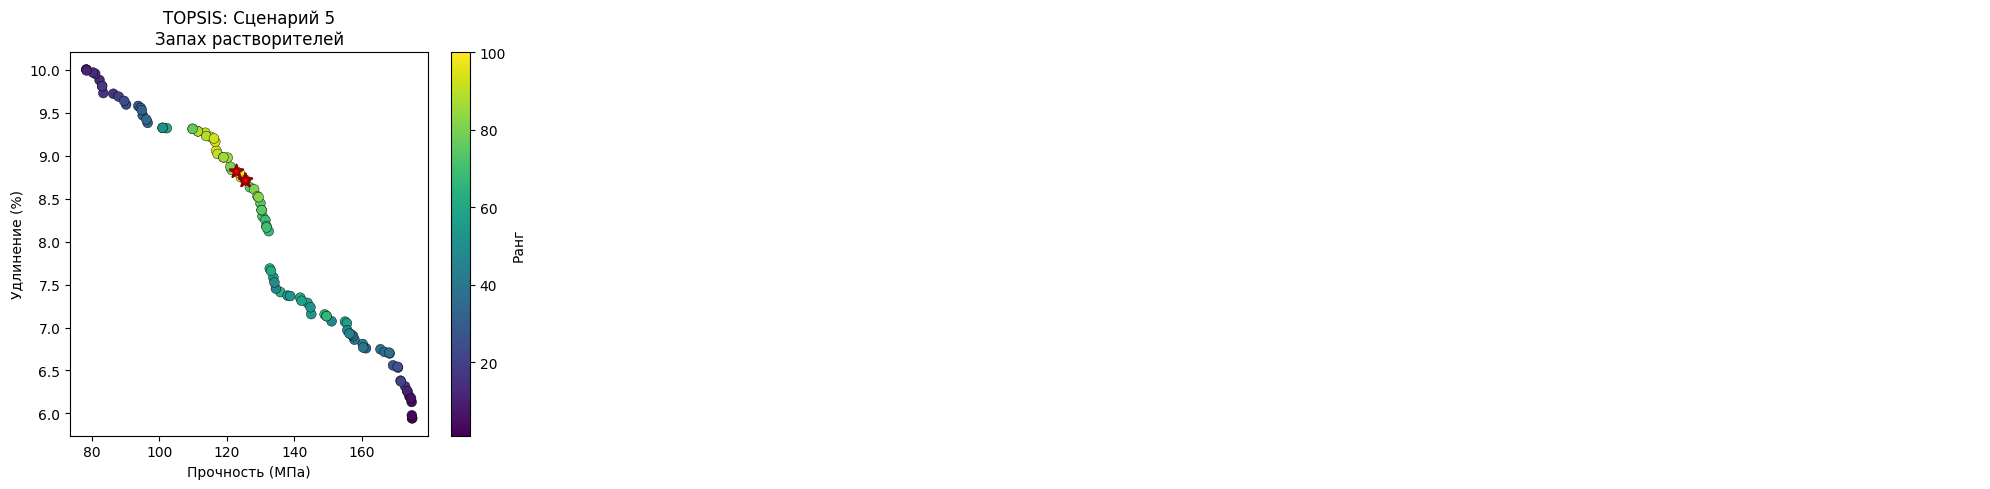

In [ ]:
# ============================================================
# 6.3. TOPSIS
# ============================================================
print("\n" + "=" * 70)
print("6.3. TOPSIS")
print("=" * 70)

def topsis_ranking(hv_norm, h_norm, p_norm, w1=0.5, w2=0.5):
    """
    TOPSIS — Technique for Order Preference by Similarity to Ideal Solution.

    Критерии:
      - HV_norm: максимизировать
      - h_norm:  максимизировать
      - P_norm:  минимизировать

    Веса критериев: w1 (HV), w2 (h), w3=1-w1-w2 (P)
    """
    N = len(hv_norm)

    # Матрица решений (N × 3)
    X = np.column_stack([hv_norm, h_norm, -p_norm])  # P с минусом, т.к. минимизируем

    # Веса
    weights = np.array([w1, w2, 1 - w1 - w2])
    weights = weights / weights.sum()

    # Взвешенная нормализованная матрица
    X_weighted = X * weights

    # Идеальное и анти-идеальное решения
    ideal = np.max(X_weighted, axis=0)
    anti_ideal = np.min(X_weighted, axis=0)

    # Расстояния
    dist_to_ideal = np.sqrt(np.sum((X_weighted - ideal)**2, axis=1))
    dist_to_anti = np.sqrt(np.sum((X_weighted - anti_ideal)**2, axis=1))

    # Коэффициент близости
    closeness = dist_to_anti / (dist_to_ideal + dist_to_anti + 1e-10)

    return np.argsort(closeness)[::-1]


rankings['TOPSIS'] = {}

for scenario_id in active_scenario_ids:
    s = SCENARIOS[scenario_id]
    norm = s['norm']

    # Веса для TOPSIS — используем w1 из сценария
    w1 = s['w1']
    w2 = s['w2']
    # w3 для P — берём 0.2
    w3 = 0.2
    total = w1 + w2 + w3
    w1, w2, w3 = w1/total, w2/total, w3/total

    ranking = topsis_ranking(norm['hv_norm'], norm['h_norm'], norm['p_norm'], w1, w2)
    rankings['TOPSIS'][scenario_id] = ranking

    top3 = ranking[:3]
    print(f"\nСценарий {scenario_id} ({s['name']}):")
    print(f"  Веса: HV={w1:.2f}, h={w2:.2f}, P={w3:.2f}")
    for i, idx in enumerate(top3):
        row = pareto_df.iloc[idx]
        print(f"  {i+1}. Точка {idx}: S={row['strength']:.0f}, E={row['elongation']:.2f}, "
              f"HV={hv_values[idx]:.1f}, h={h_values[idx]:.3f}")

# Визуализация для всех сценариев
n_scenarios = len(active_scenario_ids)
n_cols = 4  # 4 колонки
n_rows = (n_scenarios + n_cols - 1) // n_cols  # автовычисление строк

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5 * n_rows))
axes = axes.flatten()  # превращаем в одномерный массив

for col, scenario_id in enumerate(active_scenario_ids):
    ax = axes[col]
    s = SCENARIOS[scenario_id]
    ranking = rankings['TOPSIS'][scenario_id]
    scores = np.zeros(100)
    scores[ranking] = np.arange(100, 0, -1)

    sc = ax.scatter(pareto_df['strength'], pareto_df['elongation'],
                    c=scores, cmap='viridis', s=50, edgecolors='black', linewidth=0.3)
    top3 = ranking[:3]
    ax.scatter(pareto_df.iloc[top3]['strength'], pareto_df.iloc[top3]['elongation'],
               c='red', s=100, marker='*', edgecolors='darkred', linewidth=1.5, zorder=10)
    ax.set_xlabel('Прочность (МПа)')
    ax.set_ylabel('Удлинение (%)')
    ax.set_title(f'TOPSIS: Сценарий {scenario_id}\n{s["name"][:40]}')
    plt.colorbar(sc, ax=ax, label='Ранг')

# Скрываем лишние subplot'ы
for col in range(n_scenarios, len(axes)):
    axes[col].axis('off')

plt.tight_layout()
plt.savefig('TOPSIS.png', dpi=150, bbox_inches='tight')
plt.show()

## 6.4. VIKOR


6.4. VIKOR

Сценарий 5 (Запах растворителей):
  Веса: HV=0.67, h=0.17, P=0.17
  1. Точка 50: S=123, E=8.82, HV=151.8, h=0.093
  2. Точка 87: S=126, E=8.72, HV=154.7, h=0.044
  3. Точка 51: S=126, E=8.72, HV=154.7, h=0.044


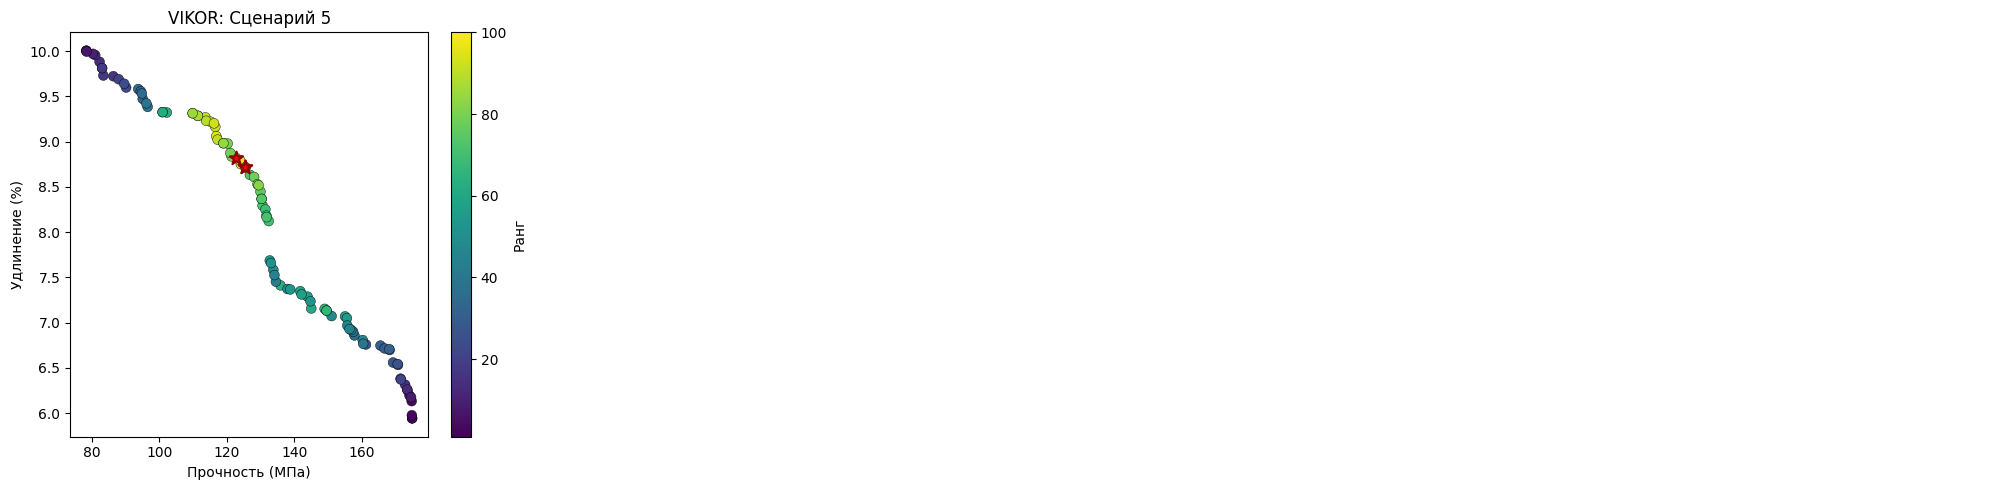

In [ ]:
# ============================================================
# 6.4. VIKOR
# ============================================================
print("\n" + "=" * 70)
print("6.4. VIKOR")
print("=" * 70)

def vikor_ranking(hv_norm, h_norm, p_norm, w1=0.5, w2=0.5, v=0.5):
    """
    VIKOR — компромиссное ранжирование.

    Параметры:
      v: вес групповой полезности (0.5 = баланс между полезностью и сожалением)
    """
    N = len(hv_norm)

    # Матрица решений (N × 3), P с минусом
    X = np.column_stack([hv_norm, h_norm, -p_norm])

    # Веса
    weights = np.array([w1, w2, 1 - w1 - w2])
    weights = weights / weights.sum()

    # Идеальное и наихудшее
    best = np.max(X, axis=0)
    worst = np.min(X, axis=0)

    # Нормализованные разности
    ranges = best - worst + 1e-10

    # S_i — групповая полезность (средневзвешенное отклонение)
    S = np.sum(weights * (best - X) / ranges, axis=1)

    # R_i — индивидуальное сожаление (максимальное отклонение)
    R = np.max(weights * (best - X) / ranges, axis=1)

    # Q_i — компромиссный индекс
    S_min, S_max = S.min(), S.max()
    R_min, R_max = R.min(), R.max()
    ranges_S = S_max - S_min + 1e-10
    ranges_R = R_max - R_min + 1e-10

    Q = v * (S - S_min) / ranges_S + (1 - v) * (R - R_min) / ranges_R

    # Чем меньше Q, тем лучше
    return np.argsort(Q)


rankings['VIKOR'] = {}

for scenario_id in active_scenario_ids:
    s = SCENARIOS[scenario_id]
    norm = s['norm']

    w1 = s['w1']
    w2 = s['w2']
    w3 = 0.2
    total = w1 + w2 + w3
    w1, w2, w3 = w1/total, w2/total, w3/total

    ranking = vikor_ranking(norm['hv_norm'], norm['h_norm'], norm['p_norm'], w1, w2)
    rankings['VIKOR'][scenario_id] = ranking

    top3 = ranking[:3]
    print(f"\nСценарий {scenario_id} ({s['name']}):")
    print(f"  Веса: HV={w1:.2f}, h={w2:.2f}, P={w3:.2f}")
    for i, idx in enumerate(top3):
        row = pareto_df.iloc[idx]
        print(f"  {i+1}. Точка {idx}: S={row['strength']:.0f}, E={row['elongation']:.2f}, "
              f"HV={hv_values[idx]:.1f}, h={h_values[idx]:.3f}")

# Визуализация для всех сценариев
n_scenarios = len(active_scenario_ids)
n_cols = 4
n_rows = (n_scenarios + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5 * n_rows))
axes = axes.flatten()

for col, scenario_id in enumerate(active_scenario_ids):
    ax = axes[col]
    ranking = rankings['VIKOR'][scenario_id]
    scores = np.zeros(100)
    scores[ranking] = np.arange(100, 0, -1)

    sc = ax.scatter(pareto_df['strength'], pareto_df['elongation'],
                    c=scores, cmap='viridis', s=50, edgecolors='black', linewidth=0.3)
    top3 = ranking[:3]
    ax.scatter(pareto_df.iloc[top3]['strength'], pareto_df.iloc[top3]['elongation'],
               c='red', s=100, marker='*', edgecolors='darkred', linewidth=1.5, zorder=10)
    ax.set_xlabel('Прочность (МПа)')
    ax.set_ylabel('Удлинение (%)')
    ax.set_title(f'VIKOR: Сценарий {scenario_id}')
    plt.colorbar(sc, ax=ax, label='Ранг')

# Скрываем лишние subplot'ы
for col in range(n_scenarios, len(axes)):
    axes[col].axis('off')

plt.tight_layout()
plt.savefig('VIKOR.png', dpi=150, bbox_inches='tight')
plt.show()

## 6.5. PROMETHEE II


6.5. PROMETHEE II

Сценарий 5 (Запах растворителей):
  Веса: HV=0.67, h=0.17, P=0.17
  1. Точка 50: S=123, E=8.82, HV=151.8, h=0.093
  2. Точка 35: S=117, E=9.06, HV=143.9, h=0.115
  3. Точка 87: S=126, E=8.72, HV=154.7, h=0.044


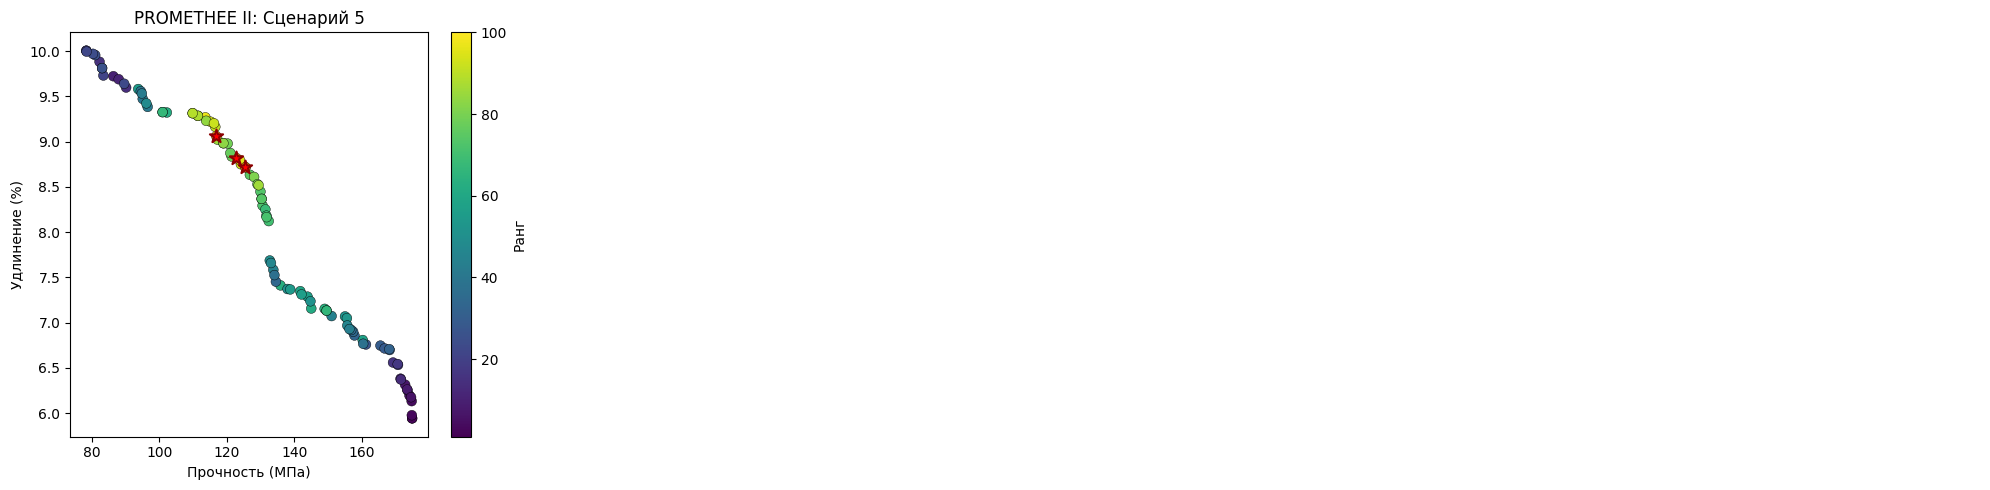

In [ ]:
# ============================================================
# 6.5. PROMETHEE II
# ============================================================
print("\n" + "=" * 70)
print("6.5. PROMETHEE II")
print("=" * 70)

def promethee_ranking(hv_norm, h_norm, p_norm, w1=0.5, w2=0.5):
    """
    PROMETHEE II — попарное сравнение с функцией предпочтения.

    Использует V-shape функцию предпочтения: P(d) = min(1, |d|/threshold)
    """
    N = len(hv_norm)

    # Матрица решений, P с минусом
    X = np.column_stack([hv_norm, h_norm, -p_norm])

    # Веса
    weights = np.array([w1, w2, 1 - w1 - w2])
    weights = weights / weights.sum()

    # Пороги для V-shape функции (половина стандартного отклонения)
    thresholds = np.std(X, axis=0) * 0.5 + 1e-10

    # Матрица предпочтений Pi(i,j) — насколько i предпочтительнее j
    Pi = np.zeros((N, N))

    for i in range(N):
        for j in range(N):
            if i == j:
                continue
            # Разности по каждому критерию
            diff = X[i] - X[j]
            # V-shape: P(d) = max(0, min(1, d/threshold)) для положительных d
            pref = np.where(diff > 0, np.minimum(1, diff / thresholds), 0)
            Pi[i, j] = np.sum(weights * pref)

    # Положительный поток (outranking): насколько i доминирует над другими
    phi_plus = Pi.sum(axis=1) / (N - 1)

    # Отрицательный поток: насколько i доминируется другими
    phi_minus = Pi.sum(axis=0) / (N - 1)

    # Чистый поток — чем больше, тем лучше
    phi_net = phi_plus - phi_minus

    return np.argsort(phi_net)[::-1]


rankings['PROMETHEE'] = {}

for scenario_id in active_scenario_ids:
    s = SCENARIOS[scenario_id]
    norm = s['norm']

    w1 = s['w1']
    w2 = s['w2']
    w3 = 0.2
    total = w1 + w2 + w3
    w1, w2, w3 = w1/total, w2/total, w3/total

    ranking = promethee_ranking(norm['hv_norm'], norm['h_norm'], norm['p_norm'], w1, w2)
    rankings['PROMETHEE'][scenario_id] = ranking

    top3 = ranking[:3]
    print(f"\nСценарий {scenario_id} ({s['name']}):")
    print(f"  Веса: HV={w1:.2f}, h={w2:.2f}, P={w3:.2f}")
    for i, idx in enumerate(top3):
        row = pareto_df.iloc[idx]
        print(f"  {i+1}. Точка {idx}: S={row['strength']:.0f}, E={row['elongation']:.2f}, "
              f"HV={hv_values[idx]:.1f}, h={h_values[idx]:.3f}")

# Визуализация для всех сценариев
n_scenarios = len(active_scenario_ids)
n_cols = 4
n_rows = (n_scenarios + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5 * n_rows))
axes = axes.flatten()

for col, scenario_id in enumerate(active_scenario_ids):
    ax = axes[col]
    ranking = rankings['PROMETHEE'][scenario_id]
    scores = np.zeros(100)
    scores[ranking] = np.arange(100, 0, -1)

    sc = ax.scatter(pareto_df['strength'], pareto_df['elongation'],
                    c=scores, cmap='viridis', s=50, edgecolors='black', linewidth=0.3)
    top3 = ranking[:3]
    ax.scatter(pareto_df.iloc[top3]['strength'], pareto_df.iloc[top3]['elongation'],
               c='red', s=100, marker='*', edgecolors='darkred', linewidth=1.5, zorder=10)
    ax.set_xlabel('Прочность (МПа)')
    ax.set_ylabel('Удлинение (%)')
    ax.set_title(f'PROMETHEE II: Сценарий {scenario_id}')
    plt.colorbar(sc, ax=ax, label='Ранг')

for col in range(n_scenarios, len(axes)):
    axes[col].axis('off')

plt.tight_layout()
plt.savefig('PROMETHEE.png', dpi=150, bbox_inches='tight')
plt.show()

## 6.6. Гибридный метод


6.6. Гибридный метод

Сценарий 5 (Запах растворителей):
  Параметры: α=0.6, β=0.15
  1. Точка 50: S=123, E=8.82, Score=1.303, HV=151.8, h=0.093
  2. Точка 35: S=117, E=9.06, Score=1.293, HV=143.9, h=0.115
  3. Точка 53: S=114, E=9.27, Score=1.287, HV=141.5, h=0.112


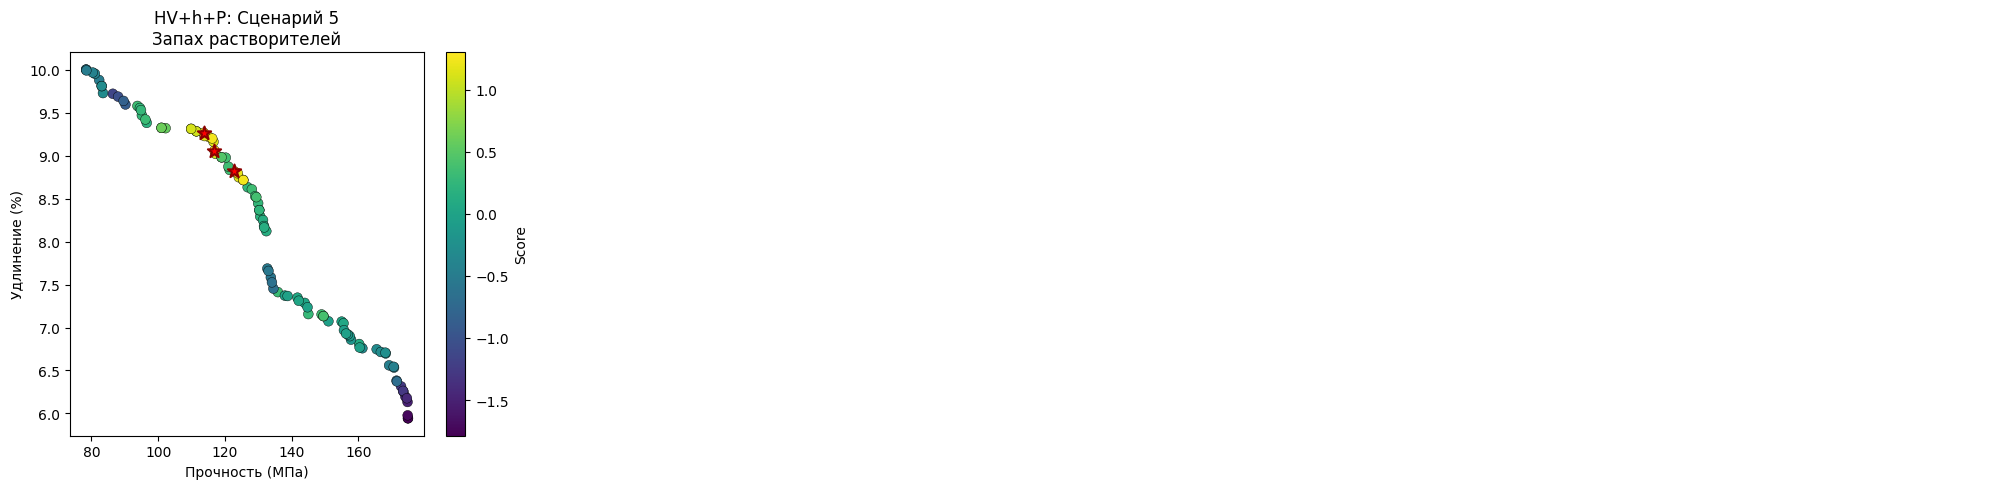

In [ ]:
# ============================================================
# 6.6. Гибридный метод
# ============================================================
print("\n" + "=" * 70)
print("6.6. Гибридный метод")
print("=" * 70)

def hybrid_ranking(hv_norm, h_norm, p_norm, alpha=0.6, beta=0.15):
    """
    Гибридный метод из технологической статьи (п. 2.6):

    Score = alpha * HV_norm + (1-alpha) * h_norm - beta * P_norm

    Параметры:
      alpha: баланс между HV и h (0.6 = HV важнее)
      beta:  вес штрафов P(x)
    """
    score = alpha * hv_norm + (1 - alpha) * h_norm - beta * p_norm
    return np.argsort(score)[::-1]


rankings['HV+h+P'] = {}

for scenario_id in active_scenario_ids:
    s = SCENARIOS[scenario_id]
    norm = s['norm']

    # Параметры метода
    alpha = 0.6   # гиперобъём важнее эвристики
    beta = 0.15   # вес штрафов

    ranking = hybrid_ranking(norm['hv_norm'], norm['h_norm'], norm['p_norm'], alpha, beta)
    rankings['HV+h+P'][scenario_id] = ranking

    # Вычисляем Score для статистики
    score = alpha * norm['hv_norm'] + (1 - alpha) * norm['h_norm'] - beta * norm['p_norm']

    top3 = ranking[:3]
    print(f"\nСценарий {scenario_id} ({s['name']}):")
    print(f"  Параметры: α={alpha}, β={beta}")
    for i, idx in enumerate(top3):
        row = pareto_df.iloc[idx]
        print(f"  {i+1}. Точка {idx}: S={row['strength']:.0f}, E={row['elongation']:.2f}, "
              f"Score={score[idx]:.3f}, HV={hv_values[idx]:.1f}, h={h_values[idx]:.3f}")

# Визуализация для всех сценариев
n_scenarios = len(active_scenario_ids)
n_cols = 4
n_rows = (n_scenarios + n_cols - 1) // n_cols

alpha = 0.6
beta = 0.15

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5 * n_rows))
axes = axes.flatten()

for col, scenario_id in enumerate(active_scenario_ids):
    ax = axes[col]
    s = SCENARIOS[scenario_id]
    norm = s['norm']
    score = alpha * norm['hv_norm'] + (1 - alpha) * norm['h_norm'] - beta * norm['p_norm']
    ranking = rankings['HV+h+P'][scenario_id]

    sc = ax.scatter(pareto_df['strength'], pareto_df['elongation'],
                    c=score, cmap='viridis', s=50, edgecolors='black', linewidth=0.3)
    top3 = ranking[:3]
    ax.scatter(pareto_df.iloc[top3]['strength'], pareto_df.iloc[top3]['elongation'],
               c='red', s=100, marker='*', edgecolors='darkred', linewidth=1.5, zorder=10)
    ax.set_xlabel('Прочность (МПа)')
    ax.set_ylabel('Удлинение (%)')
    ax.set_title(f'HV+h+P: Сценарий {scenario_id}\n{s["name"][:40]}')
    plt.colorbar(sc, ax=ax, label='Score')

for col in range(n_scenarios, len(axes)):
    axes[col].axis('off')

plt.tight_layout()
plt.savefig('HV+h+P.png', dpi=150, bbox_inches='tight')
plt.show()

## 6.7. Гибридный + LISTEN-T


6.7. Гибридный + LISTEN-T

  🏆 ТУРНИР LISTEN-T (топ-10)

  Раунд 1 (10 участников):
    50 (S=123, E=8.8) vs 35 (S=117, E=9.1) → 50 (Ответ LLM: 50)
    53 (S=114, E=9.3) vs 57 (S=115, E=9.2) → 57 (Ответ LLM: 57)
    66 (S=116, E=9.2) vs 87 (S=126, E=8.7) → 87 (Ответ LLM: 87)
    51 (S=126, E=8.7) vs 60 (S=124, E=8.8) → 51 (Ответ LLM: 51)
    46 (S=124, E=8.7) vs 65 (S=114, E=9.2) → 46 (Ответ LLM: 46)

  Раунд 2 (5 участников):
    50 (S=123, E=8.8) vs 57 (S=115, E=9.2) → 50 (Ответ LLM: 50)
    87 (S=126, E=8.7) vs 51 (S=126, E=8.7) → 87 (Ответ LLM: 87)

  Раунд 3 (3 участников):
    50 (S=123, E=8.8) vs 87 (S=126, E=8.7) → 87 (Ответ LLM: 87)

  Раунд 4 (2 участников):
    87 (S=126, E=8.7) vs 46 (S=124, E=8.7) → 87 (Ответ LLM: 87)

  Итоговый топ-3 для сценария 5:
  1. Точка 87: S=126, E=8.72, HV=154.7, h=0.044
  2. Точка 46: S=124, E=8.75, HV=152.4, h=0.018
  3. Точка 50: S=123, E=8.82, HV=151.8, h=0.093


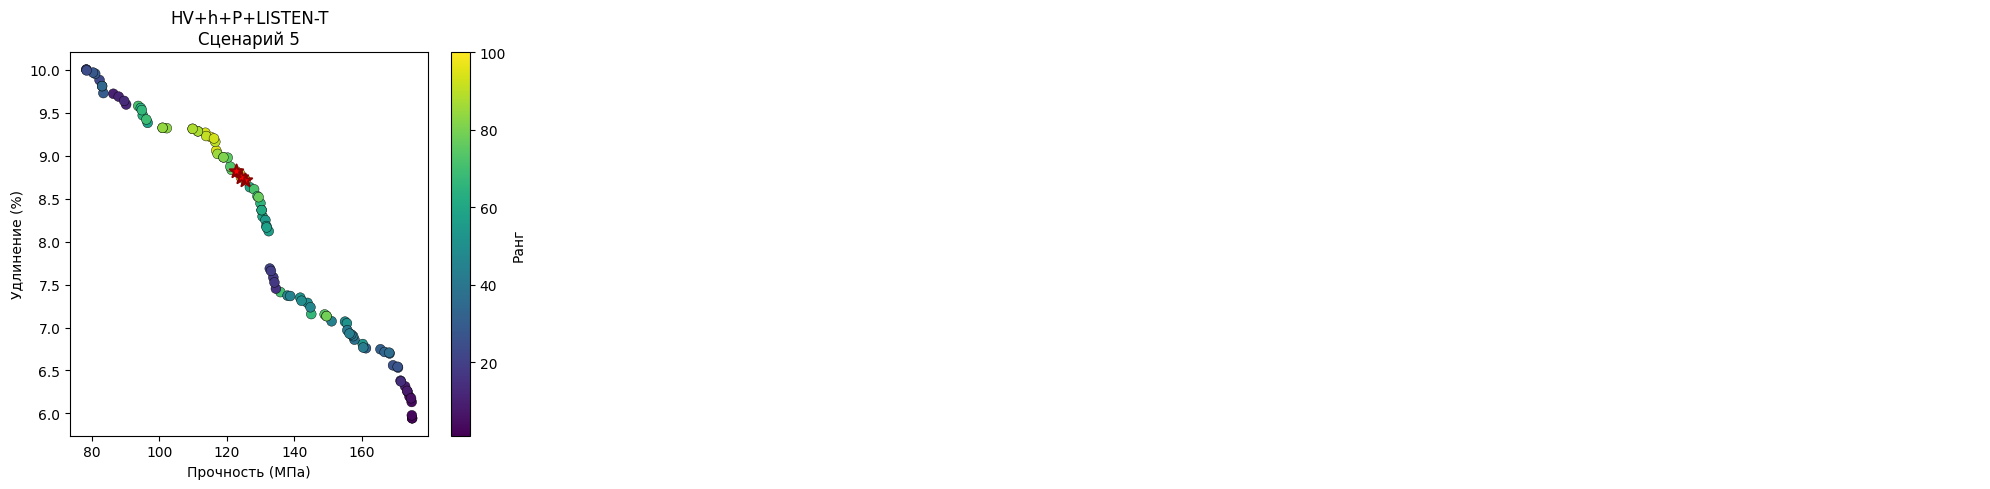

In [ ]:
# ============================================================
# 6.7. Гибридный + LISTEN-T (турнирный отбор через LLM)
# ============================================================
print("\n" + "=" * 70)
print("6.7. Гибридный + LISTEN-T")
print("=" * 70)

def listen_tournament(top10_indices, scenario_name, pareto_df, pareto_llm_texts):
    """
    Турнирный отбор через LLM (LISTEN-T).

    Берёт топ-10 точек, разбивает на пары, LLM выбирает лучшего в каждой паре.
    Победители проходят дальше. Финальное ранжирование — по количеству побед.
    Сравнивает ПОЛНЫЕ описания рецептур, а не отдельные параметры.
    """
    N = len(top10_indices)
    wins = {idx: 0 for idx in top10_indices}

    print(f"\n  🏆 ТУРНИР LISTEN-T (топ-{N})")

    current_round = list(top10_indices)
    round_num = 1

    while len(current_round) > 1:
        print(f"\n  Раунд {round_num} ({len(current_round)} участников):")
        next_round = []

        for i in range(0, len(current_round), 2):
            if i + 1 >= len(current_round):
                next_round.append(current_round[i])
                wins[current_round[i]] += 1
                continue

            idx_a = current_round[i]
            idx_b = current_round[i+1]

            # Формируем промпт с ПОЛНЫМИ описаниями рецептур
            prompt = f"""Ты — эксперт-технолог производства MLCC-конденсаторов.

Контекст сценария: {scenario_name}

Сравни две рецептуры и выбери лучшую с точки зрения технолога.

=== РЕЦЕПТУРА А (точка {idx_a}) ===
{pareto_llm_texts[idx_a]}

=== РЕЦЕПТУРА Б (точка {idx_b}) ===
{pareto_llm_texts[idx_b]}

Какая рецептура лучше? Ответь ТОЛЬКО числом: {idx_a} или {idx_b}."""

            try:
                response = get_llm_response(prompt, max_tokens=20, system_role="technologist")
                winner_raw = response.strip() if response else ""

                # Ищем номер точки в ответе
                if str(idx_a) in winner_raw and str(idx_b) not in winner_raw:
                    winner_idx = idx_a
                elif str(idx_b) in winner_raw and str(idx_a) not in winner_raw:
                    winner_idx = idx_b
                else:
                    # Если LLM не ответила однозначно — по HV
                    winner_idx = idx_a if hv_values[idx_a] > hv_values[idx_b] else idx_b
                    winner_raw = f"непонятно: '{winner_raw}'"

                wins[winner_idx] += 1
                next_round.append(winner_idx)

                row_a = pareto_df.iloc[idx_a]
                row_b = pareto_df.iloc[idx_b]
                print(f"    {idx_a} (S={row_a['strength']:.0f}, E={row_a['elongation']:.1f}) vs "
                      f"{idx_b} (S={row_b['strength']:.0f}, E={row_b['elongation']:.1f}) → {winner_idx} "
                      f"(Ответ LLM: {winner_raw})")

            except Exception as e:
                print(f"    ⚠️ Ошибка API: {e}")
                winner_idx = idx_a if hv_values[idx_a] > hv_values[idx_b] else idx_b
                wins[winner_idx] += 1
                next_round.append(winner_idx)
                row_a = pareto_df.iloc[idx_a]
                row_b = pareto_df.iloc[idx_b]
                print(f"    {idx_a} (S={row_a['strength']:.0f}, E={row_a['elongation']:.1f}) vs "
                      f"{idx_b} (S={row_b['strength']:.0f}, E={row_b['elongation']:.1f}) → {winner_idx} "
                      f"(fallback: ошибка API)")

        current_round = next_round
        round_num += 1

    # Финальное ранжирование по числу побед
    sorted_by_wins = sorted(wins.items(), key=lambda x: x[1], reverse=True)
    final_ranking = [idx for idx, _ in sorted_by_wins]

    return final_ranking


rankings['HV+h+P+LISTEN-T'] = {}

for scenario_id in active_scenario_ids:
    s = SCENARIOS[scenario_id]
    norm = s['norm']

    # Гибридный Score для отбора топ-10
    alpha = 0.6
    beta = 0.15
    score = alpha * norm['hv_norm'] + (1 - alpha) * norm['h_norm'] - beta * norm['p_norm']
    hybrid_ranking_full = np.argsort(score)[::-1]

    # Топ-10 для турнира
    top10 = list(hybrid_ranking_full[:10])

    # Запускаем турнир с полными описаниями
    top10_ranked = listen_tournament(top10, s['name'], pareto_df, pareto_llm_texts)

    # Полный ранжированный список
    remaining = [idx for idx in hybrid_ranking_full if idx not in top10_ranked]
    full_ranking = top10_ranked + remaining

    rankings['HV+h+P+LISTEN-T'][scenario_id] = np.array(full_ranking)

    print(f"\n  Итоговый топ-3 для сценария {scenario_id}:")
    for i, idx in enumerate(full_ranking[:3]):
        row = pareto_df.iloc[idx]
        print(f"  {i+1}. Точка {idx}: S={row['strength']:.0f}, E={row['elongation']:.2f}, "
              f"HV={hv_values[idx]:.1f}, h={h_values[idx]:.3f}")

# Визуализация для всех сценариев
n_scenarios = len(active_scenario_ids)
n_cols = 4
n_rows = (n_scenarios + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5 * n_rows))
axes = axes.flatten()

for col, scenario_id in enumerate(active_scenario_ids):
    ax = axes[col]
    ranking = rankings['HV+h+P+LISTEN-T'][scenario_id]
    scores = np.zeros(100)
    scores[ranking] = np.arange(100, 0, -1)

    sc = ax.scatter(pareto_df['strength'], pareto_df['elongation'],
                    c=scores, cmap='viridis', s=50, edgecolors='black', linewidth=0.3)
    top3 = ranking[:3]
    ax.scatter(pareto_df.iloc[top3]['strength'], pareto_df.iloc[top3]['elongation'],
               c='red', s=100, marker='*', edgecolors='darkred', linewidth=1.5, zorder=10)
    ax.set_xlabel('Прочность (МПа)')
    ax.set_ylabel('Удлинение (%)')
    ax.set_title(f'HV+h+P+LISTEN-T\nСценарий {scenario_id}')
    plt.colorbar(sc, ax=ax, label='Ранг')

for col in range(n_scenarios, len(axes)):
    axes[col].axis('off')

plt.tight_layout()
plt.savefig('HV+h+P+LISTEN-T.png', dpi=150, bbox_inches='tight')
plt.show()

## 6.8. LISTENTOME — турнирный отбор со знанием h(x), P(x) и HV


6.8. LISTENTOME

  🏆 ТУРНИР LISTENTOME (топ-10)

  Раунд 1 (10 участников):
    50 vs 35 → 50 (Ответ LLM: 50 - Вес загрузки, время смешивания и вязкость на второй стадии соответствуют целевым показателям лучше. Также более высокий гиперобъём указывает на лучшую оптимизационную ценность решения.)
    53 vs 57 → 57 (Ответ LLM: 57 - В рецептуре Б технологические параметры более оптимальны по весу загрузки, вязкости и объему смеси растворителей. HV также выше, что указывает на лучшую математическую оптимизацию.)
    66 vs 87 → 87 (Ответ LLM: 87 - выбрана лучшая рецептура из-за более высокой гиперобъёма и технологической безопасности. Гиперобъём HV = 154.7 указывает на оптимальное решение с точки зрения математической оптимизации, а h(x) = +0.044 показывает, что параметры рецептуры похожи на успешные исторические данные.)
    51 vs 60 → 51 (Ответ LLM: 51

Основные причины:
- Вес загрузки и доли компонентов совпадают, что упрощает производство.
- Вязкость на второй стадии смешивания одинако

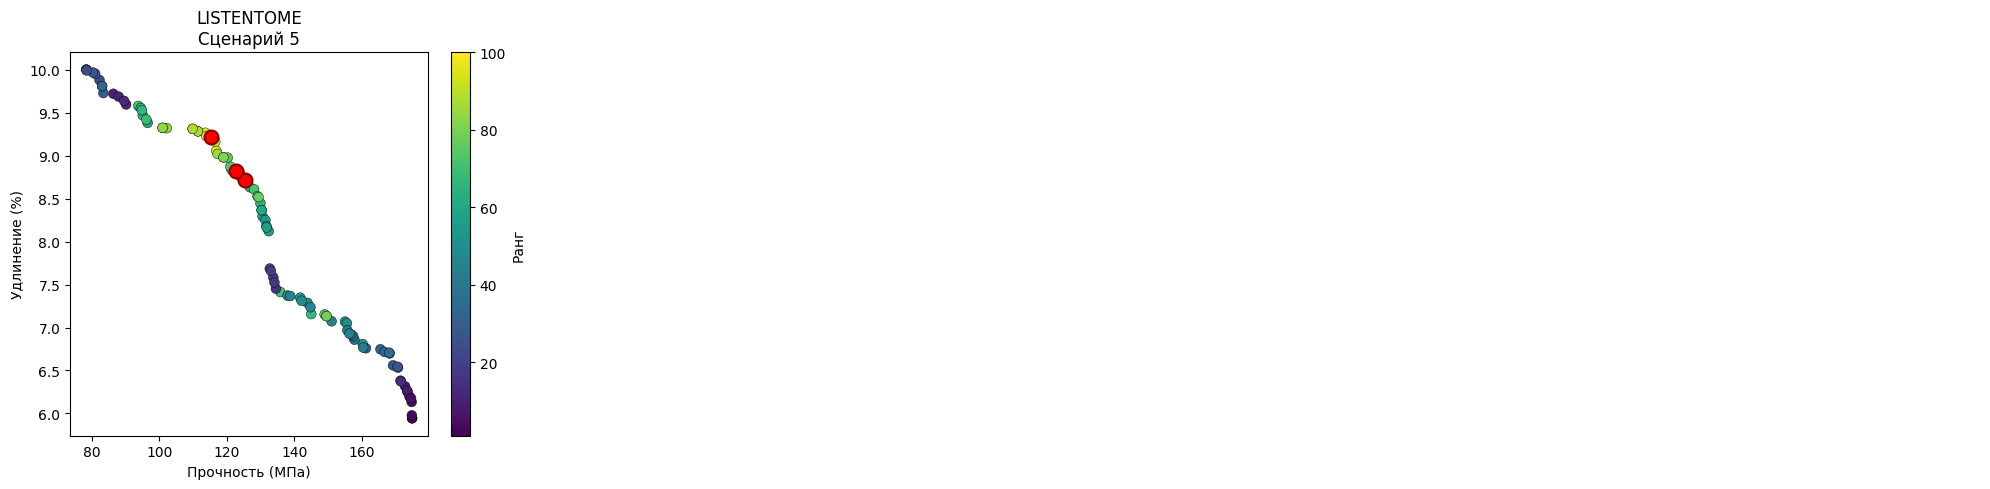

In [ ]:
# ============================================================
# 6.8. LISTENTOME
# ============================================================
print("\n" + "=" * 70)
print("6.8. LISTENTOME")
print("=" * 70)

def describe_h(h_val):
    return f"""h(x) = {h_val:+.3f}
Оценка технологической безопасности рецепта (сравнение с историческими данными):
• Положительные значения (до +1) — параметры похожи на исторически УСПЕШНЫЕ рецепты
• Отрицательные значения (до -1) — параметры похожи на исторически ПРОВАЛЬНЫЕ рецепты
• Около 0 — нейтрально
Чем ВЫШЕ h(x), тем технологически безопаснее рецепт."""

def describe_P(p_val, prefs, p_max):
    pct = p_val / p_max * 100 if p_max > 0 else 0
    prefs_short = ', '.join([f"{p}→{'min' if d=='minimize' else 'max'}" for p, d in prefs]) if prefs else 'нет'
    return f"""P(x) = {p_val:.3f} ({pct:.0f}% от максимума {p_max:.3f})
Штраф за несоответствие пожеланиям технолога: {prefs_short}
• 0 = полное соответствие
• Чем ВЫШЕ P(x), тем сильнее отклонение от пожеланий"""

def describe_HV(hv_val, hv_max):
    pct = hv_val / hv_max * 100 if hv_max > 0 else 0
    return f"""HV = {hv_val:.1f} ({pct:.0f}% от максимума {hv_max:.0f})
Гиперобъём — оптимизационная ценность решения.
• Чем ВЫШЕ, тем лучше с точки зрения математической оптимизации"""


def listentome_tournament(top10_indices, scenario_name, scenario_id,
                           pareto_df, pareto_llm_texts, h_values, hv_values, norm):
    """
    LISTENTOME — турнирный отбор через LLM.
    1. Турнирная сетка с накоплением побед
    2. Fallback Score через z-нормированные значения
    """
    N = len(top10_indices)
    wins = {idx: 0 for idx in top10_indices}
    total_comparisons = {idx: 0 for idx in top10_indices}

    print(f"\n  🏆 ТУРНИР LISTENTOME (топ-{N})")

    prefs = SCENARIOS[scenario_id]['prefs']
    p_max = pareto_df[f'P_scenario_{scenario_id}'].max()
    hv_max = hv_values.max()

    # Параметры для fallback Score (z-нормированные)
    alpha = 0.6
    beta = 0.15

    current_round = list(top10_indices)
    round_num = 1

    while len(current_round) > 1:
        print(f"\n  Раунд {round_num} ({len(current_round)} участников):")
        next_round = []

        for i in range(0, len(current_round), 2):
            if i + 1 >= len(current_round):
                # Нечётное число — проходит автоматически
                next_round.append(current_round[i])
                continue

            idx_a = current_round[i]
            idx_b = current_round[i+1]

            row_a = pareto_df.iloc[idx_a]
            row_b = pareto_df.iloc[idx_b]

            h_a = h_values[idx_a]
            h_b = h_values[idx_b]
            hv_a = hv_values[idx_a]
            hv_b = hv_values[idx_b]
            p_a = pareto_df[f'P_scenario_{scenario_id}'].iloc[idx_a]
            p_b = pareto_df[f'P_scenario_{scenario_id}'].iloc[idx_b]

            prompt = f"""Ты — эксперт-технолог производства MLCC-конденсаторов.

Контекст сценария: {scenario_name}

Сравни две рецептуры и выбери лучшую. При решении учитывай:
• Целевые показатели (прочность, удлинение)
• Оптимизационную ценность (HV — гиперобъём)
• Технологическую безопасность (h(x) — сравнение с историей)
• Соответствие пожеланиям (P(x) — штраф)
• НО ГЛАВНОЕ! Сами технологические параметры рецептуры

ГЛАВНЫЙ критерий выбора — САМИ ТЕХНОЛОГИЧЕСКИЕ ПАРАМЕТРЫ рецептуры.
Метрики (HV, h(x), P(x)) используй только как вспомогательные подсказки, а не как основной критерий.

=== РЕЦЕПТУРА А (точка {idx_a}) ===

ТЕХНОЛОГИЧЕСКИЕ ПАРАМЕТРЫ (ОСНОВНОЙ КРИТЕРИЙ):
{pareto_llm_texts[idx_a]}
ЦЕЛЕВЫЕ ПОКАЗАТЕЛИ:
  Прочность: {row_a['strength']:.0f} МПа
  Удлинение: {row_a['elongation']:.2f}%
ГИПЕРОБЪЕМ:
  {describe_HV(hv_a, hv_max)}
ТЕХНОЛОГИЧЕСКАЯ БЕЗОПАСНОСТЬ:
  {describe_h(h_a)}
СООТВЕТСТВИЕ ПОЖЕЛАНИЯМ:
  {describe_P(p_a, prefs, p_max)}

=== РЕЦЕПТУРА Б (точка {idx_b}) ===

ТЕХНОЛОГИЧЕСКИЕ ПАРАМЕТРЫ (ОСНОВНОЙ КРИТЕРИЙ):
{pareto_llm_texts[idx_b]}
ЦЕЛЕВЫЕ ПОКАЗАТЕЛИ:
  Прочность: {row_b['strength']:.0f} МПа
  Удлинение: {row_b['elongation']:.2f}%
ГИПЕРОБЪЕМ:
  {describe_HV(hv_b, hv_max)}
ТЕХНОЛОГИЧЕСКАЯ БЕЗОПАСНОСТЬ:
  {describe_h(h_b)}
СООТВЕТСТВИЕ ПОЖЕЛАНИЯМ:
  {describe_P(p_b, prefs, p_max)}

Ответь СТРОГО в формате (на русском):
{idx_a} или {idx_b} — краткое объяснение своего выбора (перечисли только причины)
"""

            try:
                response = get_llm_response(prompt, max_tokens=200, system_role="technologist")
                response_clean = response.strip()

                # Ищем номер точки в ответе
                if str(idx_a) in response_clean and str(idx_b) not in response_clean:
                    winner_idx = idx_a
                elif str(idx_b) in response_clean and str(idx_a) not in response_clean:
                    winner_idx = idx_b
                else:
                    score_a = alpha * norm['hv_norm'][idx_a] + (1-alpha) * norm['h_norm'][idx_a] - beta * norm['p_norm'][idx_a]
                    score_b = alpha * norm['hv_norm'][idx_b] + (1-alpha) * norm['h_norm'][idx_b] - beta * norm['p_norm'][idx_b]
                    winner_idx = idx_a if score_a > score_b else idx_b

                wins[winner_idx] += 1
                total_comparisons[idx_a] += 1
                total_comparisons[idx_b] += 1
                next_round.append(winner_idx)

                print(f"    {idx_a} vs {idx_b} → {winner_idx} (Ответ LLM: {response_clean})")

            except Exception as e:
                print(f"    ⚠️ Ошибка API: {e}")
                score_a = alpha * norm['hv_norm'][idx_a] + (1-alpha) * norm['h_norm'][idx_a] - beta * norm['p_norm'][idx_a]
                score_b = alpha * norm['hv_norm'][idx_b] + (1-alpha) * norm['h_norm'][idx_b] - beta * norm['p_norm'][idx_b]
                winner_idx = idx_a if score_a > score_b else idx_b
                wins[winner_idx] += 1
                total_comparisons[idx_a] += 1
                total_comparisons[idx_b] += 1
                next_round.append(winner_idx)
                print(f"    {idx_a} vs {idx_b} → {winner_idx} (fallback: ошибка API)")

        current_round = next_round
        round_num += 1

    # Финальное ранжирование: сначала по wins, потом по числу сравнений (больше сравнений = дальше прошёл)
    sorted_by_wins = sorted(wins.items(), key=lambda x: (x[1], total_comparisons[x[0]]), reverse=True)
    return [idx for idx, _ in sorted_by_wins]

# ----------------------------------------------------------
# Вычисление LISTENTOME для всех сценариев
# ----------------------------------------------------------
rankings['LISTENTOME'] = {}

for scenario_id in active_scenario_ids:
    s = SCENARIOS[scenario_id]
    norm = s['norm']

    alpha = 0.6
    beta = 0.15
    score = alpha * norm['hv_norm'] + (1-alpha) * norm['h_norm'] - beta * norm['p_norm']
    hybrid_ranking_full = np.argsort(score)[::-1]

    top10 = list(hybrid_ranking_full[:10])

    top10_ranked = listentome_tournament(top10, s['name'], scenario_id,
                                          pareto_df, pareto_llm_texts, h_values, hv_values, norm)

    remaining = [idx for idx in hybrid_ranking_full if idx not in top10_ranked]
    full_ranking = top10_ranked + remaining

    rankings['LISTENTOME'][scenario_id] = np.array(full_ranking)

    print(f"\n  Итоговый топ-3 LISTENTOME для сценария {scenario_id}:")
    for i, idx in enumerate(full_ranking[:3]):
        row = pareto_df.iloc[idx]
        print(f"  {i+1}. Точка {idx}: S={row['strength']:.0f}, E={row['elongation']:.2f}, "
              f"h={h_values[idx]:+.3f}, HV={hv_values[idx]:.1f}, "
              f"P={pareto_df[f'P_scenario_{scenario_id}'].iloc[idx]:.3f}")

# Визуализация
n_scenarios = len(active_scenario_ids)
n_cols = 4
n_rows = (n_scenarios + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5 * n_rows))
axes = axes.flatten()

for col, scenario_id in enumerate(active_scenario_ids):
    ax = axes[col]
    ranking = rankings['LISTENTOME'][scenario_id]
    scores = np.zeros(100)
    scores[ranking] = np.arange(100, 0, -1)

    sc = ax.scatter(pareto_df['strength'], pareto_df['elongation'],
                    c=scores, cmap='viridis', s=50, edgecolors='black', linewidth=0.3)
    top3 = ranking[:3]
    ax.scatter(pareto_df.iloc[top3]['strength'], pareto_df.iloc[top3]['elongation'],
               c='red', s=100, marker='o', edgecolors='darkred', linewidth=1.5, zorder=10)
    ax.set_xlabel('Прочность (МПа)')
    ax.set_ylabel('Удлинение (%)')
    ax.set_title(f'LISTENTOME\nСценарий {scenario_id}')
    plt.colorbar(sc, ax=ax, label='Ранг')

for col in range(n_scenarios, len(axes)):
    axes[col].axis('off')

plt.tight_layout()
plt.savefig('listentome_v2.png', dpi=150, bbox_inches='tight')
plt.show()

## 6.9. LISTENTOME+ — LLM подбирает веса α, β под запрос


6.9. LISTENTOME+
    Ответ LLM: 0.3, 0.4

Сценарий 5: Запах растворителей
  LLM подобрала: α=0.30, β=0.40
  (стандартные: α=0.60, β=0.15)

  🏆 ТУРНИР LISTENTOME (топ-10)

  Раунд 1 (10 участников):
    53 vs 35 → 35 (Ответ LLM: 35 - выбрана лучшая рецептура из-за более высокой гиперобъёма и технологической безопасности. Гиперобъём HV для рецептуры 35 составляет 143.9, что выше чем у рецептуры 53 (141.5). Кроме того, оценка технологической безопасности h(x) также выше для рецептуры 35 (+0.115 против +0.112).)
    7 vs 98 → 98 (Ответ LLM: 98

Выбор основывается на технических параметрах рецептуры. Обе рецептуры имеют одинаковые значения для большинства ключевых параметров, но рецепт 98 имеет незначительно более толщину фактическую толщину слоя (32.6 мкм против 32.3 мкм), что может быть критически важно при производстве MLCC-конденсаторов. Дополнительные 0.3 мкм могут обеспечить более стабильное качество продукции, особенно с учетом требуемых целевых показателей прочности и удлинения.)
 

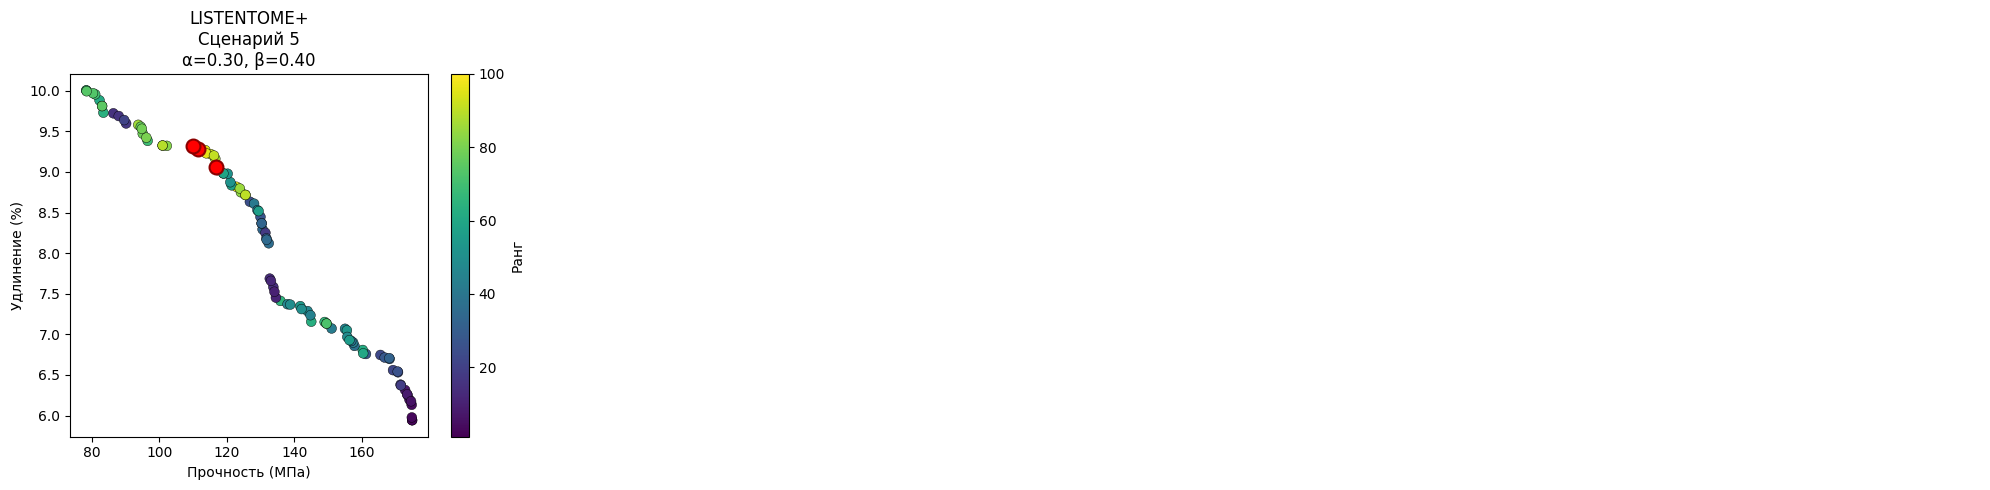

In [ ]:
# ============================================================
# 6.9. LISTENTOME+ — LLM подбирает веса α, β под запрос
# ============================================================
print("\n" + "=" * 70)
print("6.9. LISTENTOME+")
print("=" * 70)

def get_llm_weights(scenario_name, prefs):
    """
    LLM анализирует запрос и подбирает веса α и β.

    Возвращает:
        alpha: вес гиперобъёма (0..1)
        beta: вес штрафов (0..0.5)
    """
    prefs_text = ', '.join([f"{p}→{'min' if d=='minimize' else 'max'}" for p, d in prefs]) if prefs else 'нет'

    prompt = f"""Ты — эксперт-технолог. Проанализируй запрос и определи НА ОСНОВЕ ЭТОГО ЗАПРОСА веса для ранжирования рецептур.

Запрос технолога: {scenario_name}
Мягкие предпочтения: {prefs_text}

Определи два параметра:
• alpha (0..1) — важность оптимизационной ценности (HV).
  Высокий alpha (0.7-0.9) = важнее математическая оптимальность (прочность, удлинение).
  Низкий alpha (0.3-0.5) = важнее технологическая безопасность и отсутствие рисков.
• beta (0..0.5) — важность штрафов за несоответствие пожеланиям.
  Высокий beta (0.2-0.4) = строже соблюдать мягкие предпочтения (экономия, растворители).
  Низкий beta (0.05-0.15) = предпочтения не критичны.

Правила:
• Если запрос про конкретные числа (прочность > 150, удлинение > 7%) → alpha выше (0.7-0.9)
• Если запрос про безопасность/стабильность → alpha ниже (0.3-0.5)
• Если запрос жёстко требует минимизации чего-то (растворителей, пластификаторов) → beta выше (0.2-0.4)
• Если запрос мягкий (хотя бы, примерно, не критично) → beta ниже (0.05-0.15)
• Если предпочтений нет → beta = 0.05
• "золотая середина", "средняя вязкость" → alpha около 0.5, beta низкий

Верни ТОЛЬКО два числа через запятую: alpha, beta
Пример ответа: 0.7, 0.2"""

    try:
        response = get_llm_response(prompt, max_tokens=100, system_role="technologist")
        response_clean = response.strip()

        # Ищем все числа с плавающей точкой
        numbers = re.findall(r'\d+\.\d+', response_clean)

        if len(numbers) >= 2:
            alpha = float(numbers[0])
            beta = float(numbers[1])
        elif len(numbers) >= 1:
            alpha = float(numbers[0])
            beta = 0.15
        else:
            print(f"    ⚠️ Не удалось распарсить: '{response_clean[:100]}'")
            alpha, beta = 0.6, 0.15

        # Ограничиваем диапазоны
        alpha = max(0.1, min(0.9, alpha))
        beta = max(0.0, min(0.5, beta))

        print(f"    Ответ LLM: {response_clean[:100]}")
        return alpha, beta

    except Exception as e:
        print(f"    ⚠️ Ошибка: {e}")
        return 0.6, 0.15


rankings['LISTENTOME+'] = {}

for scenario_id in active_scenario_ids:
    s = SCENARIOS[scenario_id]
    norm = s['norm']

    # LLM подбирает веса под запрос
    alpha, beta = get_llm_weights(s['name'], s['prefs'])

    print(f"\n{'='*50}")
    print(f"Сценарий {scenario_id}: {s['name']}")
    print(f"  LLM подобрала: α={alpha:.2f}, β={beta:.2f}")
    print(f"  (стандартные: α=0.60, β=0.15)")
    print(f"{'='*50}")

    # Score с подобранными LLM весами
    score = alpha * norm['hv_norm'] + (1-alpha) * norm['h_norm'] - beta * norm['p_norm']
    hybrid_ranking_full = np.argsort(score)[::-1]

    # Топ-10 для турнира
    top10 = list(hybrid_ranking_full[:10])

    # Запускаем турнир LISTENTOME
    top10_ranked = listentome_tournament(top10, s['name'], scenario_id,
                                          pareto_df, pareto_llm_texts, h_values, hv_values, norm)

    remaining = [idx for idx in hybrid_ranking_full if idx not in top10_ranked]
    full_ranking = top10_ranked + remaining

    rankings['LISTENTOME+'][scenario_id] = np.array(full_ranking)

    print(f"\n  Топ-3 LISTENTOME+ для сценария {scenario_id}:")
    for i, idx in enumerate(full_ranking[:3]):
        row = pareto_df.iloc[idx]
        print(f"  {i+1}. Точка {idx}: S={row['strength']:.0f}, E={row['elongation']:.2f}, "
              f"h={h_values[idx]:+.3f}, HV={hv_values[idx]:.1f}, "
              f"P={pareto_df[f'P_scenario_{scenario_id}'].iloc[idx]:.3f}")

# Визуализация LISTENTOME+
n_scenarios = len(active_scenario_ids)
n_cols = 4
n_rows = (n_scenarios + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5 * n_rows))
axes = axes.flatten()

for col, scenario_id in enumerate(active_scenario_ids):
    ax = axes[col]
    ranking = rankings['LISTENTOME+'][scenario_id]
    scores = np.zeros(100)
    scores[ranking] = np.arange(100, 0, -1)

    sc = ax.scatter(pareto_df['strength'], pareto_df['elongation'],
                    c=scores, cmap='viridis', s=50, edgecolors='black', linewidth=0.3)
    top3 = ranking[:3]
    ax.scatter(pareto_df.iloc[top3]['strength'], pareto_df.iloc[top3]['elongation'],
               c='red', s=100, marker='o', edgecolors='darkred', linewidth=1.5, zorder=10)
    ax.set_xlabel('Прочность (МПа)')
    ax.set_ylabel('Удлинение (%)')
    ax.set_title(f'LISTENTOME+\nСценарий {scenario_id}\nα={alpha:.2f}, β={beta:.2f}')
    plt.colorbar(sc, ax=ax, label='Ранг')

for col in range(n_scenarios, len(axes)):
    axes[col].axis('off')

plt.tight_layout()
plt.savefig('listentome_plus.png', dpi=150, bbox_inches='tight')
plt.show()

## 6.10. LISTENTOME++ — теннисная сетка на 16 + утешительный финал


6.10. LISTENTOME++

  🎾 ТЕННИСНЫЙ ТУРНИР LISTENTOME++ (16 участников)

  ── 1-й круг (8 матчей) ──
    Матч 1: 50 vs 35 → 50
       💬 50 - Вес загрузки, время смешивания и вязкость на второй стадии соответствуют целевым показателям лучше. Также более высокий гиперобъём указывает на лучшую оптимизационную ценность решения.
    Матч 2: 53 vs 57 → 57
       💬 57 - В рецептуре Б технологические параметры более оптимальны по весу загрузки, вязкости и объему смеси растворителей. HV также выше, что указывает на лучшую математическую оптимизацию.
    Матч 3: 66 vs 87 → 87
       💬 87 - выбрана лучшая рецептура из-за более высокой гиперобъёма и технологической безопасности. Гиперобъём HV = 154.7 указывает на оптимальное решение с точки зрения математической оптимизации, а h(x) = +0.044 показывает, что параметры рецептуры похожи на успешные исторические данные.
    Матч 4: 51 vs 60 → 51
       💬 51

Основные причины:
- Вес загрузки и доли компонентов совпадают, что упрощает производство.
- Вязк

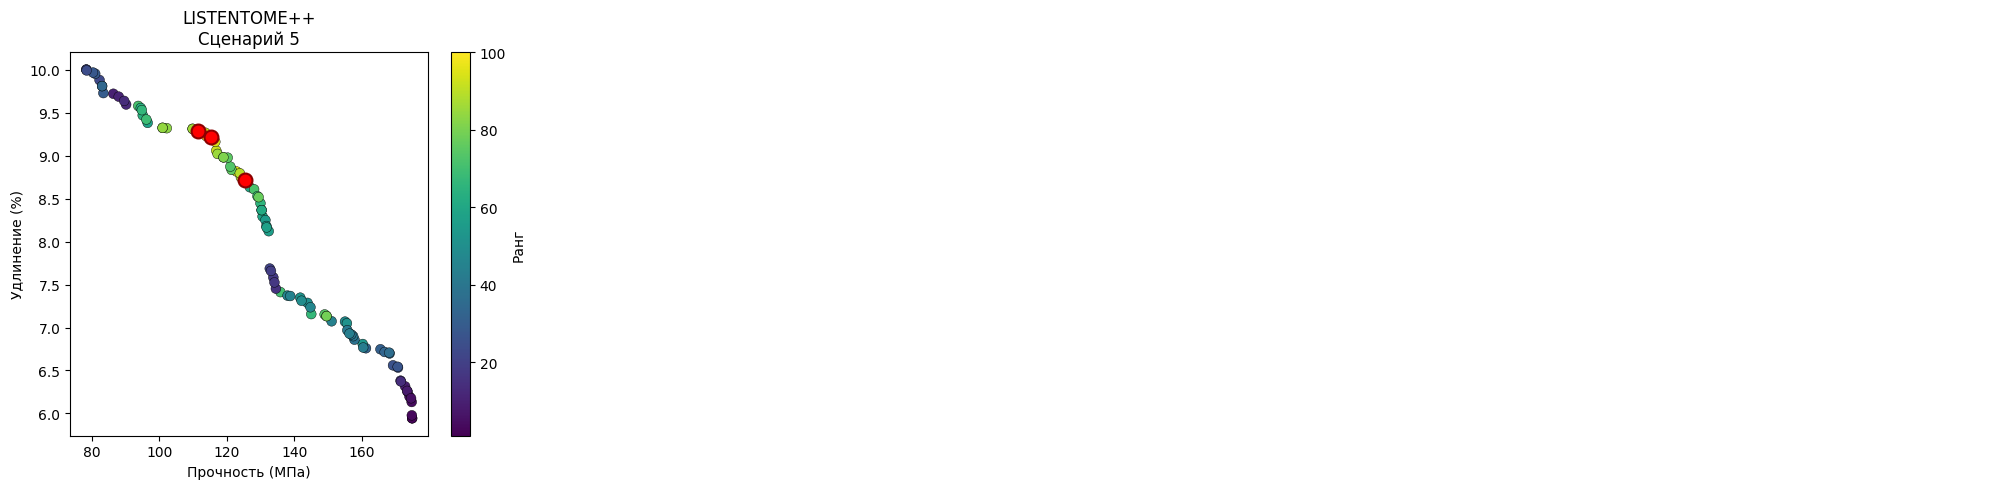

In [ ]:
# ============================================================
# 6.10. LISTENTOME++ — теннисная сетка на 16 + утешительный финал
# ============================================================
print("\n" + "=" * 70)
print("6.10. LISTENTOME++")
print("=" * 70)

def tennis_tournament(top16_indices, scenario_name, scenario_id,
                       pareto_df, pareto_llm_texts, h_values, hv_values, norm):
    """
    Теннисный турнир на 16 участников с утешительным финалом за 3-е место.
    Использует тот же полный промпт, что и LISTENTOME (6.8).
    LLM объясняет каждый выбор.
    """
    N = 16

    bracket = list(top16_indices)
    wins = {idx: 0 for idx in bracket}
    lost_to_champion = []

    print(f"\n  🎾 ТЕННИСНЫЙ ТУРНИР LISTENTOME++ (16 участников)")

    prefs = SCENARIOS[scenario_id]['prefs']
    p_max = pareto_df[f'P_scenario_{scenario_id}'].max()
    hv_max = hv_values.max()
    alpha = 0.6
    beta = 0.15

    def compare_pair(idx_a, idx_b, round_name):
        """Сравнивает пару через LLM с полным промптом. Возвращает (winner_idx, explanation)."""
        row_a = pareto_df.iloc[idx_a]
        row_b = pareto_df.iloc[idx_b]

        h_a = h_values[idx_a]
        h_b = h_values[idx_b]
        hv_a = hv_values[idx_a]
        hv_b = hv_values[idx_b]
        p_a = pareto_df[f'P_scenario_{scenario_id}'].iloc[idx_a]
        p_b = pareto_df[f'P_scenario_{scenario_id}'].iloc[idx_b]

        prompt = f"""Ты — эксперт-технолог производства MLCC-конденсаторов.

Контекст сценария: {scenario_name}

Сравни две рецептуры и выбери лучшую. При решении учитывай:
• Целевые показатели (прочность, удлинение)
• Оптимизационную ценность (HV — гиперобъём)
• Технологическую безопасность (h(x) — сравнение с историей)
• Соответствие пожеланиям (P(x) — штраф)
• НО ГЛАВНОЕ! Сами технологические параметры рецептуры

ГЛАВНЫЙ критерий выбора — САМИ ТЕХНОЛОГИЧЕСКИЕ ПАРАМЕТРЫ рецептуры.
Метрики (HV, h(x), P(x)) используй только как вспомогательные подсказки, а не как основной критерий.

=== РЕЦЕПТУРА А (точка {idx_a}) ===

ТЕХНОЛОГИЧЕСКИЕ ПАРАМЕТРЫ (ОСНОВНОЙ КРИТЕРИЙ):
{pareto_llm_texts[idx_a]}
ЦЕЛЕВЫЕ ПОКАЗАТЕЛИ:
  Прочность: {row_a['strength']:.0f} МПа
  Удлинение: {row_a['elongation']:.2f}%
ГИПЕРОБЪЕМ:
  {describe_HV(hv_a, hv_max)}
ТЕХНОЛОГИЧЕСКАЯ БЕЗОПАСНОСТЬ:
  {describe_h(h_a)}
СООТВЕТСТВИЕ ПОЖЕЛАНИЯМ:
  {describe_P(p_a, prefs, p_max)}

=== РЕЦЕПТУРА Б (точка {idx_b}) ===

ТЕХНОЛОГИЧЕСКИЕ ПАРАМЕТРЫ (ОСНОВНОЙ КРИТЕРИЙ):
{pareto_llm_texts[idx_b]}
ЦЕЛЕВЫЕ ПОКАЗАТЕЛИ:
  Прочность: {row_b['strength']:.0f} МПа
  Удлинение: {row_b['elongation']:.2f}%
ГИПЕРОБЪЕМ:
  {describe_HV(hv_b, hv_max)}
ТЕХНОЛОГИЧЕСКАЯ БЕЗОПАСНОСТЬ:
  {describe_h(h_b)}
СООТВЕТСТВИЕ ПОЖЕЛАНИЯМ:
  {describe_P(p_b, prefs, p_max)}

Ответь СТРОГО в формате (на русском):
{idx_a} или {idx_b} — краткое объяснение своего выбора (перечисли только причины)
"""
        try:
            response = get_llm_response(prompt, max_tokens=200, system_role="technologist")
            response_clean = response.strip()

            # Ищем номер точки
            if str(idx_a) in response_clean and str(idx_b) not in response_clean:
                winner_idx = idx_a
            elif str(idx_b) in response_clean and str(idx_a) not in response_clean:
                winner_idx = idx_b
            else:
                score_a = alpha * norm['hv_norm'][idx_a] + (1-alpha) * norm['h_norm'][idx_a] - beta * norm['p_norm'][idx_a]
                score_b = alpha * norm['hv_norm'][idx_b] + (1-alpha) * norm['h_norm'][idx_b] - beta * norm['p_norm'][idx_b]
                winner_idx = idx_a if score_a > score_b else idx_b

            return winner_idx, response_clean

        except Exception as e:
            score_a = alpha * norm['hv_norm'][idx_a] + (1-alpha) * norm['h_norm'][idx_a] - beta * norm['p_norm'][idx_a]
            score_b = alpha * norm['hv_norm'][idx_b] + (1-alpha) * norm['h_norm'][idx_b] - beta * norm['p_norm'][idx_b]
            winner_idx = idx_a if score_a > score_b else idx_b
            return winner_idx, f"(ошибка API: {str(e)[:50]})"

    # 1-й круг (8 матчей)
    print(f"\n  ── 1-й круг (8 матчей) ──")
    round2 = []
    for i in range(0, 16, 2):
        winner, response = compare_pair(bracket[i], bracket[i+1], "1-й круг")
        wins[winner] += 1
        round2.append(winner)
        print(f"    Матч {i//2+1}: {bracket[i]} vs {bracket[i+1]} → {winner}")
        print(f"       💬 {response}")

    # 2-й круг (4 матча)
    print(f"\n  ── 2-й круг (4 матча) ──")
    round3 = []
    for i in range(0, 8, 2):
        winner, response = compare_pair(round2[i], round2[i+1], "2-й круг")
        wins[winner] += 1
        round3.append(winner)
        print(f"    Матч {i//2+1}: {round2[i]} vs {round2[i+1]} → {winner}")
        print(f"       💬 {response}")

    # 3-й круг (полуфиналы)
    print(f"\n  ── 3-й круг (полуфиналы) ──")
    finalists = []
    for i in range(0, 4, 2):
        winner, response = compare_pair(round3[i], round3[i+1], "полуфинал")
        wins[winner] += 1
        finalists.append(winner)
        loser = round3[i] if winner == round3[i+1] else round3[i+1]
        lost_to_champion.append(loser)
        print(f"    Полуфинал {i//2+1}: {round3[i]} vs {round3[i+1]} → {winner}")
        print(f"       💬 {response}")

    # Финал
    print(f"\n  ── ФИНАЛ ──")
    champion, response = compare_pair(finalists[0], finalists[1], "финал")
    wins[champion] += 1
    runner_up = finalists[0] if champion == finalists[1] else finalists[1]
    lost_to_champion.append(runner_up)
    print(f"    {finalists[0]} vs {finalists[1]} → 🏆 {champion}")
    print(f"       💬 {response}")

    # Утешительный финал за 3-е место
    print(f"\n  ── Утешительный финал (за 3-е место) ──")
    if len(lost_to_champion) >= 2:
        third_place, response = compare_pair(lost_to_champion[-1], lost_to_champion[-2], "за 3-е место")
        wins[third_place] += 1
        print(f"    {lost_to_champion[-1]} vs {lost_to_champion[-2]} → 🥉 {third_place}")
        print(f"       💬 {response}")
    else:
        third_place = lost_to_champion[0] if lost_to_champion else finalists[0]

    # Финальное ранжирование (без дубликатов!)
    final_order = []
    for idx in [champion, runner_up, third_place]:
        if idx not in final_order:
            final_order.append(idx)

    remaining = [idx for idx in bracket if idx not in final_order]
    remaining_sorted = sorted(remaining, key=lambda x: wins[x], reverse=True)
    final_order.extend(remaining_sorted)

    return final_order


rankings['LISTENTOME++'] = {}

for scenario_id in active_scenario_ids:
    s = SCENARIOS[scenario_id]
    norm = s['norm']

    # Гибридный Score для отбора топ-16
    alpha = 0.6
    beta = 0.15
    score = alpha * norm['hv_norm'] + (1-alpha) * norm['h_norm'] - beta * norm['p_norm']
    hybrid_ranking_full = np.argsort(score)[::-1]

    top16 = list(hybrid_ranking_full[:16])

    # Теннисный турнир с полным промптом
    final_order = tennis_tournament(top16, s['name'], scenario_id,
                                     pareto_df, pareto_llm_texts, h_values, hv_values, norm)

    remaining = [idx for idx in hybrid_ranking_full if idx not in final_order]
    full_ranking = final_order + remaining

    rankings['LISTENTOME++'][scenario_id] = np.array(full_ranking)

    print(f"\n  Итоговый топ-3 LISTENTOME++ для сценария {scenario_id}:")
    for i, idx in enumerate(full_ranking[:3]):
        row = pareto_df.iloc[idx]
        print(f"  {i+1}. Точка {idx}: S={row['strength']:.0f}, E={row['elongation']:.2f}, "
              f"h={h_values[idx]:+.3f}, HV={hv_values[idx]:.1f}, "
              f"P={pareto_df[f'P_scenario_{scenario_id}'].iloc[idx]:.3f}")

# Визуализация
n_scenarios = len(active_scenario_ids)
n_cols = 4
n_rows = (n_scenarios + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5 * n_rows))
axes = axes.flatten()

for col, scenario_id in enumerate(active_scenario_ids):
    ax = axes[col]
    ranking = rankings['LISTENTOME++'][scenario_id]
    scores = np.zeros(100)
    scores[ranking] = np.arange(100, 0, -1)

    sc = ax.scatter(pareto_df['strength'], pareto_df['elongation'],
                    c=scores, cmap='viridis', s=50, edgecolors='black', linewidth=0.3)
    top3 = ranking[:3]
    ax.scatter(pareto_df.iloc[top3]['strength'], pareto_df.iloc[top3]['elongation'],
               c='red', s=100, marker='o', edgecolors='darkred', linewidth=1.5, zorder=10)
    ax.set_xlabel('Прочность (МПа)')
    ax.set_ylabel('Удлинение (%)')
    ax.set_title(f'LISTENTOME++\nСценарий {scenario_id}')
    plt.colorbar(sc, ax=ax, label='Ранг')

for col in range(n_scenarios, len(axes)):
    axes[col].axis('off')

plt.tight_layout()
plt.savefig('listentome_plus_plus.png', dpi=150, bbox_inches='tight')
plt.show()

## ФИНАЛЬНЫЙ СПИСОК ВСЕХ МЕТОДОВ

In [ ]:
# ============================================================
# ФИНАЛЬНЫЙ СПИСОК ВСЕХ МЕТОДОВ
# ============================================================
ALL_METHODS = [
    'HV-only',
    'h-only',
    'TOPSIS',
    'VIKOR',
    'PROMETHEE',
    'HV+h+P',
    'HV+h+P+LISTEN-T',
    'LISTENTOME',
    'LISTENTOME+',
    'LISTENTOME++'
]

# Цвета для 10 методов
all_colors = [
    '#e74c3c',  # HV-only — красный
    '#34cddb',  # h-only — голубой
    '#f39c12',  # TOPSIS — оранжевый
    '#9b59b6',  # VIKOR — фиолетовый
    '#1abc9c',  # PROMETHEE — бирюзовый
    '#f1c40f',  # HV+h+P — жёлтый
    '#e66322',  # LISTEN-T — тёмно-оранжевый
    '#12b53b',  # LISTENTOME — зелёный
    '#e84393',  # LISTENTOME+ — розовый
    '#004ede',  # LISTENTOME++ — синий
]

# Контрастные цвета (для визуализации)
all_colors_v2 = [
    '#e41a1c',  # HV-only
    '#377eb8',  # h-only
    '#ff7f00',  # TOPSIS
    '#984ea3',  # VIKOR
    '#4daf4a',  # PROMETHEE
    '#a65628',  # HV+h+P
    '#f781bf',  # LISTEN-T
    '#dede00',  # LISTENTOME
    '#e84393',  # LISTENTOME+
    '#00ced1',  # LISTENTOME++
]

# 7. ВЫЧИСЛЕНИЕ МЕТРИК

   7.1. Функции первичных метрик

   7.2. Функции интегральных метрик
   
   7.3. Функция оценки одного метода на одном сценарии

## 7.1. Функции первичных метрик

In [ ]:
# ============================================================
# 7.1. ФУНКЦИИ ПЕРВИЧНЫХ МЕТРИК (на топ-3)
# ============================================================
print("\n" + "=" * 70)
print("7.1. Первичные метрики")
print("=" * 70)

from sklearn.metrics.pairwise import cosine_similarity, euclidean_distances

def compute_primary_metrics(top3_indices, pareto_df, pareto_vectors,
                             D_good_vectors, D_bad_vectors, scenario_id):
    """
    Вычисляет 8 первичных метрик для топ-3 точек.

    Параметры:
        top3_indices: индексы трёх выбранных точек
        pareto_df: датафрейм Парето-фронта
        pareto_vectors: нормализованные векторы Парето-фронта
        D_good_vectors: векторы успешных исторических рецептов
        D_bad_vectors: векторы неудачных исторических рецептов
        scenario_id: номер сценария (для P(x))

    Возвращает:
        словарь {metric_name: value}
    """
    top3 = [int(idx) for idx in top3_indices[:3]]

    # Значения для трёх точек
    f1_vals = pareto_df.iloc[top3]['strength'].values
    f2_vals = pareto_df.iloc[top3]['elongation'].values
    h_vals = pareto_df.iloc[top3]['h'].values
    hv_vals = pareto_df.iloc[top3]['HV'].values

    # Проверяем наличие колонки P для данного сценария
    p_col = f'P_scenario_{scenario_id}'
    if p_col in pareto_df.columns:
        P_vals = pareto_df.iloc[top3][p_col].values
    else:
        P_vals = np.zeros(3)

    # 1. avg_f1 — средняя прочность
    avg_f1 = f1_vals.mean()

    # 2. avg_f2 — среднее удлинение
    avg_f2 = f2_vals.mean()

    # 3. avg_h — средняя эвристика
    avg_h = h_vals.mean()

    # 4. risk_frac — доля рискованных (h < 0)
    risk_frac = (h_vals < 0).mean()

    # 5. avg_HV — средний гиперобъём
    avg_HV = hv_vals.mean()

    # 6. dist_good — среднее МАНХЭТТЕНСКОЕ расстояние до ближайшей точки из D_good
    top3_vectors = pareto_vectors[top3]
    # Манхэттенские расстояния до всех точек D_good
    manh_to_good = np.zeros((3, len(D_good_vectors)))
    for i in range(3):
        manh_to_good[i] = np.sum(np.abs(D_good_vectors - top3_vectors[i]), axis=1)
    min_dist_good = manh_to_good.min(axis=1)  # минимальное расстояние для каждой точки
    avg_dist_good = min_dist_good.mean()  # среднее по трём точкам

    # 7. diversity — среднее евклидово расстояние между точками в пространстве (f1, f2)
    # Нормализуем f1, f2 для diversity
    f1_norm = (f1_vals - pareto_df['strength'].min()) / (pareto_df['strength'].max() - pareto_df['strength'].min())
    f2_norm = (f2_vals - pareto_df['elongation'].min()) / (pareto_df['elongation'].max() - pareto_df['elongation'].min())
    points_2d = np.column_stack([f1_norm, f2_norm])
    # Попарные расстояния
    dist_01 = np.sqrt(np.sum((points_2d[0] - points_2d[1])**2))
    dist_02 = np.sqrt(np.sum((points_2d[0] - points_2d[2])**2))
    dist_12 = np.sqrt(np.sum((points_2d[1] - points_2d[2])**2))
    diversity = np.mean([dist_01, dist_02, dist_12])

    # 8. compliance — среднее соответствие мягким предпочтениям (1 - P)
    # Нормализуем P относительно максимума по сценарию
    p_max = pareto_df[p_col].max() if p_col in pareto_df.columns else 1.0
    if p_max > 0:
        compliance = (1 - P_vals / p_max).mean()
    else:
        compliance = 1.0

    metrics = {
        'avg_f1': avg_f1,
        'avg_f2': avg_f2,
        'avg_h': avg_h,
        'risk_frac': risk_frac,
        'avg_HV': avg_HV,
        'dist_good': avg_dist_good,
        'diversity': diversity,
        'compliance': compliance,
    }

    return metrics


# ----------------------------------------------------------
# Демонстрация на первом активном сценарии и методе HV+h+P
# ----------------------------------------------------------
demo_scenario_id = active_scenario_ids[0]
demo_method = 'HV+h+P'

print(f"\n--- Демонстрация: {demo_method}, Сценарий {demo_scenario_id} ({SCENARIOS[demo_scenario_id]['name']}) ---")

if demo_method in rankings and demo_scenario_id in rankings[demo_method]:
    demo_top3 = rankings[demo_method][demo_scenario_id][:3]
    demo_metrics = compute_primary_metrics(demo_top3, pareto_df, pareto_vectors,
                                            D_good_vectors, D_bad_vectors, demo_scenario_id)

    print(f"\nТоп-3 точки: {list(demo_top3)}")
    for i, idx in enumerate(demo_top3):
        row = pareto_df.iloc[idx]
        print(f"  {i+1}. Точка {idx}: S={row['strength']:.0f}, E={row['elongation']:.2f}, "
              f"h={row['h']:.3f}, HV={row['HV']:.1f}")

    print(f"\nПервичные метрики:")
    for name, value in demo_metrics.items():
        print(f"  {name:<20} = {value:.4f}")
else:
    print(f"  ⚠️ Метод '{demo_method}' или сценарий {demo_scenario_id} не найдены в rankings")
    print(f"  Доступные методы: {list(rankings.keys())}")
    print(f"  Доступные сценарии для '{demo_method}': {list(rankings.get(demo_method, {}).keys())}")


7.1. Первичные метрики

--- Демонстрация: HV+h+P, Сценарий 5 (Запах растворителей) ---

Топ-3 точки: [np.int64(50), np.int64(35), np.int64(53)]
  1. Точка 50: S=123, E=8.82, h=0.093, HV=151.8
  2. Точка 35: S=117, E=9.06, h=0.115, HV=143.9
  3. Точка 53: S=114, E=9.27, h=0.112, HV=141.5

Первичные метрики:
  avg_f1               = 117.8174
  avg_f2               = 9.0486
  avg_h                = 0.1066
  risk_frac            = 0.0000
  avg_HV               = 145.7058
  dist_good            = 5.1477
  diversity            = 0.0979
  compliance           = 0.3510


## 7.2. Функции интегральных метрик

In [ ]:
# ============================================================
# 7.2. ФУНКЦИИ ИНТЕГРАЛЬНЫХ МЕТРИК (на топ-3)
# ============================================================
print("\n" + "=" * 70)
print("7.2. Интегральные метрики")
print("=" * 70)

def compute_integrated_metrics(top3_indices, pareto_df, pareto_vectors,
                                D_good_vectors, D_bad_vectors, scenario_id,
                                hv_values, quality_threshold=0.80):
    """
    Вычисляет 4 интегральные метрики для топ-3 точек.

    Параметры:
        top3_indices: индексы трёх выбранных точек
        pareto_df: датафрейм Парето-фронта
        pareto_vectors: нормализованные векторы Парето-фронта
        D_good_vectors: векторы успешных исторических рецептов
        D_bad_vectors: векторы неудачных исторических рецептов
        scenario_id: номер сценария
        hv_values: массив гиперобъёмов
        quality_threshold: перцентиль для определения "релевантных" точек

    Возвращает:
        словарь {metric_name: value}
    """
    top3 = [int(idx) for idx in top3_indices[:3]]
    top3_vectors = pareto_vectors[top3]

    # ----------------------------------------------------------
    # 1. Historical F1@3
    # ----------------------------------------------------------
    # "Релевантные" = точки, quality_score > порога
    # quality_score уже есть в hist_df, но для Парето-фронта его нет
    # Используем HV как прокси: топ-30% по HV (мягче, чем 20%)
    hv_threshold = np.percentile(hv_values, 70)  # было 80, стало 70
    relevant_mask = hv_values >= hv_threshold

    # Манхэттенское расстояние до D_good
    all_dist_to_good = np.zeros(len(pareto_vectors))
    for i in range(len(pareto_vectors)):
        all_dist_to_good[i] = np.sum(np.abs(D_good_vectors - pareto_vectors[i]), axis=1).min()

    # Порог "похожести": 50-й перцентиль (медиана) — было 25, стало 50
    dist_threshold = np.percentile(all_dist_to_good, 50)

    top3_dist_to_good = np.zeros(3)
    for i in range(3):
        top3_dist_to_good[i] = np.sum(np.abs(D_good_vectors - top3_vectors[i]), axis=1).min()

    # Precision: доля топ-3, похожих на D_good
    tp = (top3_dist_to_good < dist_threshold).sum()
    precision = tp / 3

    # Recall: сколько релевантных точек попало в топ-3
    relevant_in_top3 = sum(1 for idx in top3 if relevant_mask[idx])
    n_relevant = relevant_mask.sum()
    recall = relevant_in_top3 / min(3, n_relevant) if n_relevant > 0 else 0.0

    if precision + recall > 0:
        historical_f1 = 2 * precision * recall / (precision + recall)
    else:
        historical_f1 = 0.0

    # ----------------------------------------------------------
    # 2. Failure Avoidance
    # ----------------------------------------------------------
    # Манхэттенское расстояние до D_bad
    manh_to_bad = np.zeros(3)
    for i in range(3):
        manh_to_bad[i] = np.sum(np.abs(D_bad_vectors - top3_vectors[i]), axis=1).min()

    # Нормализуем: 1 — полностью избегает, 0 — очень близко к bad
    # Максимальное возможное манхэттенское расстояние = 23 (все параметры в [0,1])
    max_possible_dist = len(all_param_names)  # 23
    failure_avoidance = manh_to_bad.mean() / max_possible_dist
    # Инвертируем: чем дальше от bad, тем лучше
    # Уже хорошо — большое расстояние = хорошая метрика

    # ----------------------------------------------------------
    # 3. Robustness (заглушка — вычисляется в блоке 10)
    # ----------------------------------------------------------
    robustness = None  # будет вычислено в блоке 10

    # ----------------------------------------------------------
    # 4. Coverage (разнообразие в пространстве целей)
    # ----------------------------------------------------------
    f1_vals = pareto_df.iloc[top3]['strength'].values
    f2_vals = pareto_df.iloc[top3]['elongation'].values

    # Нормализуем на диапазон фронта
    f1_range = pareto_df['strength'].max() - pareto_df['strength'].min()
    f2_range = pareto_df['elongation'].max() - pareto_df['elongation'].min()

    f1_norm = (f1_vals - pareto_df['strength'].min()) / f1_range if f1_range > 0 else f1_vals
    f2_norm = (f2_vals - pareto_df['elongation'].min()) / f2_range if f2_range > 0 else f2_vals

    points_2d = np.column_stack([f1_norm, f2_norm])
    dist_01 = np.sqrt(np.sum((points_2d[0] - points_2d[1])**2))
    dist_02 = np.sqrt(np.sum((points_2d[0] - points_2d[2])**2))
    dist_12 = np.sqrt(np.sum((points_2d[1] - points_2d[2])**2))
    coverage = np.mean([dist_01, dist_02, dist_12])

    metrics = {
        'historical_f1@3': historical_f1,
        'failure_avoidance': failure_avoidance,
        'robustness': robustness,
        'coverage': coverage,
    }

    return metrics


# ----------------------------------------------------------
# Демонстрация
# ----------------------------------------------------------
demo_sid = active_scenario_ids[0]
print(f"\n--- Демонстрация: Гибридный метод, Сценарий {demo_sid} ---")
demo_integrated = compute_integrated_metrics(
    rankings['HV+h+P'][demo_sid][:3], pareto_df, pareto_vectors,
    D_good_vectors, D_bad_vectors, demo_sid, hv_values
)

print(f"\nИнтегральные метрики:")
for name, value in demo_integrated.items():
    if value is not None:
        print(f"  {name:<25} = {value:.4f}")
    else:
        print(f"  {name:<25} = (вычисляется в блоке 10)")


7.2. Интегральные метрики

--- Демонстрация: Гибридный метод, Сценарий 5 ---

Интегральные метрики:
  historical_f1@3           = 0.8000
  failure_avoidance         = 0.2114
  robustness                = (вычисляется в блоке 10)
  coverage                  = 0.0979


## 7.3. Функция оценки одного метода на одном сценарии

In [ ]:
# ============================================================
# 7.3. ФУНКЦИЯ ОЦЕНКИ ОДНОГО МЕТОДА НА ОДНОМ СЦЕНАРИИ
# ============================================================
print("\n" + "=" * 70)
print("7.3. Функция оценки метода на сценарии")
print("=" * 70)

def evaluate_method(rankings_dict, method_name, scenario_id,
                    pareto_df, pareto_vectors, D_good_vectors, D_bad_vectors, hv_values):
    """
    Вычисляет все метрики для одного метода на одном сценарии.

    Параметры:
        rankings_dict: словарь rankings[method_name][scenario_id] = массив индексов
        method_name: название метода
        scenario_id: номер сценария
        pareto_df: датафрейм Парето-фронта
        pareto_vectors: нормализованные векторы
        D_good_vectors, D_bad_vectors: векторы исторических данных
        hv_values: массив гиперобъёмов

    Возвращает:
        словарь {metric_name: value}
    """
    # Получаем ранжирование
    ranking = rankings_dict[method_name][scenario_id]
    top3 = ranking[:3]

    # Первичные метрики
    primary = compute_primary_metrics(top3, pareto_df, pareto_vectors,
                                       D_good_vectors, D_bad_vectors, scenario_id)

    # Интегральные метрики
    integrated = compute_integrated_metrics(top3, pareto_df, pareto_vectors,
                                             D_good_vectors, D_bad_vectors, scenario_id, hv_values)

    # Объединяем
    all_metrics = {**primary, **integrated}

    return all_metrics


# ----------------------------------------------------------
# Демонстрация для активного сценария
# ----------------------------------------------------------
demo_sid = active_scenario_ids[0]
print(f"\n{'='*70}")
print(f"ДЕМОНСТРАЦИЯ: ВСЕ МЕТОДЫ — СЦЕНАРИЙ {demo_sid} ({SCENARIOS[demo_sid]['name']})")
print(f"{'='*70}")

# Используем финальный список методов
method_names = ALL_METHODS

# Собираем метрики для всех методов
all_metrics_demo = {}
for method in method_names:
    if method in rankings and demo_sid in rankings[method]:
        metrics = evaluate_method(rankings, method, demo_sid, pareto_df, pareto_vectors,
                                   D_good_vectors, D_bad_vectors, hv_values)
        all_metrics_demo[method] = metrics
    else:
        print(f"  ⚠️ Метод '{method}' не найден для сценария {demo_sid}")

# Вывод таблицы
metric_keys = list(all_metrics_demo[list(all_metrics_demo.keys())[0]].keys())
# Короткие названия для заголовков
short_names = {
    'avg_f1': 'f1↑', 'avg_f2': 'f2↑', 'avg_h': 'h↑', 'risk_frac': 'risk↓',
    'avg_HV': 'HV↑', 'dist_good': 'dist↓', 'diversity': 'div↑', 'compliance': 'cmpl↑',
    'historical_f1@3': 'F1↑', 'failure_avoidance': 'fail_av↑', 'robustness': 'robust↑', 'coverage': 'cov↑'
}

print(f"\n{'Метод':<22}", end='')
for key in metric_keys:
    print(f"{short_names.get(key, key):>8}", end=' ')
print()
print(f"{'-'*22}{'-'*len(metric_keys)*9}")

for method in all_metrics_demo:
    print(f"{method:<22}", end='')
    for key in metric_keys:
        val = all_metrics_demo[method][key]
        if val is not None:
            print(f"{val:8.4f}", end=' ')
        else:
            print(f"{'—':>8}", end=' ')
    print()


7.3. Функция оценки метода на сценарии

ДЕМОНСТРАЦИЯ: ВСЕ МЕТОДЫ — СЦЕНАРИЙ 5 (Запах растворителей)

Метод                      f1↑      f2↑       h↑    risk↓      HV↑    dist↓     div↑    cmpl↑      F1↑ fail_av↑  robust↑     cov↑ 
----------------------------------------------------------------------------------------------------------------------------------
HV-only               128.8858   8.5521  -0.4356   1.0000 155.5396   5.8090   0.0177   0.3161   0.0000   0.2318        —   0.0177 
h-only                 91.9184   9.6545   0.1202   0.0000  66.9287   4.7161   0.2795   0.2964   0.4444   0.1937        —   0.2795 
TOPSIS                124.6576   8.7504   0.0601   0.0000 153.7409   5.2180   0.0247   0.2965   0.8000   0.2097        —   0.0247 
VIKOR                 124.6576   8.7504   0.0601   0.0000 153.7409   5.2180   0.0247   0.2965   0.8000   0.2097        —   0.0247 
PROMETHEE             121.7752   8.8649   0.0838   0.0000 150.1228   5.1616   0.0822   0.3203   0.8000   0.2096 

# 8. ЭКСПЕРИМЕНТ 1: СРАВНЕНИЕ ВСЕХ МЕТОДОВ

   8.1. Прогон всех методов на всех активных сценариях
   
   8.2. Таблица первичных метрик (среднее ± std)

   8.3. Таблица интегральных метрик (среднее ± std)


8. ЭКСПЕРИМЕНТ 1: СРАВНЕНИЕ ВСЕХ МЕТОДОВ

8.1. Прогон всех методов по всем сценариям...
✅ Прогон завершён.

8.2. ПЕРВИЧНЫЕ МЕТРИКИ (среднее ± std по всем сценариям)

Метод                            f1↑           f2↑            h↑         risk↓           HV↑         dist↓          div↑         cmpl↑
--------------------------------------------------------------------------------------------------------------------------------------
HV-only                   128.89          8.55         -0.44          1.00        155.54          5.81          0.02          0.32    
h-only                     91.92          9.65          0.12          0.00         66.93          4.72          0.28          0.30    
TOPSIS                    124.66          8.75          0.06          0.00        153.74          5.22          0.02          0.30    
VIKOR                     124.66          8.75          0.06          0.00        153.74          5.22          0.02          0.30    
PROMETHEE              

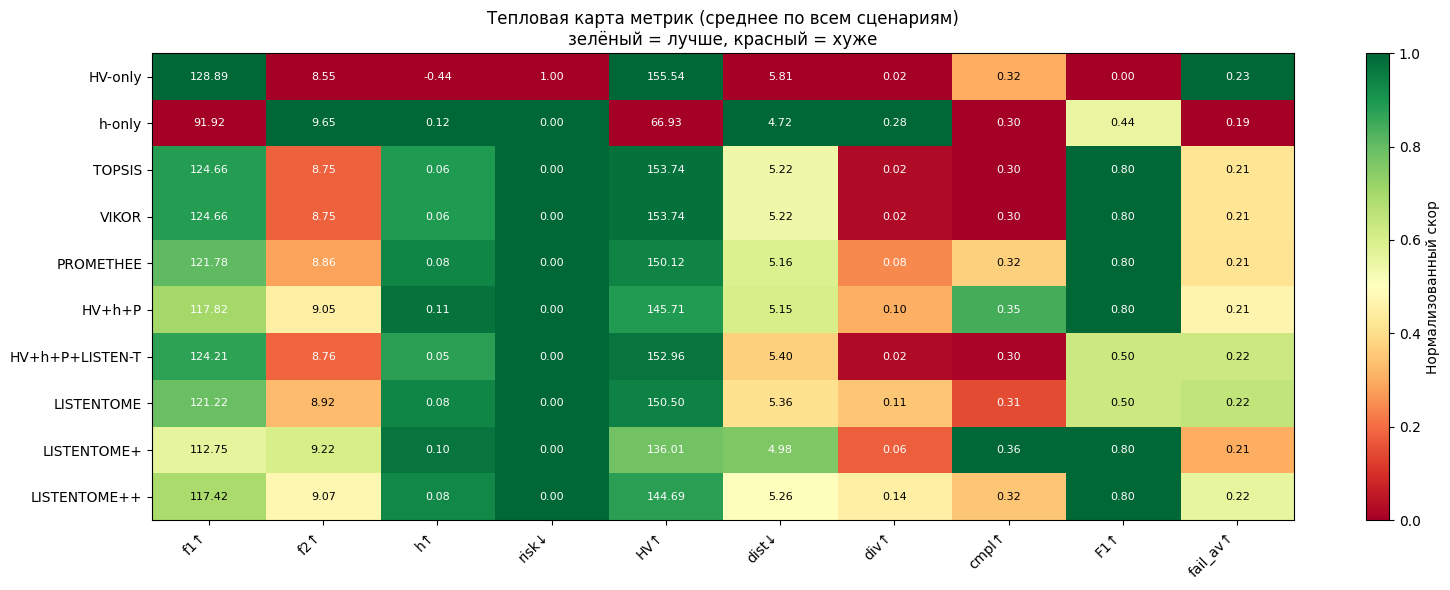

In [ ]:
# ============================================================
# 8. ЭКСПЕРИМЕНТ 1: СРАВНЕНИЕ ВСЕХ МЕТОДОВ
# ============================================================
print("\n" + "=" * 70)
print("8. ЭКСПЕРИМЕНТ 1: СРАВНЕНИЕ ВСЕХ МЕТОДОВ")
print("=" * 70)

# ----------------------------------------------------------
# 8.1. Прогон всех методов по всем сценариям
# ----------------------------------------------------------
print("\n8.1. Прогон всех методов по всем сценариям...")

# Используем финальный список методов
method_names = ALL_METHODS

# Собираем все метрики: results[method][scenario] = словарь метрик
all_results = {}

for method in method_names:
    all_results[method] = {}
    for scenario_id in active_scenario_ids:
        metrics = evaluate_method(rankings, method, scenario_id, pareto_df, pareto_vectors,
                                   D_good_vectors, D_bad_vectors, hv_values)
        all_results[method][scenario_id] = metrics

print("✅ Прогон завершён.")

# ----------------------------------------------------------
# 8.2. Таблица первичных метрик (среднее ± std)
# ----------------------------------------------------------
print("\n" + "=" * 70)
print("8.2. ПЕРВИЧНЫЕ МЕТРИКИ (среднее ± std по всем сценариям)")
print("=" * 70)

primary_metrics_names = ['avg_f1', 'avg_f2', 'avg_h', 'risk_frac', 'avg_HV', 'dist_good', 'diversity', 'compliance']
primary_short = ['f1↑', 'f2↑', 'h↑', 'risk↓', 'HV↑', 'dist↓', 'div↑', 'cmpl↑']

# Заголовок
print(f"\n{'Метод':<22}", end='')
for name in primary_short:
    print(f"{name:>14}", end='')
print()

print(f"{'-'*22}{'-'*len(primary_short)*14}")

for method in method_names:
    print(f"{method:<22}", end='')
    for key in primary_metrics_names:
        vals = [all_results[method][s][key] for s in active_scenario_ids]
        mean_val = np.mean(vals)
        std_val = np.std(vals)
        if std_val < 0.01:
            print(f"{mean_val:>10.2f}{'':>4}", end='')
        else:
            print(f"{mean_val:>8.2f}±{std_val:.2f}", end='')
    print()

# ----------------------------------------------------------
# 8.3. Таблица интегральных метрик (среднее ± std)
# ----------------------------------------------------------
print("\n" + "=" * 70)
print("8.3. ИНТЕГРАЛЬНЫЕ МЕТРИКИ (среднее ± std по всем сценариям)")
print("=" * 70)

integrated_metrics_names = ['historical_f1@3', 'failure_avoidance', 'coverage']
integrated_short = ['F1↑', 'fail_av↑', 'cov↑']

# Заголовок
print(f"\n{'Метод':<22}", end='')
for name in integrated_short:
    print(f"{name:>14}", end='')
print()

print(f"{'-'*22}{'-'*len(integrated_short)*14}")

for method in method_names:
    print(f"{method:<22}", end='')
    for key in integrated_metrics_names:
        vals = [all_results[method][s][key] for s in active_scenario_ids if all_results[method][s][key] is not None]
        if len(vals) > 0:
            mean_val = np.mean(vals)
            std_val = np.std(vals)
            if std_val < 0.01:
                print(f"{mean_val:>10.2f}{'':>4}", end='')
            else:
                print(f"{mean_val:>8.2f}±{std_val:.2f}", end='')
        else:
            print(f"{'—':>14}", end='')
    print()

# ----------------------------------------------------------
# Визуализация: тепловая карта
# ----------------------------------------------------------
print("\n" + "=" * 70)
print("ВИЗУАЛИЗАЦИЯ: ТЕПЛОВАЯ КАРТА МЕТРИК")
print("=" * 70)

# Собираем средние значения для heatmap
all_metric_names = primary_metrics_names + integrated_metrics_names[:-1]  # без robustness
all_short_names = primary_short + integrated_short[:-1]

heatmap_data = np.zeros((len(method_names), len(all_metric_names)))

for i, method in enumerate(method_names):
    for j, key in enumerate(all_metric_names):
        vals = [all_results[method][s][key] for s in active_scenario_ids if all_results[method][s][key] is not None]
        if len(vals) > 0:
            heatmap_data[i, j] = np.mean(vals)

# Нормализуем для heatmap (по столбцам)
heatmap_norm = np.zeros_like(heatmap_data)
for j in range(len(all_metric_names)):
    col = heatmap_data[:, j]
    col_min, col_max = col.min(), col.max()
    if col_max > col_min:
        # Для метрик, где "меньше = лучше" — инвертируем
        if all_metric_names[j] in ['risk_frac', 'dist_good']:
            heatmap_norm[:, j] = (col_max - col) / (col_max - col_min)
        else:
            heatmap_norm[:, j] = (col - col_min) / (col_max - col_min)
    else:
        heatmap_norm[:, j] = 0.5

fig, ax = plt.subplots(figsize=(16, 6))
im = ax.imshow(heatmap_norm, cmap='RdYlGn', aspect='auto', vmin=0, vmax=1)

ax.set_xticks(range(len(all_short_names)))
ax.set_xticklabels(all_short_names, fontsize=10, rotation=45, ha='right')
ax.set_yticks(range(len(method_names)))
ax.set_yticklabels(method_names, fontsize=10)

# Добавляем значения в ячейки
for i in range(len(method_names)):
    for j in range(len(all_metric_names)):
        val = heatmap_data[i, j]
        text_color = 'white' if heatmap_norm[i, j] < 0.3 or heatmap_norm[i, j] > 0.7 else 'black'
        ax.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=8, color=text_color)

ax.set_title('Тепловая карта метрик (среднее по всем сценариям)\nзелёный = лучше, красный = хуже', fontsize=12)
plt.colorbar(im, ax=ax, label='Нормализованный скор')
plt.tight_layout()
plt.savefig('experiment1_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# 9. ЭКСПЕРИМЕНТ 2: АБЛЯЦИОННЫЙ АНАЛИЗ

   9.1. Варианты: HV-only, HV+h, HV+h+P, Полный
   
   9.2. Таблица метрик по вариантам


9. ЭКСПЕРИМЕНТ 2: АБЛЯЦИОННЫЙ АНАЛИЗ

9.1. Варианты гибридного метода

9.2. ТАБЛИЦА МЕТРИК (АБЛЯЦИОННЫЙ АНАЛИЗ)

Метод                                     f1↑       f2↑        h↑     risk↓       HV↑     dist↓      div↑     cmpl↑       F1↑  fail_av↑      cov↑
-------------------------------------------------------------------------------------------------------------------------------------------------
HV-only (только гиперобъём)          128.89     8.55    -0.44     1.00   155.54     5.81     0.02     0.32     0.00     0.23     0.02 
HV + h (гиперобъём + эвристика)      121.55     8.91     0.08     0.00   151.38     5.32     0.10     0.29     0.50     0.22     0.10 
HV + h + P (полный гибрид)           117.82     9.05     0.11     0.00   145.71     5.15     0.10     0.35     0.80     0.21     0.10 
LISTEN-T (LLM-турнир)                124.21     8.76     0.05     0.00   152.96     5.40     0.02     0.30     0.50     0.22     0.02 
LISTENTOME (LLM с h/P/HV)            121.22     8.92  

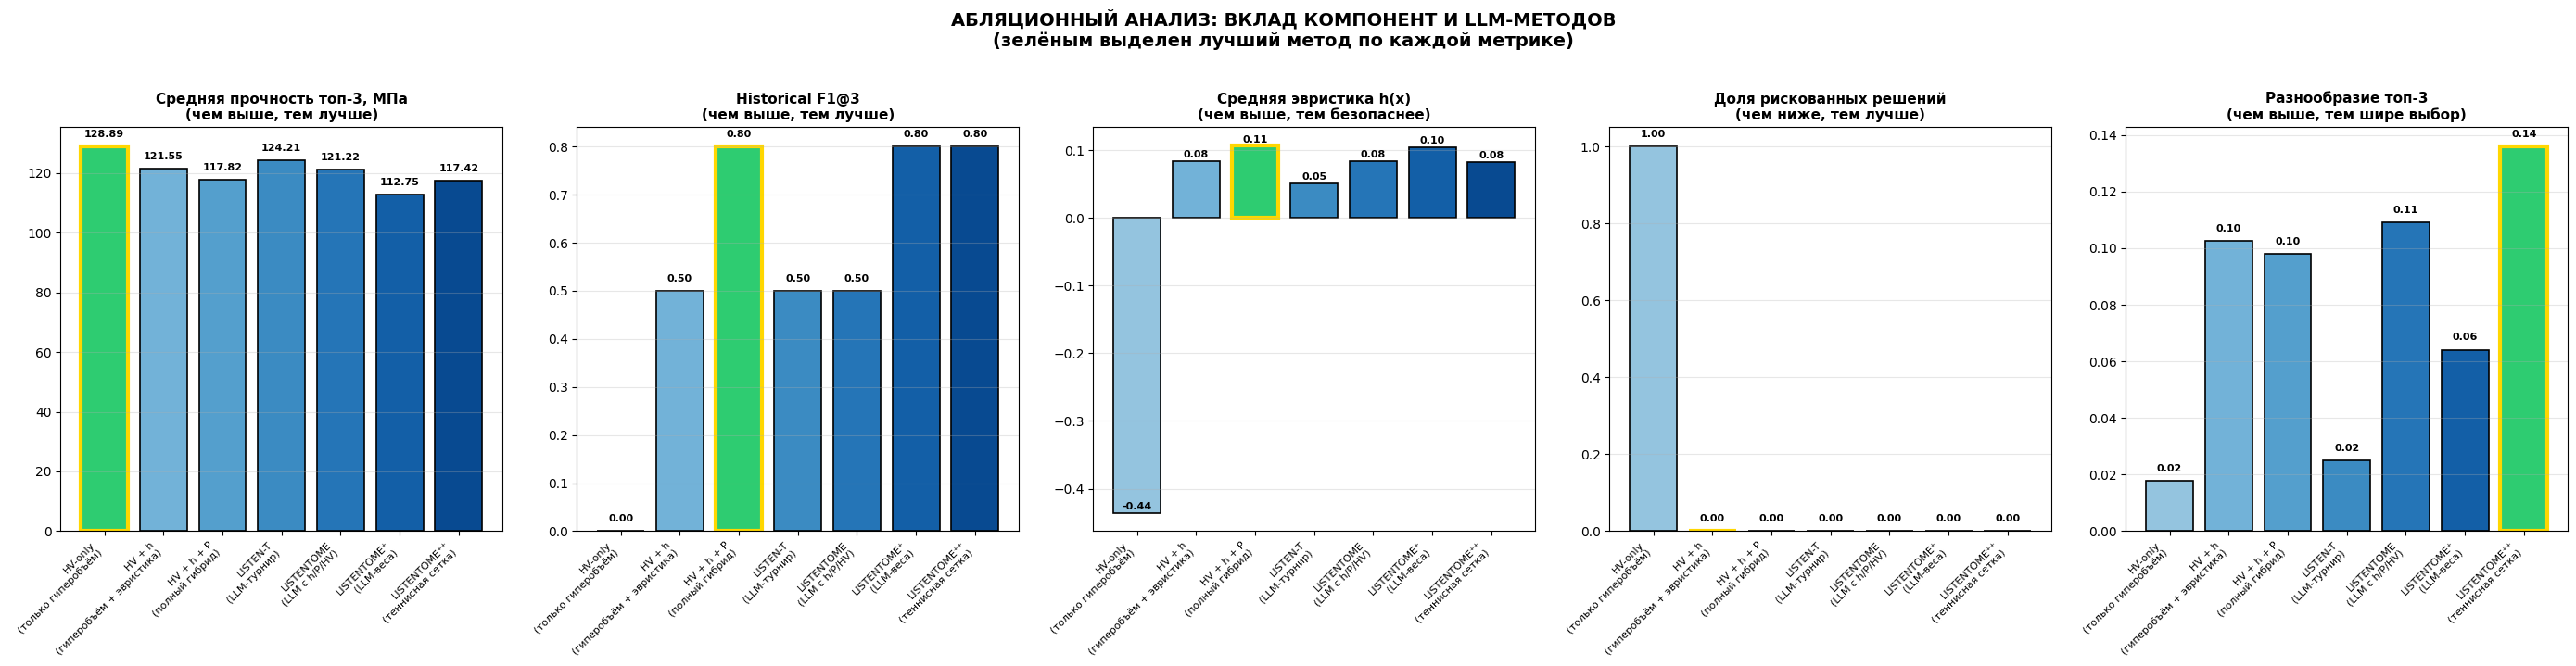


ТЕПЛОВАЯ КАРТА: АБЛЯЦИОННЫЙ АНАЛИЗ


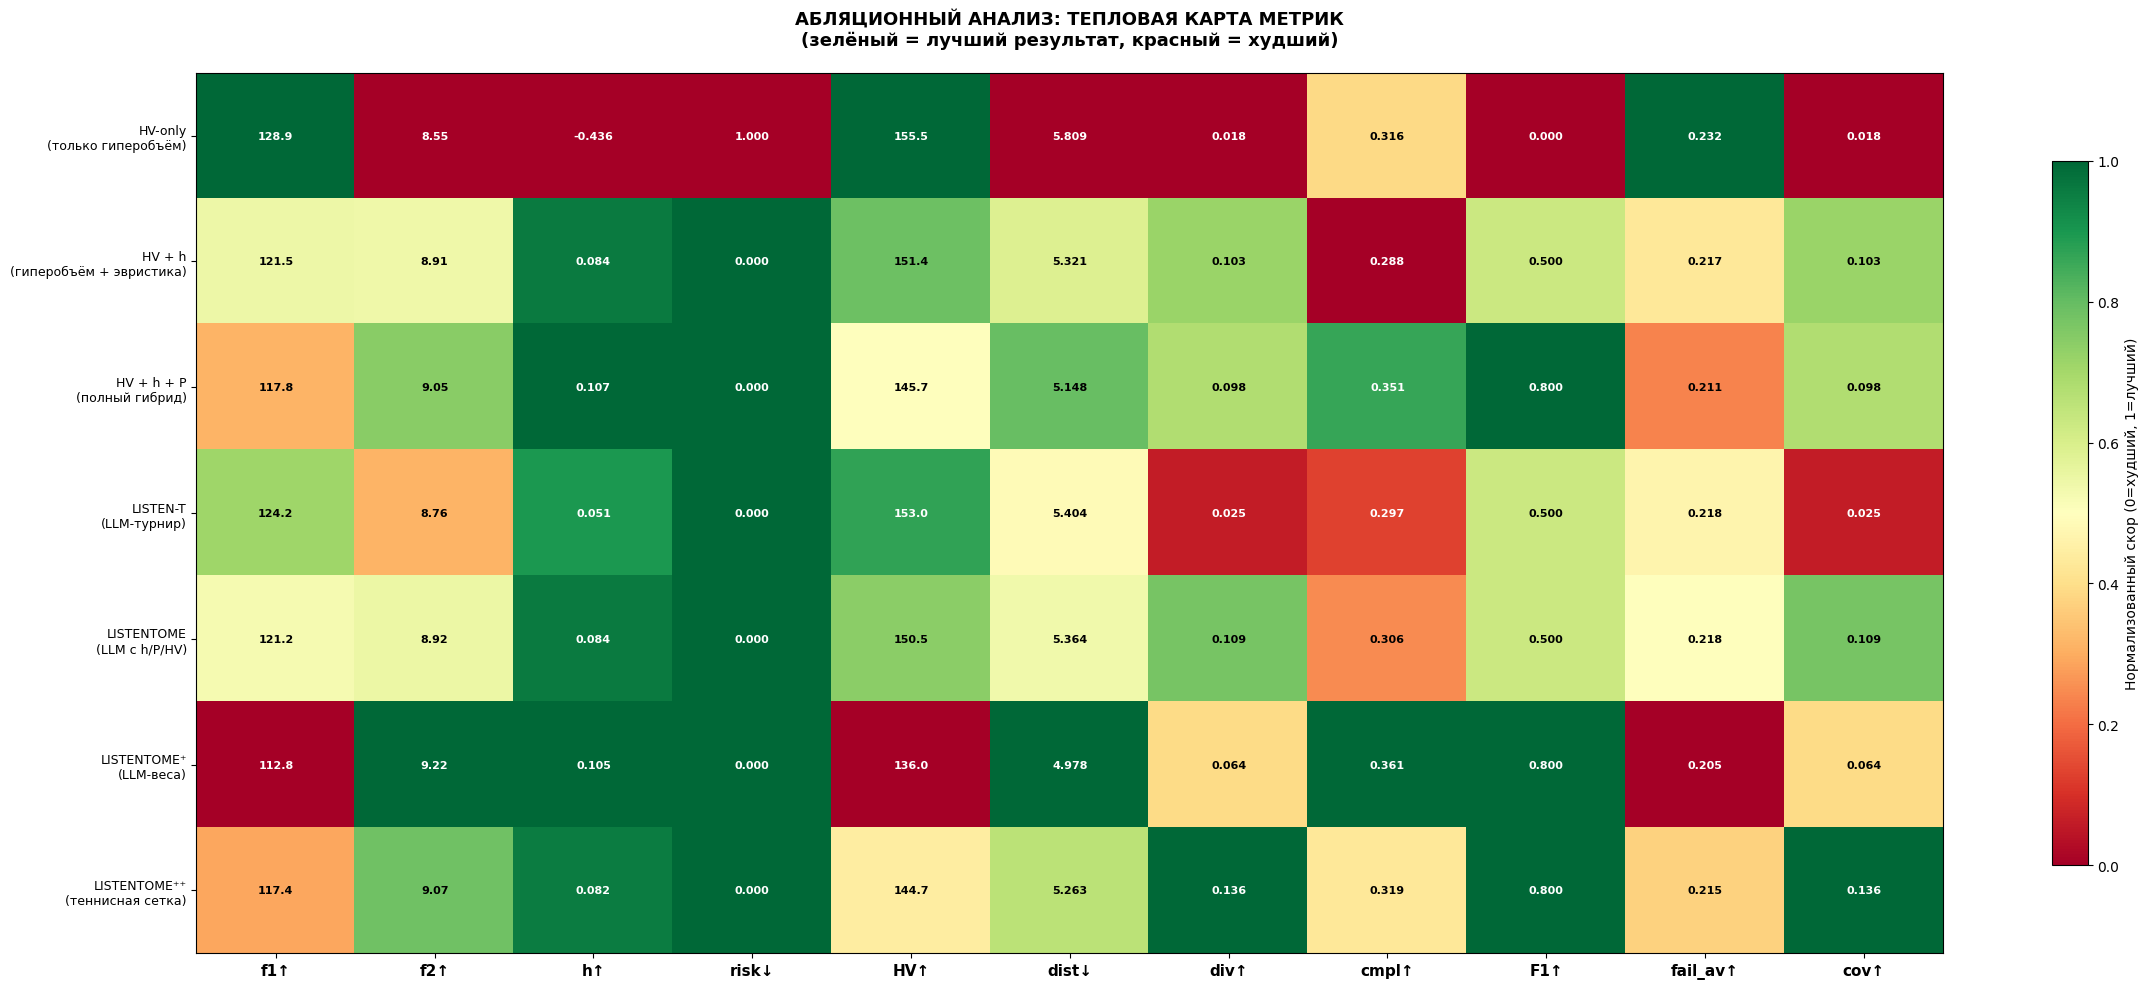


РАДАРНАЯ ДИАГРАММА: СРАВНЕНИЕ ТОП-3 МЕТОДОВ

Топ-3 метода по интегральной оценке:
  1. HV-only
(только гиперобъём) (score=288.32)
  2. LISTEN-T
(LLM-турнир) (score=283.64)
  3. HV + h
(гиперобъём + эвристика) (score=279.81)


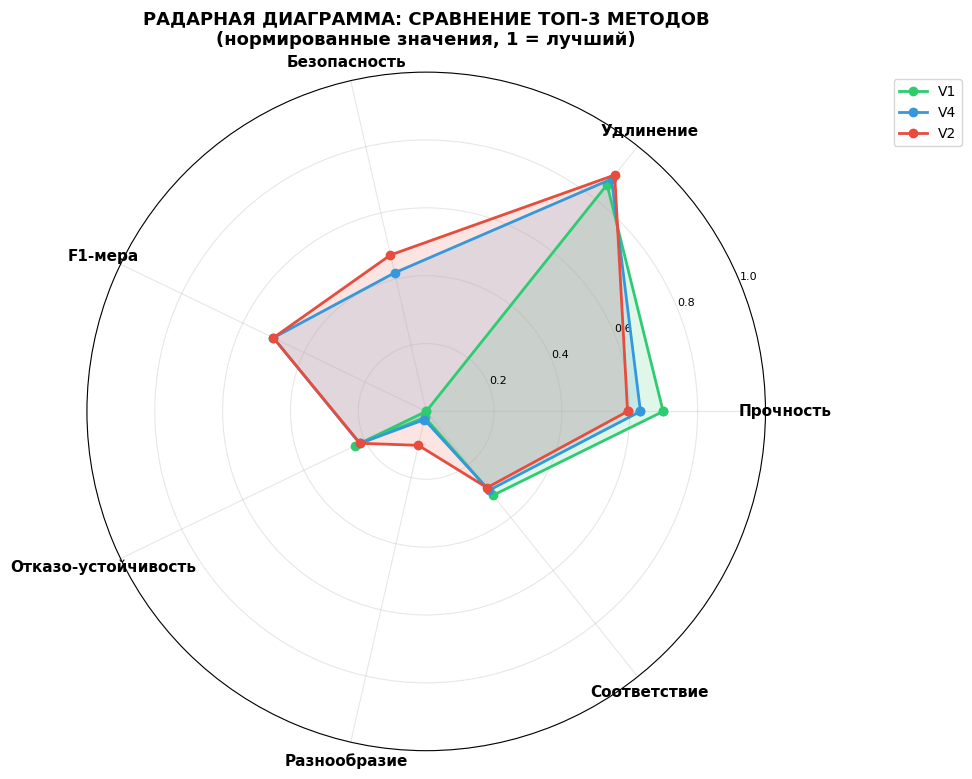

   Сохранённые файлы:
   - ablation_analysis_full_names.png (столбчатые диаграммы)
   - ablation_heatmap_full_names.png (тепловая карта)
   - radar_chart_top3_methods.png (радарная диаграмма)


In [ ]:
# ============================================================
# 9. ЭКСПЕРИМЕНТ 2: АБЛЯЦИОННЫЙ АНАЛИЗ
# ============================================================
print("\n" + "=" * 70)
print("9. ЭКСПЕРИМЕНТ 2: АБЛЯЦИОННЫЙ АНАЛИЗ")
print("=" * 70)

# ----------------------------------------------------------
# 9.1. Варианты гибридного метода
# ----------------------------------------------------------
print("\n9.1. Варианты гибридного метода")

alpha = 0.6
beta = 0.15

# Полные названия для отображения на графиках и в таблицах
ablations = {
    'HV-only': {
        'display_name': 'HV-only\n(только гиперобъём)',
        'short_name': 'V1',
        'use_h': False, 'use_P': False, 'use_LLM': False,
        'description': 'Только гиперобъём'
    },
    'HV + h': {
        'display_name': 'HV + h\n(гиперобъём + эвристика)',
        'short_name': 'V2',
        'use_h': True, 'use_P': False, 'use_LLM': False,
        'description': 'Гиперобъём + эвристика безопасности'
    },
    'HV + h + P': {
        'display_name': 'HV + h + P\n(полный гибрид)',
        'short_name': 'V3',
        'use_h': True, 'use_P': True, 'use_LLM': False,
        'description': 'Гибридный метод (все три компоненты)'
    },
    'HV + h + P + LISTEN-T': {
        'display_name': 'LISTEN-T\n(LLM-турнир)',
        'short_name': 'V4',
        'use_h': True, 'use_P': True, 'use_LLM': True, 'llm_method': 'HV+h+P+LISTEN-T',
        'description': 'Гибридный + LLM-турнир (без h/P в промпте)'
    },
    'LISTENTOME': {
        'display_name': 'LISTENTOME\n(LLM с h/P/HV)',
        'short_name': 'V5',
        'use_h': True, 'use_P': True, 'use_LLM': True, 'llm_method': 'LISTENTOME',
        'description': 'LISTENTOME (с h/P/HV в промпте)'
    },
    'LISTENTOME+': {
        'display_name': 'LISTENTOME⁺\n(LLM-веса)',
        'short_name': 'V6',
        'use_h': True, 'use_P': True, 'use_LLM': True, 'llm_method': 'LISTENTOME+',
        'description': 'LISTENTOME+ (LLM подбирает веса)'
    },
    'LISTENTOME⁺⁺': {
        'display_name': 'LISTENTOME⁺⁺\n(теннисная сетка)',
        'short_name': 'V7',
        'use_h': True, 'use_P': True, 'use_LLM': True, 'llm_method': 'LISTENTOME++',
        'description': 'LISTENTOME++ (теннисная сетка на 16)'
    },
}

abl_results = {}

for abl_key, params in ablations.items():
    abl_results[abl_key] = {}

    for scenario_id in active_scenario_ids:
        s = SCENARIOS[scenario_id]
        norm = s['norm']

        if params['use_LLM']:
            # Берём готовое ранжирование из словаря rankings
            llm_method = params['llm_method']
            if llm_method in rankings:
                ranking = rankings[llm_method][scenario_id]
            else:
                # Fallback: используем гибридный Score
                score = alpha * norm['hv_norm'] + (1-alpha) * norm['h_norm']
                if params['use_P']:
                    score -= beta * norm['p_norm']
                ranking = np.argsort(score)[::-1]
                print(f"⚠️ {llm_method} не найден, использую гибридный Score")
        else:
            # Без LLM: гибридный Score
            if params['use_h']:
                score = alpha * norm['hv_norm'] + (1-alpha) * norm['h_norm']
            else:
                score = norm['hv_norm']

            if params['use_P']:
                score -= beta * norm['p_norm']

            ranking = np.argsort(score)[::-1]

        top3 = ranking[:3]

        metrics = compute_primary_metrics(top3, pareto_df, pareto_vectors,
                                           D_good_vectors, D_bad_vectors, scenario_id)
        integrated = compute_integrated_metrics(top3, pareto_df, pareto_vectors,
                                                 D_good_vectors, D_bad_vectors, scenario_id, hv_values)
        abl_results[abl_key][scenario_id] = {**metrics, **integrated}

# ----------------------------------------------------------
# 9.2. Таблица метрик
# ----------------------------------------------------------
print("\n" + "=" * 70)
print("9.2. ТАБЛИЦА МЕТРИК (АБЛЯЦИОННЫЙ АНАЛИЗ)")
print("=" * 70)

all_metric_keys = ['avg_f1', 'avg_f2', 'avg_h', 'risk_frac', 'avg_HV',
                   'dist_good', 'diversity', 'compliance', 'historical_f1@3', 'failure_avoidance', 'coverage']
all_short = ['f1↑', 'f2↑', 'h↑', 'risk↓', 'HV↑', 'dist↓', 'div↑', 'cmpl↑', 'F1↑', 'fail_av↑', 'cov↑']

# Заголовок
print(f"\n{'Метод':<35}", end='')
for name in all_short:
    print(f"{name:>10}", end='')
print()
print(f"{'-'*35}{'-'*len(all_short)*10}")

for abl_key, params in ablations.items():
    print(f"{params['display_name'].replace(chr(10), ' '):<35}", end='')  # убираем перенос строки
    for key in all_metric_keys:
        vals = [abl_results[abl_key][s][key] for s in active_scenario_ids if abl_results[abl_key][s][key] is not None]
        if len(vals) > 0:
            mean_val = np.mean(vals)
            std_val = np.std(vals)
            if std_val < 0.01:
                print(f"{mean_val:>8.2f} ", end='')
            else:
                print(f"{mean_val:>6.2f}±{std_val:.2f}", end='')
        else:
            print(f"{'—':>10}", end='')
    print()

# ----------------------------------------------------------
# ВИЗУАЛИЗАЦИЯ 1: Сравнение 5 ключевых метрик
# ----------------------------------------------------------
fig, axes = plt.subplots(1, 5, figsize=(28, 7))

metrics_to_plot = ['avg_f1', 'historical_f1@3', 'avg_h', 'risk_frac', 'diversity']
titles = [
    'Средняя прочность топ-3, МПа\n(чем выше, тем лучше)',
    'Historical F1@3\n(чем выше, тем лучше)',
    'Средняя эвристика h(x)\n(чем выше, тем безопаснее)',
    'Доля рискованных решений\n(чем ниже, тем лучше)',
    'Разнообразие топ-3\n(чем выше, тем шире выбор)'
]
better_up = [True, True, True, False, True]

x = np.arange(len(ablations))
abl_keys = list(ablations.keys())
abl_display_names = [ablations[k]['display_name'] for k in abl_keys]
abl_short_names = [ablations[k]['short_name'] for k in abl_keys]

for col, (metric, title, up) in enumerate(zip(metrics_to_plot, titles, better_up)):
    ax = axes[col]
    values = []
    for abl_key in abl_keys:
        vals = [abl_results[abl_key][s][metric] for s in active_scenario_ids if abl_results[abl_key][s][metric] is not None]
        values.append(np.mean(vals) if vals else 0)

    values = np.array(values)

    # Цвета: градиент от синего к зелёному
    colors = plt.cm.Blues(np.linspace(0.4, 0.9, len(ablations)))

    bars = ax.bar(x, values, color=colors, edgecolor='black', linewidth=1.2)

    # Выделяем лучший вариант
    if not up:
        best_idx = np.argmin(values)
    else:
        best_idx = np.argmax(values)

    bars[best_idx].set_color('#2ecc71')  # ярко-зелёный для лучшего
    bars[best_idx].set_edgecolor('gold')
    bars[best_idx].set_linewidth(3)

    # Подписи осей
    ax.set_xticks(x)
    ax.set_xticklabels(abl_display_names, fontsize=8, rotation=45, ha='right')
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')

    # Добавляем значения
    for i, v in enumerate(values):
        ax.text(i, v + max(values)*0.02, f'{v:.2f}',
                ha='center', va='bottom', fontsize=8, fontweight='bold')

plt.suptitle('АБЛЯЦИОННЫЙ АНАЛИЗ: ВКЛАД КОМПОНЕНТ И LLM-МЕТОДОВ\n(зелёным выделен лучший метод по каждой метрике)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('ablation_analysis_full_names.png', dpi=150, bbox_inches='tight')
plt.show()

# ----------------------------------------------------------
# ВИЗУАЛИЗАЦИЯ 2: Тепловая карта
# ----------------------------------------------------------
print("\n" + "=" * 70)
print("ТЕПЛОВАЯ КАРТА: АБЛЯЦИОННЫЙ АНАЛИЗ")
print("=" * 70)

# Собираем данные
heatmap_abl = np.zeros((len(ablations), len(all_metric_keys)))
for i, abl_key in enumerate(abl_keys):
    for j, key in enumerate(all_metric_keys):
        vals = [abl_results[abl_key][s][key] for s in active_scenario_ids if abl_results[abl_key][s][key] is not None]
        heatmap_abl[i, j] = np.mean(vals) if vals else 0

# Нормализация
heatmap_abl_norm = np.zeros_like(heatmap_abl)
for j in range(len(all_metric_keys)):
    col = heatmap_abl[:, j]
    col_min, col_max = col.min(), col.max()
    if col_max > col_min:
        if all_metric_keys[j] in ['risk_frac', 'dist_good']:
            heatmap_abl_norm[:, j] = (col_max - col) / (col_max - col_min)
        else:
            heatmap_abl_norm[:, j] = (col - col_min) / (col_max - col_min)
    else:
        heatmap_abl_norm[:, j] = 0.5

fig, ax = plt.subplots(figsize=(24, 10))
im = ax.imshow(heatmap_abl_norm, cmap='RdYlGn', aspect='auto', vmin=0, vmax=1)

# Настройка осей с полными названиями
ax.set_xticks(range(len(all_short)))
ax.set_xticklabels(all_short, fontsize=11, fontweight='bold')
ax.set_yticks(range(len(ablations)))
ax.set_yticklabels(abl_display_names, fontsize=9)

# Добавляем значения
for i in range(len(ablations)):
    for j in range(len(all_metric_keys)):
        val = heatmap_abl[i, j]
        norm_val = heatmap_abl_norm[i, j]
        text_color = 'white' if norm_val < 0.2 or norm_val > 0.8 else 'black'

        if all_metric_keys[j] in ['avg_f1', 'avg_HV']:
            text = f'{val:.1f}'
        elif all_metric_keys[j] == 'avg_f2':
            text = f'{val:.2f}'
        else:
            text = f'{val:.3f}'

        ax.text(j, i, text, ha='center', va='center', fontsize=8, color=text_color, fontweight='bold')

# Заголовок и цветовая шкала
ax.set_title('АБЛЯЦИОННЫЙ АНАЛИЗ: ТЕПЛОВАЯ КАРТА МЕТРИК\n(зелёный = лучший результат, красный = худший)',
             fontsize=13, fontweight='bold', pad=20)
cbar = plt.colorbar(im, ax=ax, label='Нормализованный скор (0=худший, 1=лучший)', shrink=0.8)
cbar.ax.tick_params(labelsize=10)

plt.tight_layout()
plt.savefig('ablation_heatmap_full_names.png', dpi=150, bbox_inches='tight')
plt.show()

# ----------------------------------------------------------
# ВИЗУАЛИЗАЦИЯ 3: Радарная диаграмма для лучших методов
# ----------------------------------------------------------
print("\n" + "=" * 70)
print("РАДАРНАЯ ДИАГРАММА: СРАВНЕНИЕ ТОП-3 МЕТОДОВ")
print("=" * 70)

# Выбираем топ-3 метода по среднему рангу
method_scores = {}
for abl_key in abl_keys:
    # Интегральная оценка: среднее по всем метрикам (с учётом направления)
    total_score = 0
    for j, key in enumerate(all_metric_keys):
        vals = [abl_results[abl_key][s][key] for s in active_scenario_ids]
        mean_val = np.mean(vals) if vals else 0
        # Нормализуем грубо для сравнения
        if key in ['risk_frac', 'dist_good']:
            total_score += (1 - mean_val)  # чем меньше, тем лучше
        else:
            total_score += mean_val
    method_scores[abl_key] = total_score

top3_methods = sorted(method_scores.items(), key=lambda x: x[1], reverse=True)[:3]
top3_keys = [m[0] for m in top3_methods]
top3_names = [ablations[k]['display_name'] for k in top3_keys]

print(f"\nТоп-3 метода по интегральной оценке:")
for i, (key, score) in enumerate(top3_methods):
    print(f"  {i+1}. {ablations[key]['display_name']} (score={score:.2f})")

# Радарная диаграмма
radar_metrics = ['avg_f1', 'avg_f2', 'avg_h', 'historical_f1@3', 'failure_avoidance', 'diversity', 'compliance']
radar_labels = ['Прочность', 'Удлинение', 'Безопасность', 'F1-мера', 'Отказо-устойчивость', 'Разнообразие', 'Соответствие']

# Нормализуем данные для радара
radar_data = []
for abl_key in top3_keys:
    values = []
    for metric in radar_metrics:
        vals = [abl_results[abl_key][s][metric] for s in active_scenario_ids]
        mean_val = np.mean(vals) if vals else 0
        # Грубая нормализация к [0,1]
        if metric == 'avg_f1':
            mean_val = (mean_val - 80) / 70  # типичный диапазон 80-150
        elif metric == 'avg_f2':
            mean_val = mean_val / 10  # типичный диапазон 0-10%
        elif metric == 'avg_h':
            mean_val = (mean_val + 0.2) / 0.6  # типичный диапазон -0.2..0.4
        else:
            mean_val = mean_val
        values.append(max(0, min(1, mean_val)))
    radar_data.append(values)

# Построение радара
angles = np.linspace(0, 2 * np.pi, len(radar_labels), endpoint=False).tolist()
angles += angles[:1]  # замыкаем

fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(projection='polar'))
colors = ['#2ecc71', '#3498db', '#e74c3c']

for i, (abl_key, values) in enumerate(zip(top3_keys, radar_data)):
    values += values[:1]
    ax.plot(angles, values, 'o-', linewidth=2, label=ablations[abl_key]['short_name'], color=colors[i])
    ax.fill(angles, values, alpha=0.15, color=colors[i])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_labels, fontsize=11, fontweight='bold')
ax.set_ylim(0, 1)
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(['0.2', '0.4', '0.6', '0.8', '1.0'], fontsize=8)
ax.set_title('РАДАРНАЯ ДИАГРАММА: СРАВНЕНИЕ ТОП-3 МЕТОДОВ\n(нормированные значения, 1 = лучший)',
             fontsize=13, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0), fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('radar_chart_top3_methods.png', dpi=150, bbox_inches='tight')
plt.show()

print("   Сохранённые файлы:")
print("   - ablation_analysis_full_names.png (столбчатые диаграммы)")
print("   - ablation_heatmap_full_names.png (тепловая карта)")
print("   - radar_chart_top3_methods.png (радарная диаграмма)")

# 10. ЭКСПЕРИМЕНТ 3: АНАЛИЗ РОБАСТНОСТИ

   10.1. Возмущение весов (10 прогонов)
   
   10.2. Jaccard Index для каждого метода


10. ЭКСПЕРИМЕНТ 3: АНАЛИЗ РОБАСТНОСТИ

10.1. Возмущение весов (10 прогонов)

10.2. JACCARD INDEX (среднее ± std)
Метод                     Сцен. 5         Среднее        
-------------------------------------------------------
HV-only                  1.00          1.00±0.00
h-only                   1.00          1.00±0.00
TOPSIS                   0.98±0.04     0.98±0.04
VIKOR                    1.00          1.00±0.00
PROMETHEE                0.91±0.07     0.91±0.07
HV+h+P                   1.00          1.00±0.00
HV+h+P+LISTEN-T          1.00          1.00±0.00
LISTENTOME               1.00          1.00±0.00
LISTENTOME+              1.00          1.00±0.00
LISTENTOME++             1.00          1.00±0.00


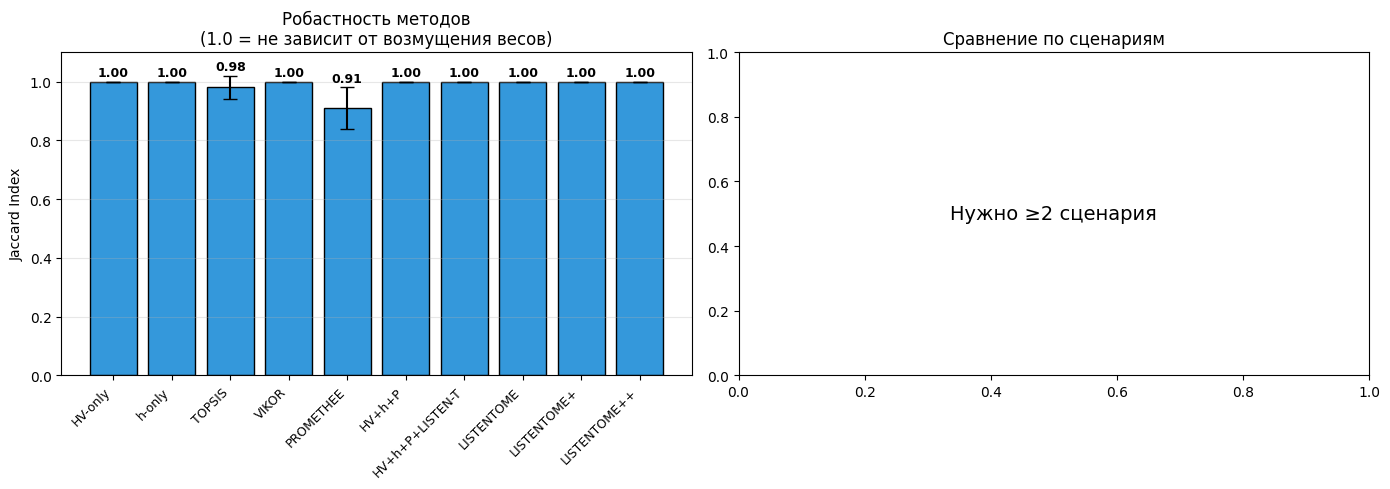


✅ robustness обновлён в all_results


In [ ]:
# ============================================================
# 10. ЭКСПЕРИМЕНТ 3: АНАЛИЗ РОБАСТНОСТИ
# ============================================================
print("\n" + "=" * 70)
print("10. ЭКСПЕРИМЕНТ 3: АНАЛИЗ РОБАСТНОСТИ")
print("=" * 70)

# ----------------------------------------------------------
# 10.1. Возмущение весов (10 прогонов)
# ----------------------------------------------------------
print("\n10.1. Возмущение весов (10 прогонов)")

np.random.seed(42)
n_perturbations = 10
# Используем финальный список методов
method_names = ALL_METHODS
sensitive_methods = ['TOPSIS', 'VIKOR', 'PROMETHEE', 'HV+h+P']

# Храним Jaccard: jaccard_results[method][scenario] = [jaccard1, jaccard2, ...]
jaccard_results = {method: {s: [] for s in active_scenario_ids} for method in method_names}

# Базовые ранжирования (без возмущений)
base_rankings = {}
for method in method_names:
    base_rankings[method] = {}
    for s in active_scenario_ids:
        base_rankings[method][s] = rankings[method][s][:10]  # топ-10

# Для каждого сценария делаем 10 прогонов с возмущёнными весами
for scenario_id in active_scenario_ids:
    s = SCENARIOS[scenario_id]
    base_w1 = s['w1']
    base_w2 = s['w2']
    norm = s['norm']

    for run in range(n_perturbations):
        # Возмущаем веса: добавляем шум ±0.15, остаёмся в [0, 1]
        noise1 = np.random.uniform(-0.15, 0.15)
        noise2 = -noise1  # сохраняем сумму ≈ 1
        w1_new = np.clip(base_w1 + noise1, 0.1, 0.9)
        w2_new = np.clip(base_w2 + noise2, 0.1, 0.9)

        # Перенормируем
        total = w1_new + w2_new
        w1_new, w2_new = w1_new / total, w2_new / total
        w3 = 0.2
        total3 = w1_new + w2_new + w3
        w1_new, w2_new, w3_new = w1_new/total3, w2_new/total3, w3/total3

        # Пересчитываем ранжирования для методов, зависящих от весов
        # TOPSIS
        top3_topsis = topsis_ranking(norm['hv_norm'], norm['h_norm'], norm['p_norm'], w1_new, w2_new)[:10]
        jaccard_results['TOPSIS'][scenario_id].append(
            len(set(top3_topsis) & set(base_rankings['TOPSIS'][scenario_id])) / 10
        )

        # VIKOR
        top3_vikor = vikor_ranking(norm['hv_norm'], norm['h_norm'], norm['p_norm'], w1_new, w2_new)[:10]
        jaccard_results['VIKOR'][scenario_id].append(
            len(set(top3_vikor) & set(base_rankings['VIKOR'][scenario_id])) / 10
        )

        # PROMETHEE
        top3_prom = promethee_ranking(norm['hv_norm'], norm['h_norm'], norm['p_norm'], w1_new, w2_new)[:10]
        jaccard_results['PROMETHEE'][scenario_id].append(
            len(set(top3_prom) & set(base_rankings['PROMETHEE'][scenario_id])) / 10
        )

        # HV+h+P (Гибридный)
        alpha = 0.6
        beta = 0.15
        score_hybrid = alpha * norm['hv_norm'] + (1-alpha) * norm['h_norm'] - beta * norm['p_norm']
        top3_hybrid = np.argsort(score_hybrid)[::-1][:10]
        jaccard_results['HV+h+P'][scenario_id].append(
            len(set(top3_hybrid) & set(base_rankings['HV+h+P'][scenario_id])) / 10
        )

    # Методы, не зависящие от весов → Jaccard = 1.0
    for method in method_names:
        if method not in sensitive_methods:
            jaccard_results[method][scenario_id] = [1.0] * n_perturbations

# ----------------------------------------------------------
# 10.2. Jaccard Index для каждого метода
# ----------------------------------------------------------
print("\n" + "=" * 70)
print("10.2. JACCARD INDEX (среднее ± std)")
print("=" * 70)

# Динамический заголовок
header = f"{'Метод':<25}"
for s in active_scenario_ids:
    header += f" {'Сцен. ' + str(s):<15}"
header += f" {'Среднее':<15}"
print(header)
print(f"{'-'* (25 + 15*len(active_scenario_ids) + 15)}")

for method in method_names:
    print(f"{method:<25}", end='')
    all_jaccards = []
    for s in active_scenario_ids:
        jac_vals = jaccard_results[method][s]
        mean_jac = np.mean(jac_vals)
        std_jac = np.std(jac_vals)
        all_jaccards.extend(jac_vals)
        if std_jac < 0.01:
            print(f"{mean_jac:.2f}{'':>10}", end='')
        else:
            print(f"{mean_jac:.2f}±{std_jac:.2f}{'':>5}", end='')

    mean_all = np.mean(all_jaccards)
    std_all = np.std(all_jaccards)
    print(f"{mean_all:.2f}±{std_all:.2f}")

# ----------------------------------------------------------
# Визуализация
# ----------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# График 1: Jaccard по методам (среднее по всем сценариям)
ax = axes[0]
means = []
stds = []
for method in method_names:
    all_jac = []
    for s in active_scenario_ids:
        all_jac.extend(jaccard_results[method][s])
    means.append(np.mean(all_jac))
    stds.append(np.std(all_jac))

colors = ['#3498db' if m > 0.8 else '#e67e22' if m > 0.5 else '#e74c3c' for m in means]
bars = ax.bar(range(len(method_names)), means, yerr=stds, color=colors, edgecolor='black', capsize=5)
ax.set_xticks(range(len(method_names)))
ax.set_xticklabels(method_names, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Jaccard Index')
ax.set_title('Робастность методов\n(1.0 = не зависит от возмущения весов)')
ax.set_ylim(0, 1.1)
ax.grid(True, alpha=0.3, axis='y')
for i, (m, s) in enumerate(zip(means, stds)):
    ax.text(i, m + s + 0.02, f'{m:.2f}', ha='center', fontsize=9, fontweight='bold')

# График 2: Jaccard по сценариям для чувствительных методов
if len(active_scenario_ids) > 1:
    ax = axes[1]
    x = np.arange(len(active_scenario_ids))
    width = 0.2
    for i, method in enumerate(sensitive_methods):
        means_s = [np.mean(jaccard_results[method][s]) for s in active_scenario_ids]
        ax.bar(x + i*width, means_s, width, label=method, alpha=0.8)
    ax.set_xticks(x + width*1.5)
    ax.set_xticklabels([f'Сценарий {s}' for s in active_scenario_ids])
    ax.set_ylabel('Jaccard Index')
    ax.set_title('Чувствительность к возмущению весов\nпо сценариям')
    ax.legend(fontsize=8)
    ax.set_ylim(0, 1.1)
    ax.grid(True, alpha=0.3, axis='y')
else:
    axes[1].text(0.5, 0.5, 'Нужно ≥2 сценария', ha='center', va='center', fontsize=14, transform=axes[1].transAxes)
    axes[1].set_title('Сравнение по сценариям')

plt.tight_layout()
plt.savefig('robustness_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# Обновляем robustness в результатах (если all_results существует)
try:
    for method in method_names:
        for s in active_scenario_ids:
            all_results[method][s]['robustness'] = np.mean(jaccard_results[method][s])
    print("\n✅ robustness обновлён в all_results")
except NameError:
    print("\n⚠️ all_results не найден (блок 8 не запущен). robustness сохранён только в jaccard_results")

# 11. ВИЗУАЛИЗАЦИЯ

   11.1. Heatmap метрик (методы и метрики)

   11.2. Радарная диаграмма (профили методов)

   11.3. Столбцовая диаграмма Historical F1@3
   
   11.4. График Парето-фронта с выделенными топ-3 для лучшего метода


11. ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ
11.1. Heatmap метрик


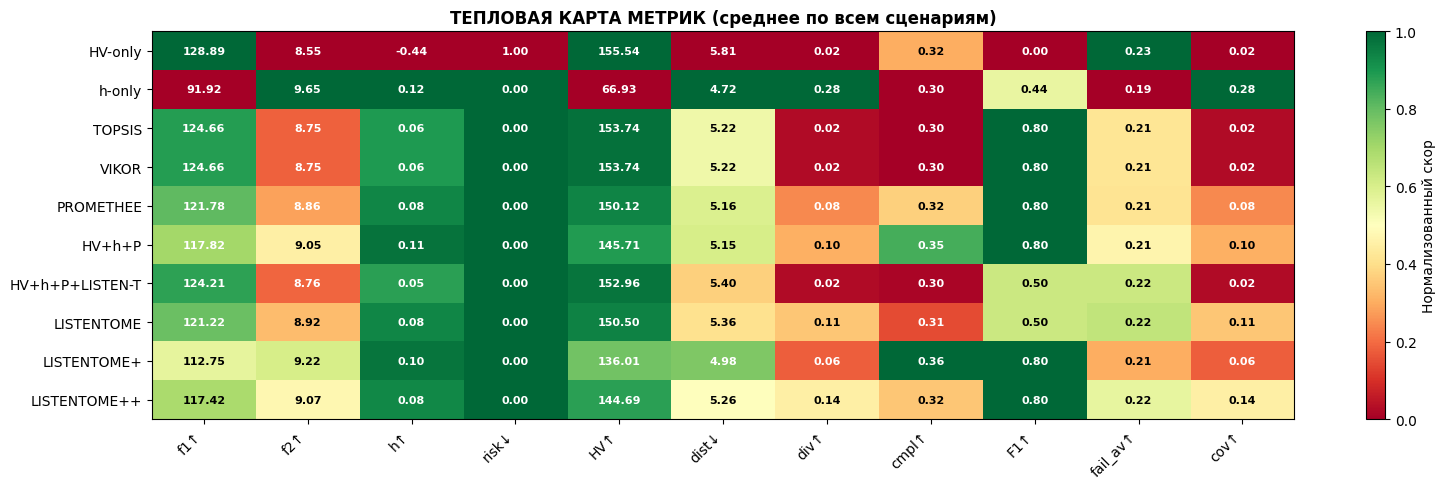

11.2. Радарная диаграмма


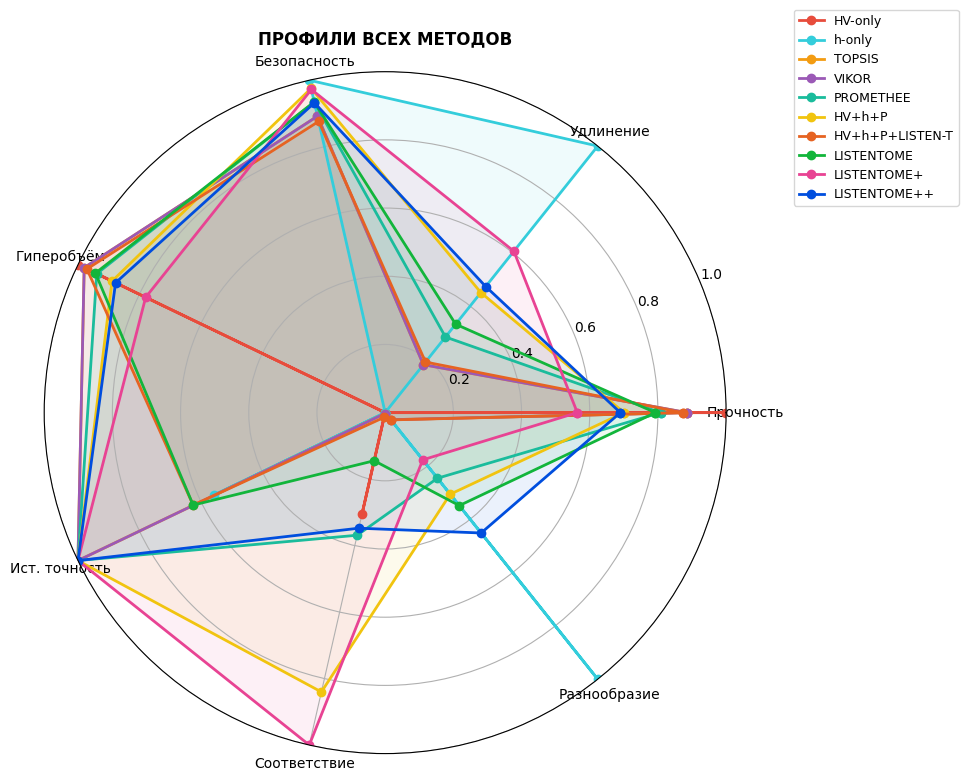

11.3. Historical F1@3


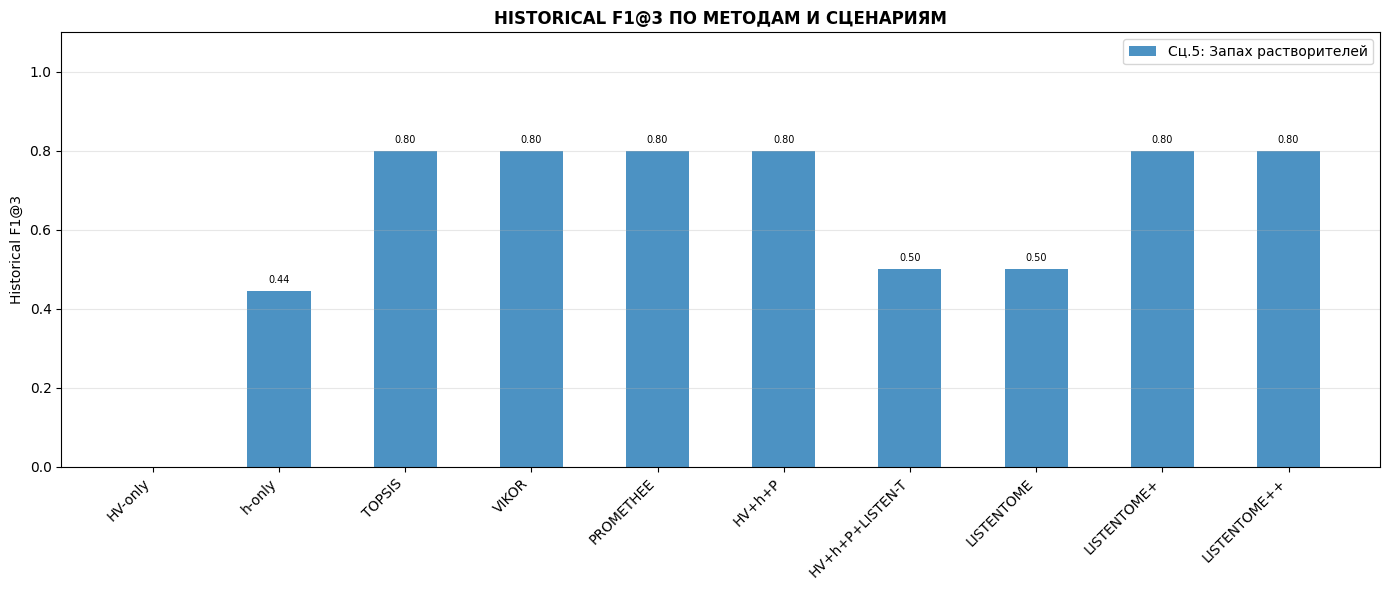

11.4. Парето-фронт с топ-3


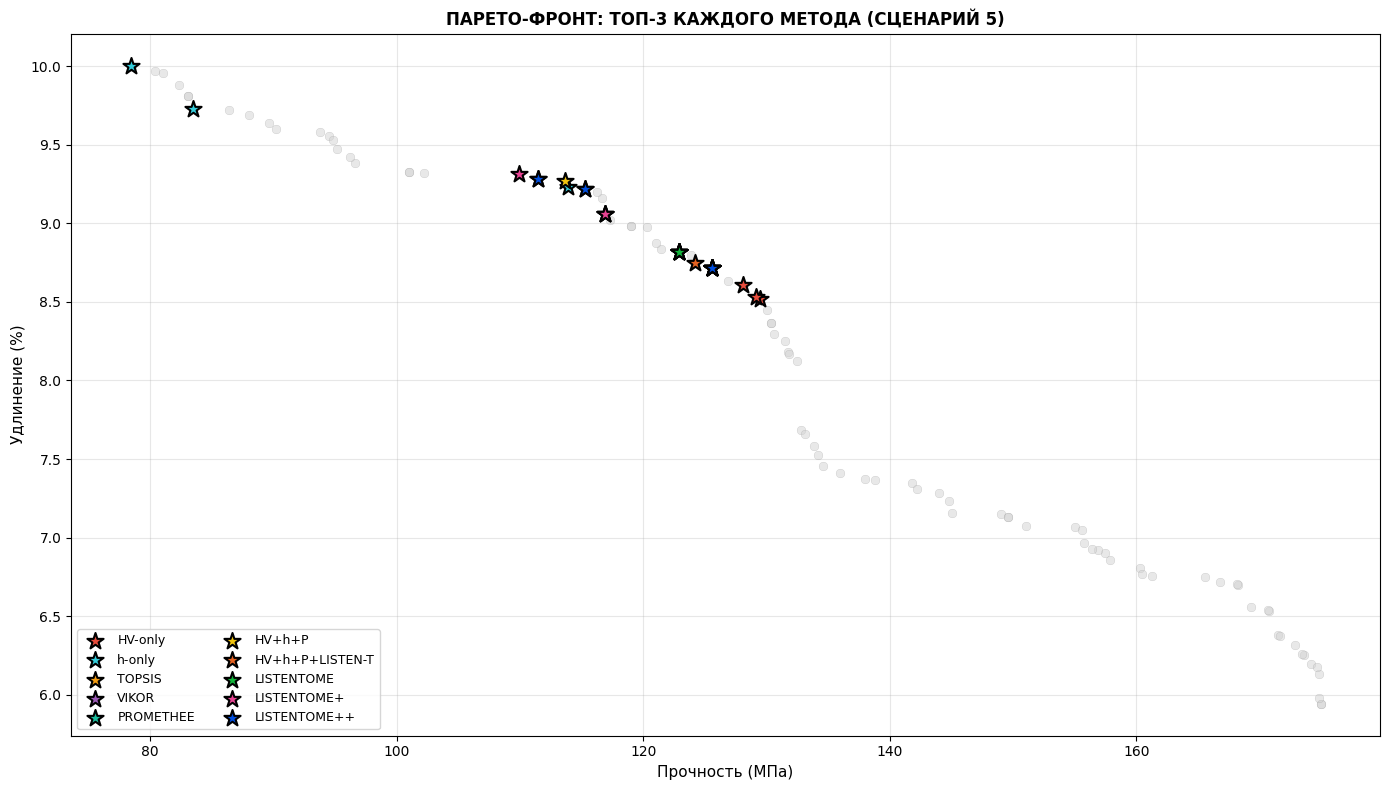

In [ ]:
# ============================================================
# 11. ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ
# ============================================================
print("\n" + "=" * 70)
print("11. ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ")
print("=" * 70)

demo_sid = active_scenario_ids[0]
method_names = ALL_METHODS
scenario_labels = [f'Сц.{s}: {SCENARIO_NAMES[s-1]}' for s in active_scenario_ids]

# Проверка наличия all_results
if 'all_results' not in dir():
    raise RuntimeError("Блок 8 не запущен! Сначала выполните блок 8.")

# ----------------------------------------------------------
# 11.1. Heatmap метрик
# ----------------------------------------------------------
print("11.1. Heatmap метрик")

all_metric_keys = ['avg_f1', 'avg_f2', 'avg_h', 'risk_frac', 'avg_HV',
                   'dist_good', 'diversity', 'compliance', 'historical_f1@3', 'failure_avoidance', 'coverage']
all_short = ['f1↑', 'f2↑', 'h↑', 'risk↓', 'HV↑', 'dist↓', 'div↑', 'cmpl↑', 'F1↑', 'fail_av↑', 'cov↑']
inverse_metrics = ['risk_frac', 'dist_good']

heatmap_data = np.zeros((len(method_names), len(all_metric_keys)))
for i, method in enumerate(method_names):
    for j, key in enumerate(all_metric_keys):
        vals = [all_results[method][s][key] for s in active_scenario_ids if all_results[method][s][key] is not None]
        heatmap_data[i, j] = np.mean(vals) if vals else 0

heatmap_norm = np.zeros_like(heatmap_data)
for j, key in enumerate(all_metric_keys):
    col = heatmap_data[:, j]
    col_min, col_max = col.min(), col.max()
    if col_max > col_min:
        if key in inverse_metrics:
            heatmap_norm[:, j] = (col_max - col) / (col_max - col_min)
        else:
            heatmap_norm[:, j] = (col - col_min) / (col_max - col_min)
    else:
        heatmap_norm[:, j] = 0.5

fig, ax = plt.subplots(figsize=(16, 5))
im = ax.imshow(heatmap_norm, cmap='RdYlGn', aspect='auto', vmin=0, vmax=1)
ax.set_xticks(range(len(all_short)))
ax.set_xticklabels(all_short, fontsize=10, rotation=45, ha='right')
ax.set_yticks(range(len(method_names)))
ax.set_yticklabels(method_names, fontsize=10)
for i in range(len(method_names)):
    for j in range(len(all_metric_keys)):
        val = heatmap_data[i, j]
        text_color = 'white' if heatmap_norm[i, j] < 0.3 or heatmap_norm[i, j] > 0.7 else 'black'
        ax.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=8, color=text_color, fontweight='bold')
ax.set_title('ТЕПЛОВАЯ КАРТА МЕТРИК (среднее по всем сценариям)', fontsize=12, fontweight='bold')
plt.colorbar(im, ax=ax, label='Нормализованный скор')
plt.tight_layout()
plt.savefig('heatmap_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

# ----------------------------------------------------------
# 11.2. Радарная диаграмма
# ----------------------------------------------------------
print("11.2. Радарная диаграмма")

radar_metrics = ['avg_f1', 'avg_f2', 'avg_h', 'avg_HV', 'historical_f1@3', 'compliance', 'diversity']
radar_labels = ['Прочность', 'Удлинение', 'Безопасность', 'Гиперобъём', 'Ист. точность', 'Соответствие', 'Разнообразие']

radar_data = np.zeros((len(method_names), len(radar_metrics)))
for j, key in enumerate(radar_metrics):
    vals = [np.mean([all_results[m][s][key] for s in active_scenario_ids if all_results[m][s][key] is not None]) for m in method_names]
    vmin, vmax = min(vals), max(vals)
    radar_data[:, j] = (np.array(vals) - vmin) / (vmax - vmin) if vmax > vmin else 0.5

angles = np.linspace(0, 2 * np.pi, len(radar_metrics), endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))
for i, method in enumerate(method_names):
    values = radar_data[i].tolist() + [radar_data[i][0]]
    ax.fill(angles, values, alpha=0.08, color=all_colors[i])
    ax.plot(angles, values, 'o-', linewidth=2, label=method, color=all_colors[i], markersize=6)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_labels, fontsize=10)
ax.set_ylim(0, 1)
ax.set_title('ПРОФИЛИ ВСЕХ МЕТОДОВ', fontsize=12, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1), fontsize=9)
ax.grid(True)
plt.tight_layout()
plt.savefig('radar_methods.png', dpi=150, bbox_inches='tight')
plt.show()

# ----------------------------------------------------------
# 11.3. Historical F1@3
# ----------------------------------------------------------
print("11.3. Historical F1@3")

fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(method_names))
width = 0.8 / len(active_scenario_ids) if len(active_scenario_ids) > 1 else 0.5

for i, s in enumerate(active_scenario_ids):
    f1_vals = [all_results[m][s]['historical_f1@3'] for m in method_names]
    offset = (i - (len(active_scenario_ids)-1)/2) * width if len(active_scenario_ids) > 1 else 0
    bars = ax.bar(x + offset, f1_vals, width, label=scenario_labels[i], alpha=0.8)
    for j, v in enumerate(f1_vals):
        if v > 0:
            ax.text(j + offset, v + 0.02, f'{v:.2f}', ha='center', fontsize=7)

ax.set_xticks(x)
ax.set_xticklabels(method_names, rotation=45, ha='right', fontsize=10)
ax.set_ylabel('Historical F1@3')
ax.set_title('HISTORICAL F1@3 ПО МЕТОДАМ И СЦЕНАРИЯМ', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim(0, 1.1)
plt.tight_layout()
plt.savefig('f1_barchart.png', dpi=150, bbox_inches='tight')
plt.show()

# ----------------------------------------------------------
# 11.4. Парето-фронт с топ-3
# ----------------------------------------------------------
print("11.4. Парето-фронт с топ-3")

fig, ax = plt.subplots(figsize=(14, 8))
ax.scatter(pareto_df['strength'], pareto_df['elongation'],
           c='lightgray', s=40, alpha=0.5, edgecolors='gray', linewidth=0.2, zorder=1)

for m_idx, method in enumerate(method_names):
    if method in rankings and demo_sid in rankings[method]:
        top3 = rankings[method][demo_sid][:3]
        ax.scatter(pareto_df.iloc[top3]['strength'], pareto_df.iloc[top3]['elongation'],
                   c=all_colors[m_idx], s=150, marker='*', edgecolors='black', linewidth=1.5,
                   label=method, zorder=10)

ax.set_xlabel('Прочность (МПа)', fontsize=11)
ax.set_ylabel('Удлинение (%)', fontsize=11)
ax.set_title(f'ПАРЕТО-ФРОНТ: ТОП-3 КАЖДОГО МЕТОДА (СЦЕНАРИЙ {demo_sid})', fontsize=12, fontweight='bold')
ax.legend(fontsize=9, loc='lower left', ncol=2)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('pareto_top3_all.png', dpi=150, bbox_inches='tight')
plt.show()

11.5. Парето-фронт: сетка 2×6


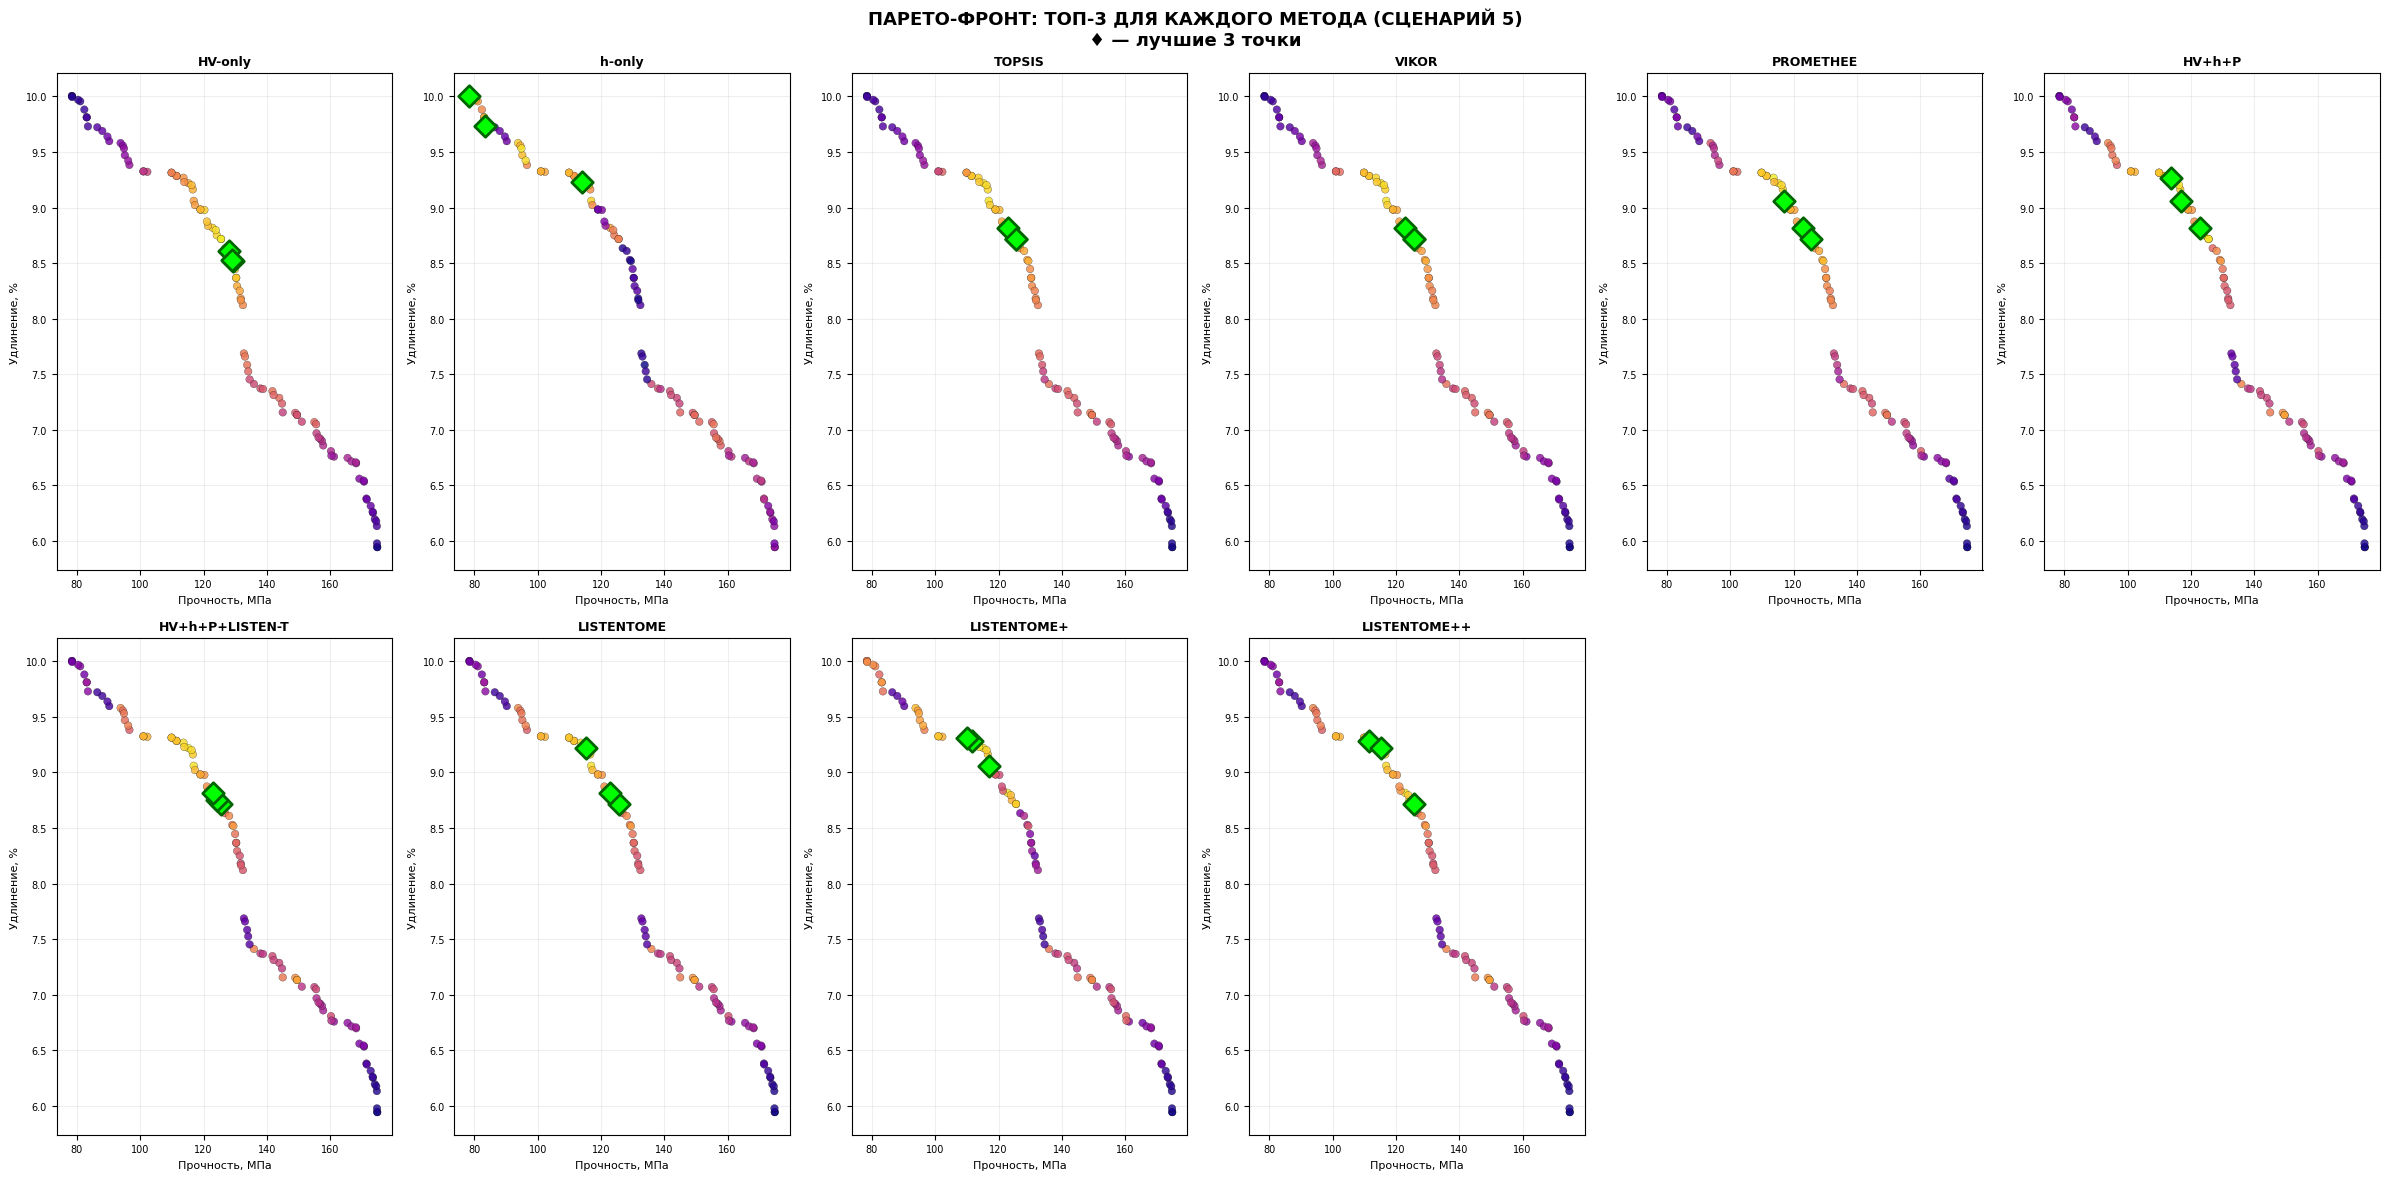

11.6. Zoom: консенсус методов


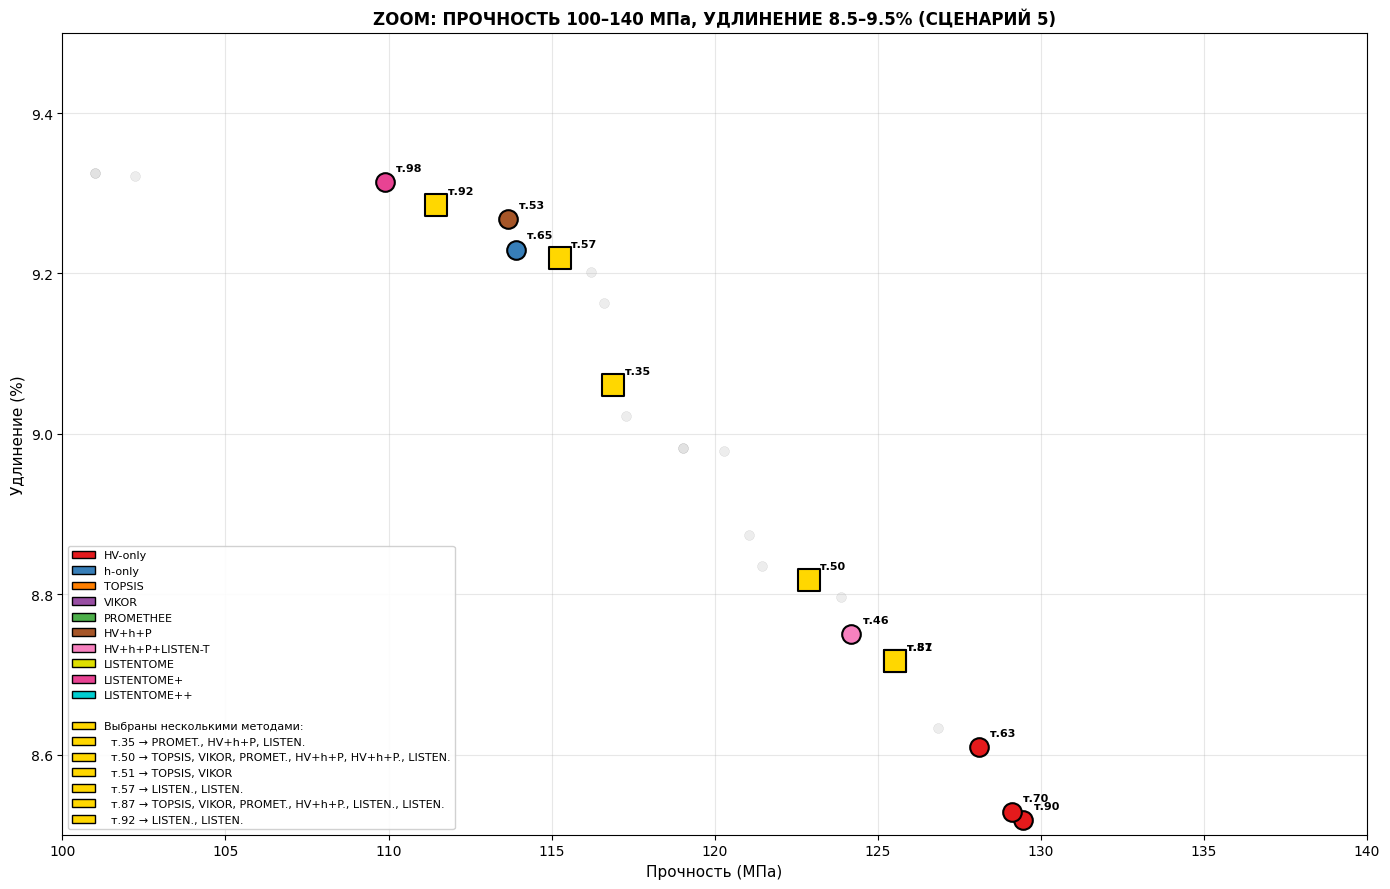

In [ ]:
# ----------------------------------------------------------
# 11.5. Парето-фронт: компактная сетка 2×6
# ----------------------------------------------------------
print("11.5. Парето-фронт: сетка 2×6")

n_methods = len(method_names)

fig, axes = plt.subplots(2, 6, figsize=(24, 12))
axes = axes.flatten()

for col, method in enumerate(method_names):
    ax = axes[col]
    ax.scatter(pareto_df['strength'], pareto_df['elongation'],
               c='lightgray', s=20, alpha=0.4, edgecolors='gray', linewidth=0.2, zorder=1)

    if method in rankings and demo_sid in rankings[method]:
        top3 = rankings[method][demo_sid][:3]
        ranks = np.zeros(len(pareto_df))
        ranks[rankings[method][demo_sid]] = np.arange(len(pareto_df), 0, -1)

        ax.scatter(pareto_df['strength'], pareto_df['elongation'],
                   c=ranks, cmap='plasma', s=30, alpha=0.8,
                   edgecolors='black', linewidth=0.2, zorder=2)
        ax.scatter(pareto_df.iloc[top3]['strength'], pareto_df.iloc[top3]['elongation'],
                   c='lime', s=120, marker='D', edgecolors='darkgreen',
                   linewidth=2, zorder=10)
        ax.set_title(f'{method}', fontsize=9, fontweight='bold')

    ax.set_xlabel('Прочность, МПа', fontsize=8)
    ax.set_ylabel('Удлинение, %', fontsize=8)
    ax.tick_params(labelsize=7)
    ax.grid(True, alpha=0.2)

for col in range(n_methods, len(axes)):
    axes[col].axis('off')

plt.suptitle(f'ПАРЕТО-ФРОНТ: ТОП-3 ДЛЯ КАЖДОГО МЕТОДА (СЦЕНАРИЙ {demo_sid})\n♦ — лучшие 3 точки',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('pareto_top3_compact.png', dpi=150, bbox_inches='tight')
plt.show()

# ----------------------------------------------------------
# 11.6. Zoom: консенсус методов
# ----------------------------------------------------------
print("11.6. Zoom: консенсус методов")

fig, ax = plt.subplots(figsize=(14, 9))
ax.set_xlim(100, 140)
ax.set_ylim(8.5, 9.5)
ax.scatter(pareto_df['strength'], pareto_df['elongation'],
           c='lightgray', s=50, alpha=0.4, edgecolors='gray', linewidth=0.2, zorder=1)

point_methods = {}
for m_idx, method in enumerate(method_names):
    if method in rankings and demo_sid in rankings[method]:
        top3 = rankings[method][demo_sid][:3]
        for idx in top3:
            idx = int(idx)
            if idx not in point_methods:
                point_methods[idx] = []
            point_methods[idx].append(method)

for idx, methods in point_methods.items():
    row = pareto_df.iloc[idx]
    if 100 <= row['strength'] <= 140 and 8.5 <= row['elongation'] <= 9.5:
        n = len(methods)
        if n == 1:
            color = all_colors_v2[method_names.index(methods[0])]
            size, marker = 180, 'o'
        else:
            color, size, marker = 'gold', 250, 's'

        ax.scatter(row['strength'], row['elongation'],
                   c=color, s=size, marker=marker, edgecolors='black', linewidth=1.5, zorder=10)
        ax.annotate(f'т.{idx}', (row['strength'], row['elongation']),
                   textcoords="offset points", xytext=(8, 8), fontsize=8,
                   color='black', fontweight='bold')

from matplotlib.patches import Patch
legend_elements = []
for i, method in enumerate(method_names):
    legend_elements.append(Patch(facecolor=all_colors_v2[i], edgecolor='black', label=method))
legend_elements.append(Patch(facecolor='white', edgecolor='white', label=''))

multi_point_indices = sorted([idx for idx, methods in point_methods.items() if len(methods) > 1
                              and 100 <= pareto_df.iloc[idx]['strength'] <= 140
                              and 8.5 <= pareto_df.iloc[idx]['elongation'] <= 9.5])
if multi_point_indices:
    legend_elements.append(Patch(facecolor='gold', edgecolor='black', label='Выбраны несколькими методами:'))
    for idx in multi_point_indices:
        methods_short = [m[:6]+'.' if len(m)>7 else m for m in point_methods[idx]]
        legend_elements.append(Patch(facecolor='gold', edgecolor='black',
                                      label=f'  т.{idx} → {", ".join(methods_short)}'))

ax.legend(handles=legend_elements, fontsize=8, loc='lower left', ncol=1, framealpha=0.9)
ax.set_xlabel('Прочность (МПа)', fontsize=11)
ax.set_ylabel('Удлинение (%)', fontsize=11)
ax.set_title(f'ZOOM: ПРОЧНОСТЬ 100–140 МПа, УДЛИНЕНИЕ 8.5–9.5% (СЦЕНАРИЙ {demo_sid})', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('pareto_zoom_consensus.png', dpi=150, bbox_inches='tight')
plt.show()


12. ВИЗУАЛИЗАЦИЯ ДЛЯ ПРЕЗЕНТАЦИИ
🏆 Лучший метод: HV+h+P (0.763)
🥈 Топ-3: ['HV+h+P', 'LISTENTOME+', 'LISTENTOME++']

1. Рейтинг методов


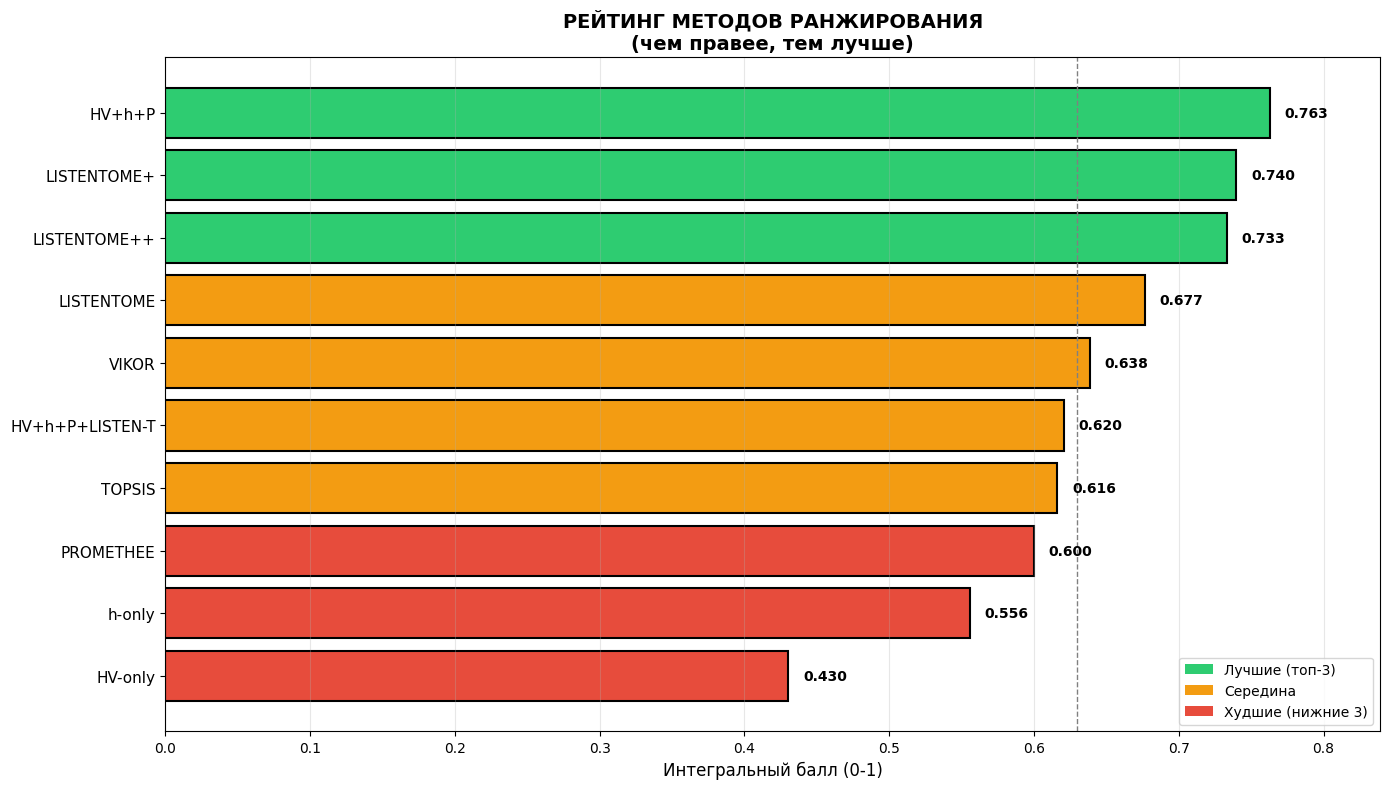

2. Сравнение топ-3 методов


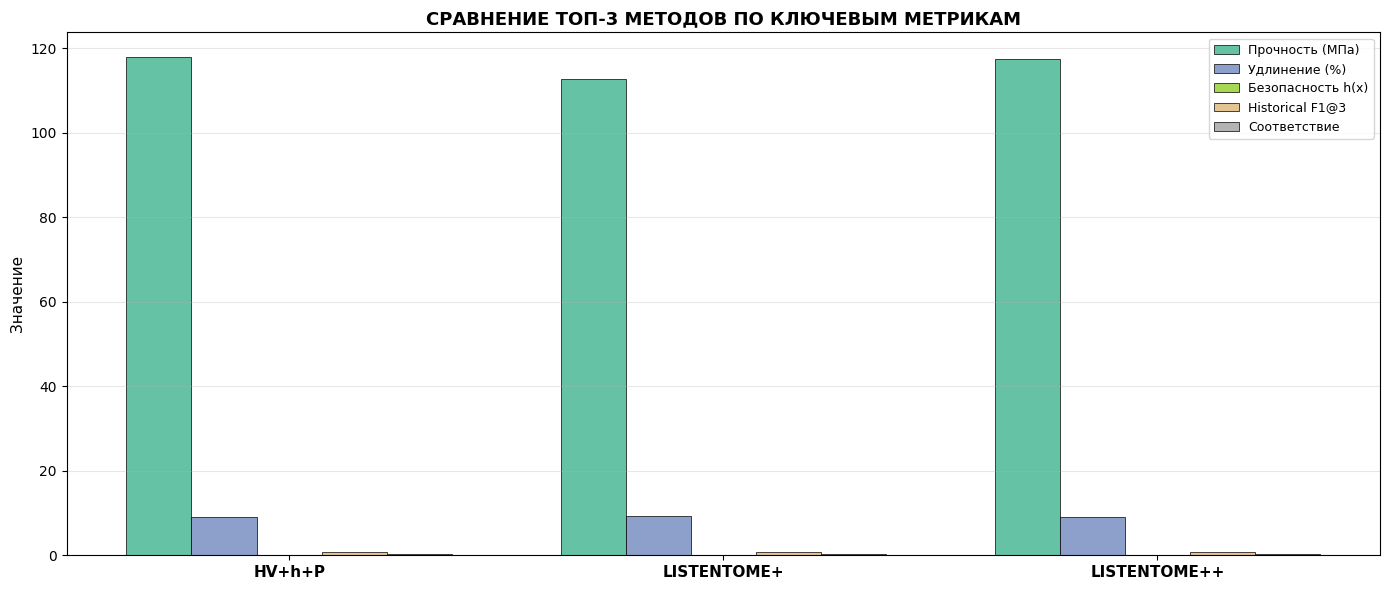

3. Радарная диаграмма


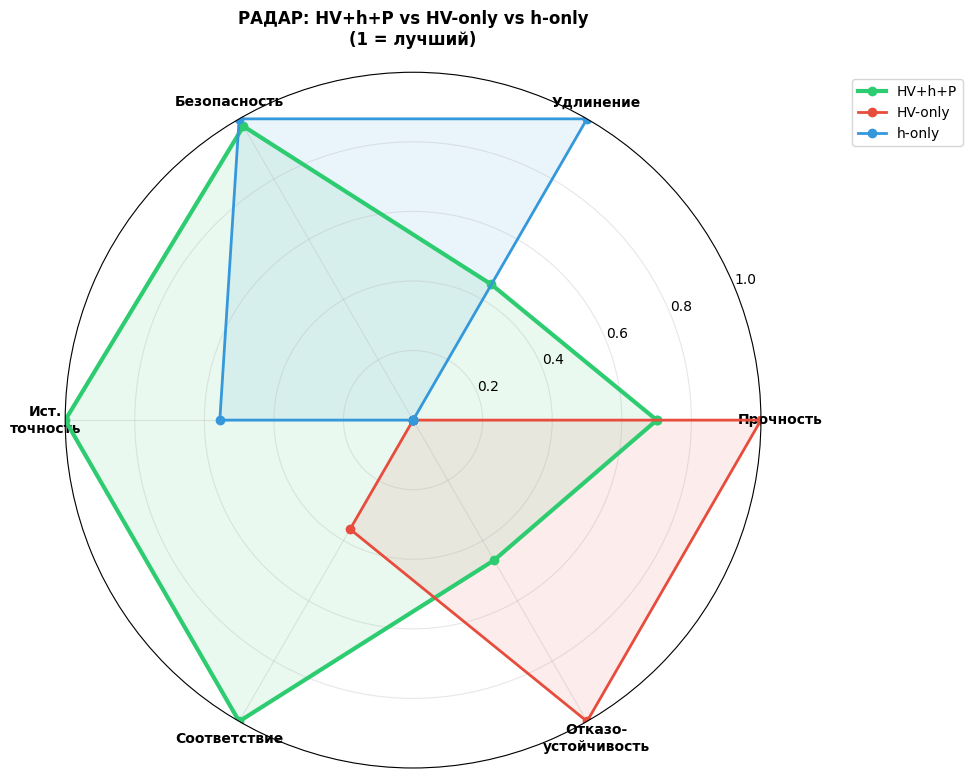

4. Тепловая карта


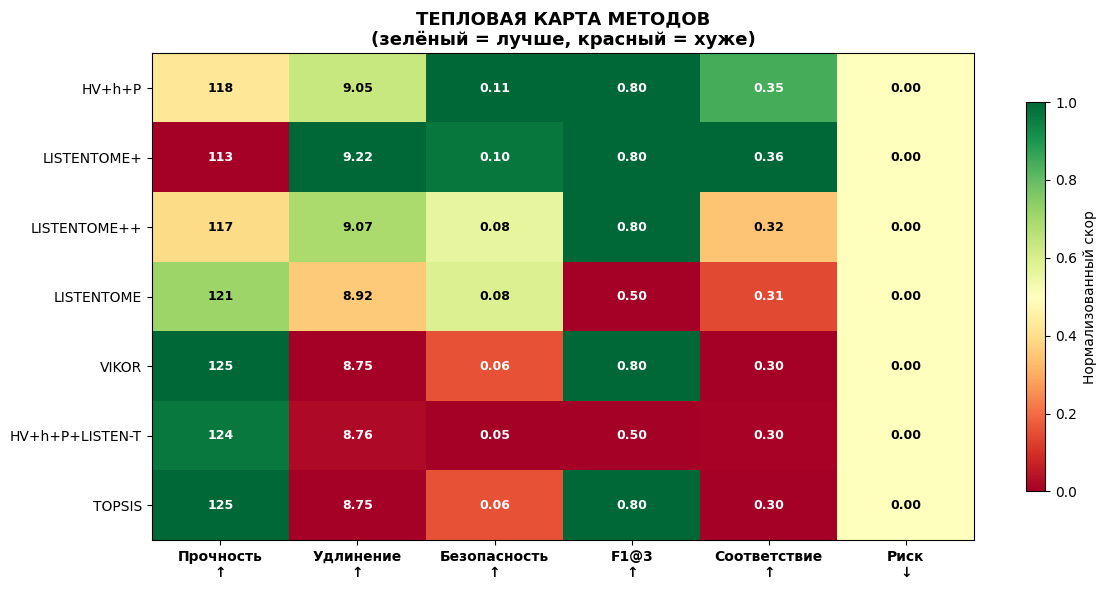

5. Historical F1@3


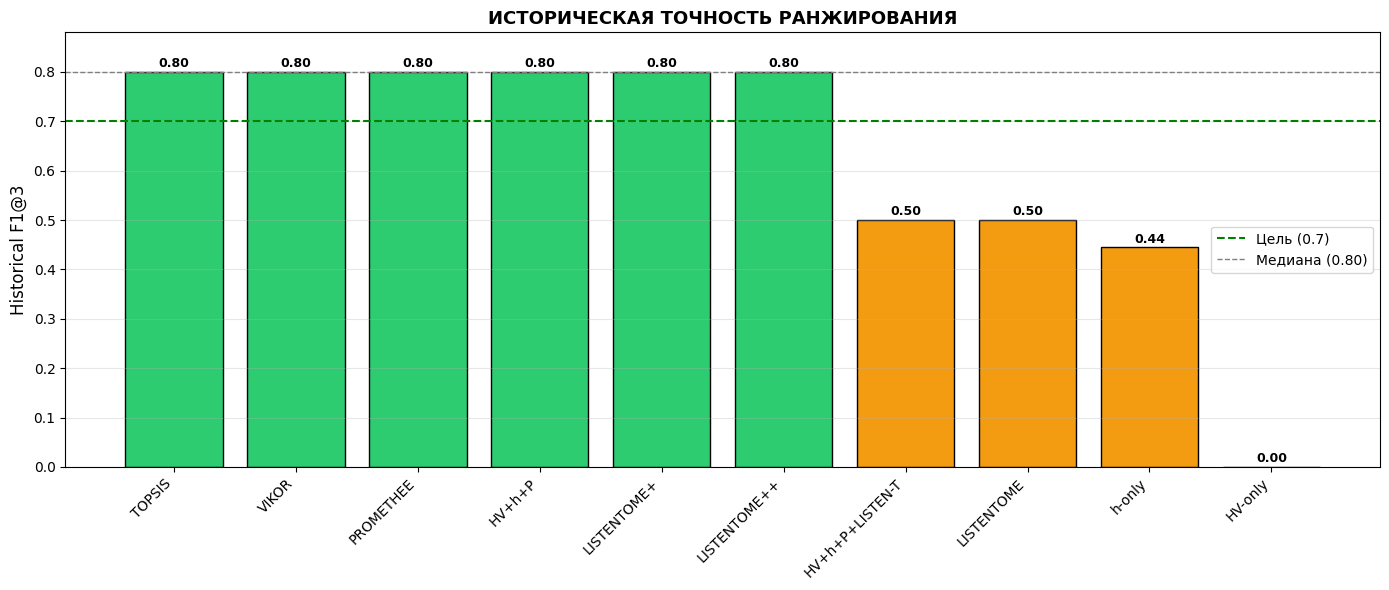

6. Инфографика победителя


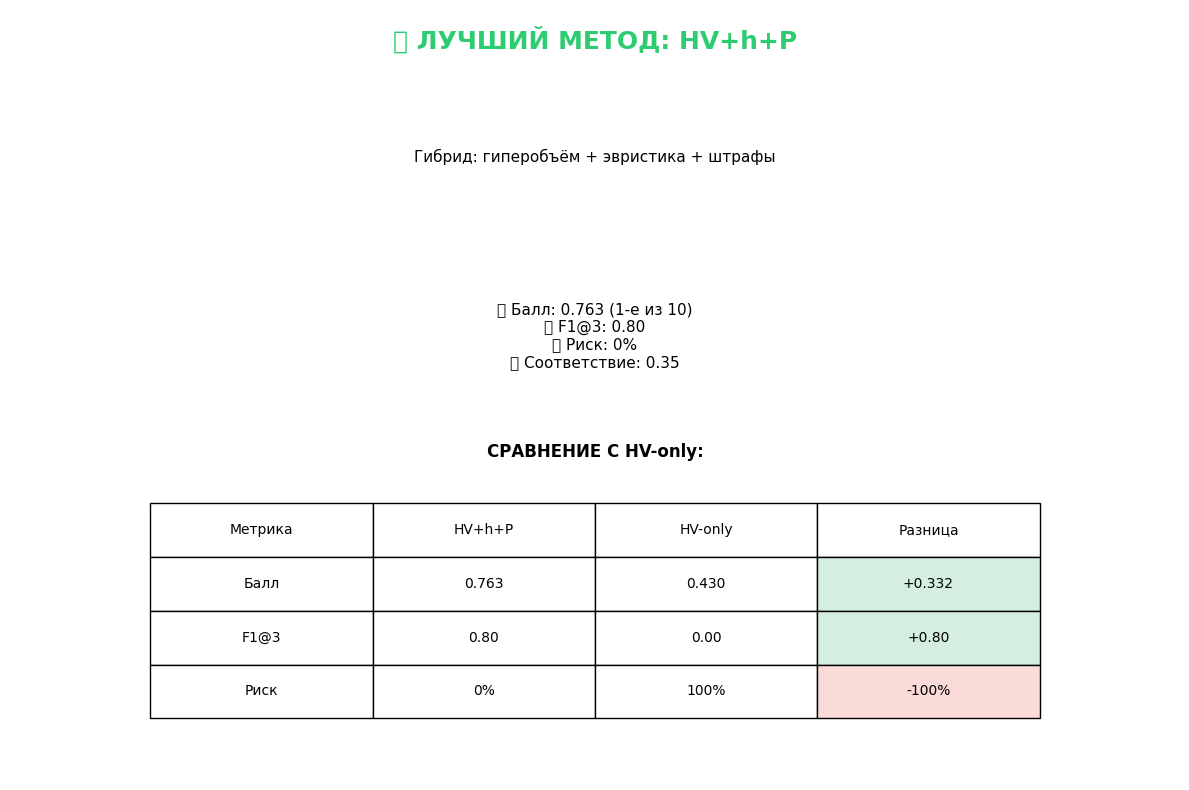

In [ ]:
# ============================================================
# 12. ВИЗУАЛИЗАЦИЯ ДЛЯ ПРЕЗЕНТАЦИИ
# ============================================================
print("\n" + "=" * 70)
print("12. ВИЗУАЛИЗАЦИЯ ДЛЯ ПРЕЗЕНТАЦИИ")
print("=" * 70)

# ----------------------------------------------------------
# Вычисляем интегральный балл (единый для всех графиков)
# ----------------------------------------------------------
summary_metrics = ['avg_f1', 'avg_f2', 'avg_h', 'risk_frac', 'avg_HV',
                   'historical_f1@3', 'failure_avoidance', 'robustness', 'compliance', 'diversity']

final_scores_dict = {}
for method in method_names:
    normalized_scores = []
    for metric in summary_metrics:
        vals = [all_results[method][s][metric] for s in active_scenario_ids if all_results[method][s][metric] is not None]
        if vals:
            all_metric_vals = []
            for m in method_names:
                m_vals = [all_results[m][s][metric] for s in active_scenario_ids if all_results[m][s][metric] is not None]
                if m_vals:
                    all_metric_vals.append(np.mean(m_vals))
            if len(all_metric_vals) > 1:
                min_val, max_val = min(all_metric_vals), max(all_metric_vals)
                if max_val > min_val:
                    method_val = np.mean(vals)
                    if metric in ['risk_frac', 'dist_good']:
                        norm = (max_val - method_val) / (max_val - min_val)
                    else:
                        norm = (method_val - min_val) / (max_val - min_val)
                    normalized_scores.append(norm)
                else:
                    normalized_scores.append(0.5)
            else:
                normalized_scores.append(0.5)
        else:
            normalized_scores.append(0.5)
    final_scores_dict[method] = np.mean(normalized_scores)

# Сортируем
sorted_methods = sorted(final_scores_dict.items(), key=lambda x: x[1], reverse=True)
methods_ranked = [m[0] for m in sorted_methods]   # лучший → худший
scores_ranked = [m[1] for m in sorted_methods]

best_method = methods_ranked[0]
best_score = scores_ranked[0]
worst_method = methods_ranked[-1]
worst_score = scores_ranked[-1]
top3_methods = methods_ranked[:3]

print(f"🏆 Лучший метод: {best_method} ({best_score:.3f})")
print(f"🥈 Топ-3: {top3_methods}")

# ----------------------------------------------------------
# 1. Рейтинг методов (barh, лучший сверху)
# ----------------------------------------------------------
print("\n1. Рейтинг методов")

methods_display = methods_ranked[::-1]  # инвертируем для barh
scores_display = scores_ranked[::-1]

n = len(methods_display)
colors_display = []
for method in methods_display:
    rank = methods_ranked.index(method)
    if rank < 3:
        colors_display.append('#2ecc71')
    elif rank >= n - 3:
        colors_display.append('#e74c3c')
    else:
        colors_display.append('#f39c12')

fig, ax = plt.subplots(figsize=(14, max(8, n * 0.6)))
ax.barh(range(n), scores_display, color=colors_display, edgecolor='black', linewidth=1.5)
ax.set_yticks(range(n))
ax.set_yticklabels(methods_display, fontsize=11)
ax.set_xlabel('Интегральный балл (0-1)', fontsize=12)
ax.set_title('РЕЙТИНГ МЕТОДОВ РАНЖИРОВАНИЯ\n(чем правее, тем лучше)', fontsize=14, fontweight='bold')
ax.set_xlim(0, max(scores_display) * 1.1)
ax.axvline(x=np.median(scores_display), color='gray', linestyle='--', linewidth=1, label='Медиана')
ax.grid(True, alpha=0.3, axis='x')
for i, score in enumerate(scores_display):
    ax.text(score + 0.01, i, f'{score:.3f}', va='center', fontsize=10, fontweight='bold')

from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(facecolor='#2ecc71', label='Лучшие (топ-3)'),
    Patch(facecolor='#f39c12', label='Середина'),
    Patch(facecolor='#e74c3c', label='Худшие (нижние 3)')
], loc='lower right', fontsize=10)
plt.tight_layout()
plt.savefig('presentation_method_ranking.png', dpi=150, bbox_inches='tight')
plt.show()

# ----------------------------------------------------------
# 2. Сравнение топ-3 методов по ключевым метрикам
# ----------------------------------------------------------
print("2. Сравнение топ-3 методов")

key_metrics = ['avg_f1', 'avg_f2', 'avg_h', 'historical_f1@3', 'compliance']
metric_labels = ['Прочность (МПа)', 'Удлинение (%)', 'Безопасность h(x)', 'Historical F1@3', 'Соответствие']

top3_data = {}
for method in top3_methods:
    top3_data[method] = {}
    for metric in key_metrics:
        vals = [all_results[method][s][metric] for s in active_scenario_ids if all_results[method][s][metric] is not None]
        top3_data[method][metric] = np.mean(vals) if vals else 0

fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(top3_methods))
width = 0.15
colors_m = plt.cm.Set2(np.linspace(0, 1, len(key_metrics)))

for i, (metric, label) in enumerate(zip(key_metrics, metric_labels)):
    offset = (i - len(key_metrics)/2) * width + width/2
    values = [top3_data[m][metric] for m in top3_methods]
    ax.bar(x + offset, values, width, label=label, color=colors_m[i], edgecolor='black', linewidth=0.5)

ax.set_xticks(x)
ax.set_xticklabels(top3_methods, fontsize=11, fontweight='bold')
ax.set_ylabel('Значение', fontsize=11)
ax.set_title('СРАВНЕНИЕ ТОП-3 МЕТОДОВ ПО КЛЮЧЕВЫМ МЕТРИКАМ', fontsize=13, fontweight='bold')
ax.legend(loc='upper right', fontsize=9)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('presentation_top3_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# ----------------------------------------------------------
# 3. Радар: лучший vs HV-only vs h-only
# ----------------------------------------------------------
print("3. Радарная диаграмма")

radar_methods = [best_method]
if 'HV-only' in method_names:
    radar_methods.append('HV-only')
if 'h-only' in method_names:
    radar_methods.append('h-only')

radar_metrics = ['avg_f1', 'avg_f2', 'avg_h', 'historical_f1@3', 'compliance', 'failure_avoidance']
radar_labels = ['Прочность', 'Удлинение', 'Безопасность', 'Ист.\nточность', 'Соответствие', 'Отказо-\nустойчивость']

radar_values = {}
for method in radar_methods:
    radar_values[method] = []
    for metric in radar_metrics:
        vals = [all_results[method][s][metric] for s in active_scenario_ids if all_results[method][s][metric] is not None]
        radar_values[method].append(np.mean(vals) if vals else 0)

radar_norm = {m: [] for m in radar_methods}
for j, metric in enumerate(radar_metrics):
    all_vals = [radar_values[m][j] for m in radar_methods]
    min_val, max_val = min(all_vals), max(all_vals)
    if max_val > min_val:
        for m in radar_methods:
            radar_norm[m].append((radar_values[m][j] - min_val) / (max_val - min_val))
    else:
        for m in radar_methods:
            radar_norm[m].append(0.5)

angles = np.linspace(0, 2 * np.pi, len(radar_labels), endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))
colors_r = ['#2ecc71', '#e74c3c', '#3498db']
widths = [3, 2, 2]

for i, method in enumerate(radar_methods):
    values = radar_norm[method] + radar_norm[method][:1]
    ax.plot(angles, values, 'o-', linewidth=widths[i], color=colors_r[i], label=method, markersize=6)
    ax.fill(angles, values, alpha=0.1, color=colors_r[i])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_labels, fontsize=10, fontweight='bold')
ax.set_ylim(0, 1)
ax.set_title(f'РАДАР: {best_method} vs HV-only vs h-only\n(1 = лучший)', fontsize=12, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0), fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('presentation_radar_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# ----------------------------------------------------------
# 4. Тепловая карта
# ----------------------------------------------------------
print("4. Тепловая карта")

n_heat = min(7, len(method_names))
heat_methods = methods_ranked[:n_heat]
heat_metrics = ['avg_f1', 'avg_f2', 'avg_h', 'historical_f1@3', 'compliance', 'risk_frac']
heat_labels = ['Прочность\n↑', 'Удлинение\n↑', 'Безопасность\n↑', 'F1@3\n↑', 'Соответствие\n↑', 'Риск\n↓']

heat_data = np.zeros((len(heat_methods), len(heat_metrics)))
for i, method in enumerate(heat_methods):
    for j, metric in enumerate(heat_metrics):
        vals = [all_results[method][s][metric] for s in active_scenario_ids if all_results[method][s][metric] is not None]
        heat_data[i, j] = np.mean(vals) if vals else 0

heat_norm = np.zeros_like(heat_data)
for j, metric in enumerate(heat_metrics):
    col = heat_data[:, j]
    col_min, col_max = col.min(), col.max()
    if col_max > col_min:
        if metric in ['risk_frac']:
            heat_norm[:, j] = (col_max - col) / (col_max - col_min)
        else:
            heat_norm[:, j] = (col - col_min) / (col_max - col_min)
    else:
        heat_norm[:, j] = 0.5

fig, ax = plt.subplots(figsize=(12, max(6, len(heat_methods) * 0.6)))
im = ax.imshow(heat_norm, cmap='RdYlGn', aspect='auto', vmin=0, vmax=1)
ax.set_xticks(range(len(heat_labels)))
ax.set_xticklabels(heat_labels, fontsize=10, fontweight='bold')
ax.set_yticks(range(len(heat_methods)))
ax.set_yticklabels(heat_methods, fontsize=10)

for i in range(len(heat_methods)):
    for j in range(len(heat_metrics)):
        val = heat_data[i, j]
        text_color = 'white' if heat_norm[i, j] < 0.2 or heat_norm[i, j] > 0.8 else 'black'
        fmt = '.0f' if heat_metrics[j] == 'avg_f1' else '.2f'
        ax.text(j, i, f'{val:{fmt}}', ha='center', va='center', fontsize=9, color=text_color, fontweight='bold')

ax.set_title('ТЕПЛОВАЯ КАРТА МЕТОДОВ\n(зелёный = лучше, красный = хуже)', fontsize=13, fontweight='bold')
plt.colorbar(im, ax=ax, label='Нормализованный скор', shrink=0.8)
plt.tight_layout()
plt.savefig('presentation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# ----------------------------------------------------------
# 5. Historical F1@3
# ----------------------------------------------------------
print("5. Historical F1@3")

f1_data = {}
for method in method_names:
    vals = [all_results[method][s]['historical_f1@3'] for s in active_scenario_ids if all_results[method][s]['historical_f1@3'] is not None]
    f1_data[method] = np.mean(vals) if vals else 0

sorted_f1 = sorted(f1_data.items(), key=lambda x: x[1], reverse=True)
f1_methods = [m[0] for m in sorted_f1]
f1_values = [m[1] for m in sorted_f1]

fig, ax = plt.subplots(figsize=(14, 6))
colors_f1 = ['#2ecc71' if v >= 0.7 else '#f39c12' if v >= 0.4 else '#e74c3c' for v in f1_values]
ax.bar(f1_methods, f1_values, color=colors_f1, edgecolor='black', linewidth=1)
ax.set_xticklabels(f1_methods, rotation=45, ha='right', fontsize=10)
ax.set_ylabel('Historical F1@3', fontsize=12)
ax.set_ylim(0, max(f1_values) * 1.1)
ax.set_title('ИСТОРИЧЕСКАЯ ТОЧНОСТЬ РАНЖИРОВАНИЯ', fontsize=13, fontweight='bold')
ax.axhline(y=0.7, color='green', linestyle='--', linewidth=1.5, label='Цель (0.7)')
ax.axhline(y=np.median(f1_values), color='gray', linestyle='--', linewidth=1, label=f'Медиана ({np.median(f1_values):.2f})')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis='y')
for i, val in enumerate(f1_values):
    ax.text(i, val + 0.01, f'{val:.2f}', ha='center', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.savefig('presentation_historical_f1.png', dpi=150, bbox_inches='tight')
plt.show()

# ----------------------------------------------------------
# 6. Инфографика победителя
# ----------------------------------------------------------
print("6. Инфографика победителя")

best_metrics = {}
for metric in ['historical_f1@3', 'risk_frac', 'compliance', 'avg_f1', 'avg_h']:
    vals = [all_results[best_method][s][metric] for s in active_scenario_ids if all_results[best_method][s][metric] is not None]
    best_metrics[metric] = np.mean(vals) if vals else 0

worst_metrics = {}
for metric in ['historical_f1@3', 'risk_frac', 'compliance', 'avg_f1', 'avg_h']:
    vals = [all_results[worst_method][s][metric] for s in active_scenario_ids if all_results[worst_method][s][metric] is not None]
    worst_metrics[metric] = np.mean(vals) if vals else 0

fig, ax = plt.subplots(figsize=(12, 8))
ax.axis('off')

ax.text(0.5, 0.95, f'🏆 ЛУЧШИЙ МЕТОД: {best_method}',
        transform=ax.transAxes, fontsize=18, fontweight='bold', ha='center', color='#2ecc71')

descriptions = {
    'LISTENTOME+': 'LLM подбирает веса под запрос\n→ понимает контекст предпочтений',
    'LISTENTOME': 'LLM-турнир с h(x), P(x) и HV\n→ сравнивает как эксперт',
    'HV+h+P': 'Гибрид: гиперобъём + эвристика + штрафы',
    'LISTENTOME++': 'Теннисная сетка на 16\n→ детальный турнирный отбор',
}
ax.text(0.5, 0.82, descriptions.get(best_method, 'LLM-метод с адаптацией'),
        transform=ax.transAxes, fontsize=11, ha='center', va='top')

advantages = [
    f"✅ Балл: {best_score:.3f} (1-е из {len(method_names)})",
    f"✅ F1@3: {best_metrics['historical_f1@3']:.2f}",
    f"✅ Риск: {best_metrics['risk_frac']:.0%}",
    f"✅ Соответствие: {best_metrics['compliance']:.2f}",
]
ax.text(0.5, 0.62, '\n'.join(advantages), transform=ax.transAxes, fontsize=11, ha='center', va='top')

ax.text(0.5, 0.42, f'СРАВНЕНИЕ С {worst_method}:', transform=ax.transAxes, fontsize=12, fontweight='bold', ha='center')

comparison = [
    ['Метрика', best_method, worst_method, 'Разница'],
    ['Балл', f'{best_score:.3f}', f'{worst_score:.3f}', f'+{best_score-worst_score:.3f}'],
    ['F1@3', f'{best_metrics["historical_f1@3"]:.2f}', f'{worst_metrics["historical_f1@3"]:.2f}', f'+{best_metrics["historical_f1@3"]-worst_metrics["historical_f1@3"]:.2f}'],
    ['Риск', f'{best_metrics["risk_frac"]:.0%}', f'{worst_metrics["risk_frac"]:.0%}', f'-{worst_metrics["risk_frac"]-best_metrics["risk_frac"]:.0%}'],
]

table = ax.table(cellText=comparison, loc='center', cellLoc='center', bbox=[0.12, 0.08, 0.76, 0.28])
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.5)
for i in range(1, 4):
    if '+' in comparison[i][3]:
        table[(i, 3)].set_facecolor('#d4efdf')
    elif '-' in comparison[i][3]:
        table[(i, 3)].set_facecolor('#fadbd8')

plt.tight_layout()
plt.savefig('presentation_winner_infographic.png', dpi=150, bbox_inches='tight')
plt.show()

# 12. ВЫВОДЫ

   12.1. Лучший метод по объективным метрикам

   12.2. Статистическая значимость (если применимо)
   
   12.3. Ограничения эксперимента

In [ ]:
# ============================================================
# 12. ВЫВОДЫ
# ============================================================
print("\n" + "=" * 70)
print("12. ВЫВОДЫ")
print("=" * 70)

# ----------------------------------------------------------
# 12.1. Лучший метод по объективным метрикам
# ----------------------------------------------------------
print("\n" + "=" * 70)
print("12.1. ЛУЧШИЙ МЕТОД ПО ОБЪЕКТИВНЫМ МЕТРИКАМ")
print("=" * 70)

summary_metrics = ['avg_f1', 'avg_f2', 'avg_h', 'risk_frac', 'avg_HV',
                   'historical_f1@3', 'failure_avoidance', 'robustness', 'compliance', 'diversity']
short_names = ['f1↑', 'f2↑', 'h↑', 'risk↓', 'HV↑', 'F1↑', 'fail_av↑', 'robust↑', 'cmpl↑', 'div↑']

# Заголовок
header = f"{'Метод':<25}"
for name in short_names:
    header += f"{name:>8}"
print(header)
print(f"{'-'* (25 + 8*len(short_names))}")

# Лучшие по метрикам
best_per_metric = {}
for key in summary_metrics:
    best_val = -999 if key != 'risk_frac' else 999
    best_method = ''
    for method in method_names:
        vals = [all_results[method][s][key] for s in active_scenario_ids if all_results[method][s][key] is not None]
        if vals:
            mean_val = np.mean(vals)
            if key == 'risk_frac':
                if mean_val < best_val:
                    best_val = mean_val
                    best_method = method
            else:
                if mean_val > best_val:
                    best_val = mean_val
                    best_method = method
    best_per_metric[key] = (best_method, best_val)

# Вывод таблицы
for method in method_names:
    print(f"{method:<25}", end='')
    for key in summary_metrics:
        vals = [all_results[method][s][key] for s in active_scenario_ids if all_results[method][s][key] is not None]
        mean_val = np.mean(vals) if vals else 0
        is_best = (method == best_per_metric[key][0])
        marker = '*' if is_best else ' '
        print(f"{marker}{mean_val:7.2f}", end='')
    print()

print(f"\n* = лучший результат по метрике")

# Подсчёт побед
win_counts = {m: 0 for m in method_names}
for key, (best_method, _) in best_per_metric.items():
    win_counts[best_method] += 1

print(f"\n🏆 ПОБЕД ПО МЕТРИКАМ:")
for method, count in sorted(win_counts.items(), key=lambda x: x[1], reverse=True):
    bar = '█' * count + '░' * (10 - count)
    print(f"  {method:<25} {bar} ({count}/10)")

# Интегральный балл
normalized_scores = np.zeros((len(method_names), len(summary_metrics)))
for j, key in enumerate(summary_metrics):
    col_vals = [np.mean([all_results[m][s][key] for s in active_scenario_ids if all_results[m][s][key] is not None]) for m in method_names]
    col_min, col_max = min(col_vals), max(col_vals)
    if col_max > col_min:
        if key in ['risk_frac', 'dist_good']:
            normalized_scores[:, j] = (col_max - np.array(col_vals)) / (col_max - col_min)
        else:
            normalized_scores[:, j] = (np.array(col_vals) - col_min) / (col_max - col_min)
    else:
        normalized_scores[:, j] = 0.5

final_scores_arr = normalized_scores.mean(axis=1)
best_idx = np.argmax(final_scores_arr)

print(f"\n📊 ИТОГОВЫЙ ИНТЕГРАЛЬНЫЙ БАЛЛ:")
for i, method in enumerate(method_names):
    bar_len = int(final_scores_arr[i] * 40)
    bar = '█' * bar_len + '░' * (40 - bar_len)
    print(f"  {method:<25} {bar} {final_scores_arr[i]:.3f}")

print(f"\n{'='*80}")
print(f"✅ ЛУЧШИЙ МЕТОД: {method_names[best_idx]} (балл: {final_scores_arr[best_idx]:.3f})")
print(f"{'='*80}")

# ----------------------------------------------------------
# 12.2. Статистическая значимость
# ----------------------------------------------------------
print("\n" + "=" * 70)
print("12.2. СТАТИСТИЧЕСКАЯ ЗНАЧИМОСТЬ")
print("=" * 70)

from scipy.stats import friedmanchisquare, wilcoxon

# Friedman test по F1@3
f1_data = []
for method in method_names:
    f1_vals = [all_results[method][s]['historical_f1@3'] for s in active_scenario_ids]
    f1_data.append(f1_vals)

if len(active_scenario_ids) >= 3:
    stat, p_value = friedmanchisquare(*f1_data)
    print(f"\nТест Фридмана (сравнение {len(method_names)} методов по Historical F1@3):")
    print(f"  Статистика: {stat:.4f}")
    print(f"  p-value:    {p_value:.4f}")
    print(f"  {'✅ Различия СТАТИСТИЧЕСКИ ЗНАЧИМЫ (p < 0.05)' if p_value < 0.05 else '⚠️ Различия НЕ значимы (p ≥ 0.05)'}")
else:
    print(f"\n⚠️ Тест Фридмана требует ≥3 сценариев (сейчас: {len(active_scenario_ids)})")

# Попарный тест: лучший vs худший
best_vals = [all_results[method_names[best_idx]][s]['historical_f1@3'] for s in active_scenario_ids]
worst_vals = [all_results[method_names[np.argmin(final_scores_arr)]][s]['historical_f1@3'] for s in active_scenario_ids]

if len(set(best_vals)) > 1 or len(set(worst_vals)) > 1:
    w_stat, w_p = wilcoxon(best_vals, worst_vals)
    print(f"\nПопарный тест Уилкоксона: {method_names[best_idx]} vs {method_names[np.argmin(final_scores_arr)]}:")
    print(f"  Статистика: {w_stat:.4f}, p-value: {w_p:.4f}")
else:
    print(f"\n⚠️ Попарный тест невозможен — все значения одинаковы (нужно больше сценариев)")

# ----------------------------------------------------------
# 12.3. Ограничения эксперимента
# ----------------------------------------------------------
print("\n" + "=" * 70)
print("12.3. ОГРАНИЧЕНИЯ ЭКСПЕРИМЕНТА")
print("=" * 70)

print(f"""
1. ОГРАНИЧЕННОСТЬ ДАННЫХ:
   • Всего {len(hist_df)} исторических рецептов, из них только {hist_df['Брак'].sum()} бракованных
   • D_good/D_bad сформированы на основе quality_score и близости к браку
   • Парето-фронт из {len(pareto_df)} точек — ограниченное покрытие пространства решений

2. ОГРАНИЧЕНИЯ ЭВРИСТИКИ h(x):
   • h(x) основана на манхэттенском расстоянии до k-NN соседей (k=5)
   • Выбор разметки "Брак + зона риска" — эмпирический, не теоретический
   • Корреляция h(x) с целевыми функциями выявлена post-hoc

3. ОГРАНИЧЕНИЯ LLM-КОМПОНЕНТЫ:
   • Использовалась модель {OLLAMA_MODEL} — результаты зависят от её возможностей
   • Извлечение предпочтений через промпт может давать нестабильные результаты
   • LISTEN-турниры чувствительны к формулировке описаний рецептур

4. ОГРАНИЧЕНИЯ ЭКСПЕРИМЕНТАЛЬНОГО ДИЗАЙНА:
   • {len(active_scenario_ids)} сценариев из 7 использовано в сравнении
   • Метрики основаны на исторических данных (не на реальных испытаниях)
   • Возмущение весов только ±0.15 — не исследованы крайние случаи

5. ОБЩИЕ ОГРАНИЧЕНИЯ:
   • Качество ранжирования оценивается косвенно (через метрики)
   • Computational cost: LISTEN-методы требуют множественных вызовов LLM API
""")

print(f"""
{'='*80}
                    ИССЛЕДОВАНИЕ ЗАВЕРШЕНО
{'='*80}

  Лучший метод: {method_names[best_idx]}
  Интегральный балл: {final_scores_arr[best_idx]:.3f}
  Побед по метрикам: {win_counts[method_names[best_idx]]}/10

""")


12. ВЫВОДЫ

12.1. ЛУЧШИЙ МЕТОД ПО ОБЪЕКТИВНЫМ МЕТРИКАМ
Метод                         f1↑     f2↑      h↑   risk↓     HV↑     F1↑fail_av↑ robust↑   cmpl↑    div↑
---------------------------------------------------------------------------------------------------------
HV-only                  * 128.89    8.55   -0.44    1.00* 155.54    0.00*   0.23*   1.00    0.32    0.02
h-only                      91.92*   9.65*   0.12*   0.00   66.93    0.44    0.19    1.00    0.30*   0.28
TOPSIS                     124.66    8.75    0.06    0.00  153.74*   0.80    0.21    0.98    0.30    0.02
VIKOR                      124.66    8.75    0.06    0.00  153.74    0.80    0.21    1.00    0.30    0.02
PROMETHEE                  121.78    8.86    0.08    0.00  150.12    0.80    0.21    0.91    0.32    0.08
HV+h+P                     117.82    9.05    0.11    0.00  145.71    0.80    0.21    1.00    0.35    0.10
HV+h+P+LISTEN-T            124.21    8.76    0.05    0.00  152.96    0.50    0.22    1.00    0.3